# Retail Customer Intelligence

### End-to-End Customer Analytics and Repeat-Purchase Prediction

## 1. Project Overview

This project develops an end-to-end customer-intelligence workflow using the
Online Retail II transactional dataset.

The analysis transforms raw transaction records into sales insights, customer
segments, retention measurements and repeat-purchase predictions.

The main objectives of the project are to:

- Define a reliable merchandise-sales scope using transaction-level business
  rules
- Analyse monthly, country-level and product-level sales performance
- Create customer-level behavioural features after conservative cancellation
  adjustment
- Segment customers using RFM analysis and K-Means clustering
- Measure customer activity over time through cohort retention analysis
- Predict whether an existing customer will purchase again within the following
  three months
- Evaluate the prediction model using temporal validation and an untouched
  holdout period
- Explain the final LightGBM model using SHAP
- Translate analytical findings into actionable business recommendations

### Analytical Workflow

1. Data loading and initial inspection
2. Data-quality analysis and transaction classification
3. Merchandise-sales definition and performance analysis
4. Customer-level dataset construction
5. RFM segmentation
6. Customer clustering
7. Cohort retention analysis
8. Temporal repeat-purchase classification
9. SHAP model interpretation
10. Business insights and recommendations

### Key Results

- Champions and Loyal Customers represented approximately 31.7% of identified
  customers while generating about 79.2% of customer merchandise value.
- Three commercially distinct customer profiles were identified through
  clustering: Active High-Value Customers, Lapsing Occasional Customers and
  Inactive One-Time Customers.
- Monthly active-customer retention generally remained around 18%–21% at the
  selected post-acquisition horizons.
- The final LightGBM model achieved a temporal holdout ROC-AUC of 0.77,
  balanced accuracy of 0.70 and F1-score of 0.67.
- SHAP analysis identified twelve-month invoice frequency, customer recency,
  purchase-history span and total spending as the strongest predictive signals.

## 2. Environment Setup and Data Loading

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [2]:
DATA_PATH = Path("../data/raw/online_retail_II.xlsx")

DATA_PATH

WindowsPath('../data/raw/online_retail_II.xlsx')

In [3]:
if DATA_PATH.exists():
    print(f"Dataset found: {DATA_PATH}")
else:
    print(f"Dataset not found: {DATA_PATH}")

Dataset found: ..\data\raw\online_retail_II.xlsx


In [4]:
excel_file = pd.ExcelFile(DATA_PATH)

print("sheet names:",excel_file.sheet_names)

sheet names: ['Year 2009-2010', 'Year 2010-2011']


### Worksheet Preview

Only the first five rows of each worksheet are loaded initially.
This allows the column names and table structures to be compared before
loading and combining the complete datasets.

In [5]:
sheet_previews = {}

for sheet_name in excel_file.sheet_names:
    preview = pd.read_excel(DATA_PATH,sheet_name=sheet_name,nrows=5)

    sheet_previews[sheet_name] = preview

    print(f"\nWorksheet: {sheet_name}")
    print(f"Preview shape: {preview.shape}")

    display(preview)


Worksheet: Year 2009-2010
Preview shape: (5, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom



Worksheet: Year 2010-2011
Preview shape: (5, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


### Loading the Complete Dataset

Both worksheets are loaded separately so that their shapes and date ranges
can be inspected before they are combined into a single transaction table.

In [6]:
retail_2009_2010 = pd.read_excel(DATA_PATH,sheet_name="Year 2009-2010")

retail_2010_2011 = pd.read_excel(DATA_PATH,sheet_name="Year 2010-2011")

In [7]:
print("Year 2009-2010 shape:" ,retail_2009_2010.shape)
print("Year 2010-2011 shape:" ,retail_2010_2011.shape)

Year 2009-2010 shape: (525461, 8)
Year 2010-2011 shape: (541910, 8)


In [8]:
expected_total_rows = (retail_2009_2010.shape[0]+ retail_2010_2011.shape[0])

print(f"Expected total rows after combining: {expected_total_rows:,}")

Expected total rows after combining: 1,067,371


### Combining Transaction Periods

The two transaction periods are vertically combined into a single DataFrame.
A new continuous index is created because the original worksheet indices
restart from zero.

In [9]:
retail_df = pd.concat([retail_2009_2010, retail_2010_2011],axis=0,ignore_index=True)

retail_df.shape

(1067371, 8)

In [10]:
display(retail_df.head())    #ilk satırlar 2009–2010 döneminden, son satırlar ise 2010–2011 döneminden
display(retail_df.tail())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,"12,680.00",France


In [11]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [12]:
for i in retail_df.columns:
    print(f"{i}:",retail_df[i].nunique())

Invoice: 53628
StockCode: 5305
Description: 5698
Quantity: 1057
InvoiceDate: 47635
Price: 2807
Customer ID: 5942
Country: 43


In [13]:
for i in retail_df.columns:
    print(f"{i}:",retail_df[i].isnull().sum())

Invoice: 0
StockCode: 0
Description: 4382
Quantity: 0
InvoiceDate: 0
Price: 0
Customer ID: 243007
Country: 0


## 3. Data Quality and Transaction Classification

This section evaluates the structural quality of the combined transaction
dataset before defining the final analytical sales scope.

The analysis covers:

- missing customer and product information,
- exact duplicate records,
- cancelled invoices,
- negative quantities,
- non-positive prices,
- manual and accounting transactions,
- transaction-type classification.

No potentially unusual record is removed solely because of its size. Records
are first classified according to transparent business rules and then included
or excluded depending on the analytical objective.

### Initial Data Quality Summary

The dataset is summarized by data type, missing-value count, missing-value
percentage and number of unique values. This provides an initial overview of
the variables that require further investigation before analysis.

In [14]:
data_quality_summary = pd.DataFrame({
    "data_type": retail_df.dtypes.astype(str),
    "non_null_count": retail_df.notna().sum(),
    "missing_count": retail_df.isna().sum(),
    "missing_percentage": retail_df.isna().mean().mul(100).round(2),
    "unique_count": retail_df.nunique()
})

data_quality_summary

,data_type,non_null_count,missing_count,missing_percentage,unique_count
Invoice,object,1067371,0,0.00,53628
StockCode,object,1067371,0,0.00,5305
Description,object,1062989,4382,0.41,5698
Quantity,int64,1067371,0,0.00,1057
InvoiceDate,datetime64[ns],1067371,0,0.00,47635
Price,float64,1067371,0,0.00,2807
Customer ID,float64,824364,243007,22.77,5942
Country,object,1067371,0,0.00,43


### Transaction Quality Checks

Before removing or modifying any records, potentially invalid or special
transactions are identified. Negative quantities, cancelled invoices and
non-positive prices may represent returns, cancellations, adjustments or
data-quality issues.

In [15]:
date_range = retail_df["InvoiceDate"].agg(["min", "max"])

date_range

min   2009-12-01 07:45:00
max   2011-12-09 12:50:00
Name: InvoiceDate, dtype: datetime64[ns]

The dataset covers transactions from December 2009 to December 2011.
However, December 2011 is incomplete because the final transaction was
recorded on December 9. Therefore, monthly comparisons involving the final
month should be interpreted cautiously.

In [16]:
duplicate_row_count = retail_df.duplicated().sum()

print(f"Duplicate rows: {duplicate_row_count:,}")

Duplicate rows: 34,335


In [17]:
duplicate_rows = (retail_df.loc[retail_df.duplicated(keep=False)].sort_values(["Invoice", "StockCode", "InvoiceDate"]))

duplicate_rows.head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom


In [18]:
print("All rows involved in duplicate groups:",retail_df.duplicated(keep=False).sum())

print("Extra duplicate rows:",retail_df.duplicated().sum())

All rows involved in duplicate groups: 67242
Extra duplicate rows: 34335


### Duplicate Transaction Records

A total of 34,335 extra duplicate rows were identified. These records contain
identical values across all columns, including invoice number, product code,
quantity, price, customer and transaction date.

Keeping these rows could inflate revenue, purchased quantity and customer
monetary-value calculations. Therefore, exact duplicate rows are removed while
one copy of each transaction record is retained.

The original DataFrame is preserved, and cleaning operations are applied to a
separate copy.

In [19]:
retail_clean = retail_df.drop_duplicates().copy()

In [20]:
print(f"Original rows: {len(retail_df):,}")
print(f"Rows after duplicate removal: {len(retail_clean):,}")
print(f"Removed duplicate rows: {len(retail_df) - len(retail_clean):,}")
remaining_duplicates = retail_clean.duplicated().sum()

print(f"Remaining duplicate rows: {remaining_duplicates:,}")

Original rows: 1,067,371
Rows after duplicate removal: 1,033,036
Removed duplicate rows: 34,335
Remaining duplicate rows: 0


In [21]:
retail_clean[["Quantity", "Price"]].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
Quantity,"1,033,036.00",10.08,175.20,"-80,995.00",-3.00,1.00,3.00,30.00,108.00,"80,995.00"
Price,"1,033,036.00",4.61,122.40,"-53,594.36",0.21,0.42,2.10,9.95,18.00,"38,970.00"


In [22]:
raw_summary = retail_df[["Quantity", "Price"]].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).T

clean_summary = retail_clean[["Quantity", "Price"]].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).T

In [23]:
summary_comparison = pd.concat(
    {
        "raw_data": raw_summary,
        "deduplicated_data": clean_summary
    },
    axis=1
)

summary_comparison

raw_data                                                      \
                count mean    std        min    1%   5%  50%   95%    99%   
Quantity 1,067,371.00 9.94 172.71 -80,995.00 -3.00 1.00 3.00 30.00 100.00   
Price    1,067,371.00 4.65 123.55 -53,594.36  0.21 0.42 2.10  9.95  18.00   

                   deduplicated_data                                          \
               max             count  mean    std        min    1%   5%  50%   
Quantity 80,995.00      1,033,036.00 10.08 175.20 -80,995.00 -3.00 1.00 3.00   
Price    38,970.00      1,033,036.00  4.61 122.40 -53,594.36  0.21 0.42 2.10   

                                 
           95%    99%       max  
Quantity 30.00 108.00 80,995.00  
Price     9.95  18.00 38,970.00

In [24]:
display(retail_clean.nsmallest(10,columns="Quantity"))

display(retail_clean.nlargest(10,columns="Quantity"))

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,"16,446.00",United Kingdom
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,"12,346.00",United Kingdom
303996,519017,22759,NaN,-9600,2010-08-13 09:14:00,0.00,NaN,United Kingdom
750990,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
750991,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom
507225,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,"15,838.00",United Kingdom
156488,504311,22197,NaN,-9200,2010-04-12 14:39:00,0.00,NaN,United Kingdom
750989,556687,23003,Printing smudges/thrown away,-9058,2011-06-14 10:36:00,0.00,NaN,United Kingdom
194372,507913,10120,Zebra invcing error,-9000,2010-05-11 17:16:00,0.00,NaN,United Kingdom
428975,530348,16235,?,-9000,2010-11-02 15:48:00,0.00,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,"16,446.00",United Kingdom
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,"12,346.00",United Kingdom
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,"13,902.00",Denmark
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,"13,902.00",Denmark
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,"13,902.00",Denmark
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,"13,902.00",Denmark
1027583,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,"13,256.00",United Kingdom
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,"13,902.00",Denmark
192197,507637,84016,FLAG OF ST GEORGE CAR FLAG,10200,2010-05-10 14:55:00,0.00,NaN,United Kingdom
135027,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.25,"17,940.00",United Kingdom


Exact duplicate rows were removed while retaining one copy of each record.
Because the dataset does not provide a unique invoice-line identifier, these
records cannot be definitively confirmed as technical duplicates. A comparison
showed that removing them had only a limited effect on the central distribution
of Quantity and Price.

In [25]:
transaction_quality_counts = pd.Series({
    "negative_quantity": (retail_clean["Quantity"] < 0).sum(),
    "zero_quantity": (retail_clean["Quantity"] == 0).sum(),
    "negative_price": (retail_clean["Price"] < 0).sum(),
    "zero_price": (retail_clean["Price"] == 0).sum(),
    "cancelled_invoice": (retail_clean["Invoice"].astype(str).str.startswith("C").sum()),
    "missing_customer_id": retail_clean["Customer ID"].isna().sum(),
    "missing_description": retail_clean["Description"].isna().sum()
})

transaction_quality_counts

negative_quantity       22496
zero_quantity               0
negative_price              5
zero_price               6014
cancelled_invoice       19104
missing_customer_id    235151
missing_description      4275
dtype: int64

### Relationship Between Cancellations and Negative Quantities

Cancelled invoices and negative quantities are compared to determine whether
all negative transactions represent customer cancellations. Negative
quantities without a cancellation prefix may instead represent inventory
adjustments, damaged products or accounting corrections.

In [26]:
is_cancelled = (retail_clean["Invoice"].astype(str).str.upper().str.startswith("C"))

is_negative_quantity = retail_clean["Quantity"] < 0

cancellation_quantity_table = pd.crosstab(is_negative_quantity,is_cancelled,rownames=["Negative Quantity"],colnames=["Cancelled Invoice"],margins=True)

cancellation_quantity_table

Cancelled Invoice,False,True,All
Negative Quantity,,,
False,1010539,1,1010540
True,3393,19103,22496
All,1013932,19104,1033036


In [27]:
cancelled_non_negative = retail_clean.loc[
    retail_clean["Invoice"]
    .astype(str)
    .str.upper()
    .str.startswith("C")
    & (retail_clean["Quantity"] >= 0)
]

cancelled_non_negative

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom


In [28]:
invoice_starts_with_c = (
    retail_clean["Invoice"]
    .astype(str)
    .str.upper()
    .str.startswith("C")
)

negative_quantity = retail_clean["Quantity"] < 0

retail_clean["is_standard_cancellation"] = (invoice_starts_with_c & negative_quantity)

retail_clean["is_cancelled_invoice_exception"] = (invoice_starts_with_c& ~negative_quantity)

In [29]:
retail_clean["is_manual_transaction"] = (
    retail_clean["StockCode"]
    .astype(str)
    .str.upper()
    .eq("M")
    |
    retail_clean["Description"]
    .fillna("")
    .str.strip()
    .str.upper()
    .eq("MANUAL")
)

In [30]:
retail_clean["is_manual_transaction"].sum()

np.int64(1392)

In [31]:
retail_clean.loc[
    retail_clean["is_manual_transaction"],
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "Customer ID",
        "InvoiceDate"
    ]
].head(30)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,InvoiceDate
2697,489609,M,Manual,1,4.00,NaN,2009-12-01 14:50:00
3053,C489651,M,Manual,-1,5.10,"17,804.00",2009-12-01 16:48:00
5897,C489859,M,Manual,-1,69.57,NaN,2009-12-02 14:45:00
9259,C490126,M,Manual,-1,5.95,"15,884.00",2009-12-03 18:12:00
9307,C490129,M,Manual,-1,"1,998.49","15,482.00",2009-12-03 18:26:00
11310,490300,M,Manual,1,0.85,"12,970.00",2009-12-04 14:19:00
11311,490300,M,Manual,1,0.21,"12,970.00",2009-12-04 14:19:00
16107,490727,M,Manual,1,0.00,"17,231.00",2009-12-07 16:38:00
17273,C490748,M,Manual,-1,309.73,"12,748.00",2009-12-07 18:14:00
17386,490760,M,Manual,1,10.00,"14,295.00",2009-12-08 09:49:00


In [32]:
invoice_starts_with_c = (
    retail_clean["Invoice"]
    .astype(str)
    .str.upper()
    .str.startswith("C")
)

retail_clean["is_cancelled"] = invoice_starts_with_c

retail_clean["is_negative_quantity"] = (
    retail_clean["Quantity"] < 0
)

retail_clean["is_standard_cancellation"] = (
    retail_clean["is_cancelled"]
    & retail_clean["is_negative_quantity"]
)

retail_clean["is_cancelled_invoice_exception"] = (
    retail_clean["is_cancelled"]
    & ~retail_clean["is_negative_quantity"]
)

retail_clean["is_manual_transaction"] = (
    retail_clean["StockCode"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("M")
    |
    retail_clean["Description"]
    .fillna("")
    .str.strip()
    .str.upper()
    .eq("MANUAL")
)

In [33]:
conditions = [
    retail_clean["is_cancelled_invoice_exception"],
    retail_clean["is_standard_cancellation"],
    (
        retail_clean["is_negative_quantity"]
        & ~retail_clean["is_cancelled"]
    ),
    retail_clean["is_manual_transaction"],
    (
        (retail_clean["Quantity"] > 0)
        & (retail_clean["Price"] > 0)
        & ~retail_clean["is_cancelled"]
    )
]

choices = [
    "cancelled_invoice_exception",
    "standard_cancellation",
    "negative_inventory_adjustment",
    "manual_transaction",
    "positive_sale_candidate"
]

retail_clean["transaction_type"] = np.select(
    conditions,
    choices,
    default="other"
)

In [34]:
retail_clean["transaction_type"].value_counts()

transaction_type
positive_sale_candidate          1007062
standard_cancellation              19103
negative_inventory_adjustment       3393
other                               2619
manual_transaction                   858
cancelled_invoice_exception            1
Name: count, dtype: int64

One invoice beginning with the cancellation prefix contained a positive
quantity. The record had StockCode `M`, a `Manual` description and no customer
identifier. It was therefore treated as an exceptional manual transaction
rather than a standard customer cancellation or product sale.

Standard cancellations were defined more conservatively as records whose
invoice number starts with `C` and whose quantity is negative.

In [35]:
other_transactions = retail_clean.loc[retail_clean["transaction_type"] == "other"].copy()

other_transactions[["Quantity", "Price"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,"2,619.00",95.75,556.71,1.00,1.00,4.00,24.00,"12,540.00"
Price,"2,619.00",-60.59,"1,583.13","-53,594.36",0.00,0.00,0.00,0.00


In [36]:
pd.Series({
    "positive_price": (other_transactions["Price"] > 0).sum(),
    "zero_price": (other_transactions["Price"] == 0).sum(),
    "negative_price": (other_transactions["Price"] < 0).sum(),
    "positive_quantity": (other_transactions["Quantity"] > 0).sum(),
    "negative_quantity": (other_transactions["Quantity"] < 0).sum()
})

positive_price          0
zero_price           2614
negative_price          5
positive_quantity    2619
negative_quantity       0
dtype: int64

In [37]:
other_transactions["Description"].value_counts(
    dropna=False
).head(15)

Description
NaN                                1642
check                                39
found                                28
OWL DOORSTOP                         14
adjustment                           14
POLYESTER FILLER PAD 45x45cm         12
POLYESTER FILLER PAD 40x40cm         10
?                                     9
Found                                 9
FRENCH BLUE METAL DOOR SIGN 1         9
PICNIC BASKET WICKER LARGE            8
RECIPE BOX PANTRY YELLOW DESIGN       8
BOX OF 24 COCKTAIL PARASOLS           8
FRENCH BLUE METAL DOOR SIGN 8         8
amazon                                8
Name: count, dtype: int64

### Transaction Type Classification

Transactions were classified using invoice prefixes, quantity signs, price
values and manual transaction indicators. Conditions were ordered from the
most exceptional transaction types to regular positive-sale candidates,
because `numpy.select` assigns the first matching category.

The classification covered all records in the deduplicated dataset. Records
assigned to `other` were retained for additional investigation, as they did
not meet the criteria for cancellations, inventory adjustments, manual
transactions or positive-price sales.

In [38]:
retail_clean.loc[
    (retail_clean["transaction_type"] == "other")
    & (retail_clean["Price"] < 0),
    "transaction_type"
] = "negative_price_adjustment"

retail_clean.loc[
    (retail_clean["transaction_type"] == "other")
    & (retail_clean["Price"] == 0),
    "transaction_type"
] = "zero_price_transaction"

In [39]:
retail_clean["transaction_type"].value_counts()

transaction_type
positive_sale_candidate          1007062
standard_cancellation              19103
negative_inventory_adjustment       3393
zero_price_transaction              2614
manual_transaction                   858
negative_price_adjustment              5
cancelled_invoice_exception            1
Name: count, dtype: int64

### Valid Sales Transactions

Only positive-quantity, positive-price and non-cancelled product transactions
are retained for sales analysis. Exceptional records such as cancellations,
inventory adjustments, manual entries and non-positive-price transactions are
excluded.

Customer identifiers are not required at this stage because some analyses,
such as product and monthly sales analysis, can still use valid anonymous
transactions.

In [40]:
sales_transactions = retail_clean.loc[retail_clean["transaction_type"] == "positive_sale_candidate"].copy()

sales_transactions.shape

(1007062, 14)

In [41]:
sales_customer_id_summary = pd.Series({
    "total_sales_rows": len(sales_transactions),
    "with_customer_id": sales_transactions["Customer ID"].notna().sum(),
    "without_customer_id": sales_transactions["Customer ID"].isna().sum()
})

sales_customer_id_summary

total_sales_rows       1007062
with_customer_id        778744
without_customer_id     228318
dtype: int64

In [42]:
sales_customer_id_percentage = (
    sales_transactions["Customer ID"]
    .isna()
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={False: "with_customer_id",True: "without_customer_id"})
)

sales_customer_id_percentage

Customer ID
with_customer_id      77.33
without_customer_id   22.67
Name: proportion, dtype: float64

In [43]:
customer_sales = sales_transactions.loc[sales_transactions["Customer ID"].notna()].copy()

In [44]:
customer_sales["Customer ID"] = (customer_sales["Customer ID"].astype("int64"))

In [45]:
sales_transactions["LineTotal"] = (sales_transactions["Quantity"]* sales_transactions["Price"])

customer_sales["LineTotal"] = (customer_sales["Quantity"]* customer_sales["Price"])

In [46]:
sales_validation = pd.Series({
    "sales_rows": len(sales_transactions),
    "customer_sales_rows": len(customer_sales),
    "unique_invoices": sales_transactions["Invoice"].nunique(),
    "unique_customers": customer_sales["Customer ID"].nunique(),
    "minimum_quantity": sales_transactions["Quantity"].min(),
    "minimum_price": sales_transactions["Price"].min(),
    "minimum_line_total": sales_transactions["LineTotal"].min()
})

sales_validation

sales_rows            1,007,062.00
customer_sales_rows     778,744.00
unique_invoices          39,769.00
unique_customers          5,863.00
minimum_quantity              1.00
minimum_price                 0.00
minimum_line_total            0.00
dtype: float64

In [47]:
print("Minimum price:",repr(sales_transactions["Price"].min()))

print("Minimum line total:",repr(sales_transactions["LineTotal"].min())
)

Minimum price: 0.001
Minimum line total: 0.001


In [48]:
sales_transactions["LineTotal"].describe()

count   1,007,062.00
mean           20.00
std           201.16
min             0.00
25%             4.13
50%            10.08
75%            17.70
max       168,469.60
Name: LineTotal, dtype: float64

## 4. Merchandise Sales Scope and Performance

The transaction table contains one row per product line rather than one row
per complete order. Therefore, transaction-, invoice-, product- and
country-level tables are constructed according to the aggregation level
required by each business metric.

This section defines the positive merchandise-sales scope and analyses:

- overall merchandise performance,
- monthly sales trends,
- country-level performance,
- product-level performance and concentration.

In [49]:
invoice_consistency = (sales_transactions.groupby("Invoice").agg(invoice_date_count=("InvoiceDate", "nunique"),country_count=("Country", "nunique")))


invoice_consistency.max()

invoice_date_count    2
country_count         1
dtype: int64

In [50]:
inconsistent_date_invoices = invoice_consistency.loc[
    invoice_consistency["invoice_date_count"] > 1
]

print(
    "Invoices with multiple dates:",
    len(inconsistent_date_invoices)
)

inconsistent_date_invoices.head(20)

Invoices with multiple dates: 82


,invoice_date_count,country_count
Invoice,,
492807,2,1
494166,2,1
499967,2,1
500353,2,1
500827,2,1
501618,2,1
501871,2,1
503609,2,1
505791,2,1


In [51]:
inconsistent_invoice_ids = inconsistent_date_invoices.index

inconsistent_invoice_rows = (
    sales_transactions.loc[
        sales_transactions["Invoice"].isin(inconsistent_invoice_ids),
        [
            "Invoice",
            "InvoiceDate",
            "StockCode",
            "Description",
            "Quantity",
            "Price",
            "Country",
            "Customer ID"
        ]
    ]
    .sort_values(["Invoice", "InvoiceDate", "StockCode"])
)

inconsistent_invoice_rows.head(20)

,Invoice,InvoiceDate,StockCode,Description,Quantity,Price,Country,Customer ID
41643,492807,2009-12-20 12:28:00,21485,RED SPOT HEART HOT WATER BOTTLE,2,4.95,United Kingdom,"17,211.00"
41648,492807,2009-12-20 12:28:00,21497,FANCY FONTS BIRTHDAY WRAP,25,0.42,United Kingdom,"17,211.00"
41640,492807,2009-12-20 12:28:00,21644,ASSORTED TUTTI FRUTTI HEART BOX,12,1.25,United Kingdom,"17,211.00"
41635,492807,2009-12-20 12:28:00,21645,ASSORTED TUTTI FRUTTI ROUND BOX,12,1.65,United Kingdom,"17,211.00"
41637,492807,2009-12-20 12:28:00,21813,GARLAND WITH STARS AND BELLS,6,4.95,United Kingdom,"17,211.00"
41644,492807,2009-12-20 12:28:00,22030,SWALLOWS GREETING CARD,24,0.42,United Kingdom,"17,211.00"
41641,492807,2009-12-20 12:28:00,22111,SCOTTIE DOG HOT WATER BOTTLE,2,4.95,United Kingdom,"17,211.00"
41654,492807,2009-12-20 12:28:00,22112,CHOCOLATE HOT WATER BOTTLE,3,4.95,United Kingdom,"17,211.00"
41638,492807,2009-12-20 12:28:00,22139,RETRO SPOT TEA SET CERAMIC 11 PC,4,4.95,United Kingdom,"17,211.00"
41646,492807,2009-12-20 12:28:00,22294,HEART FILIGREE DOVE SMALL,6,1.25,United Kingdom,"17,211.00"


In [52]:
invoice_date_differences = (
    sales_transactions.loc[
        sales_transactions["Invoice"].isin(inconsistent_invoice_ids)
    ]
    .groupby("Invoice")
    .agg(
        first_date=("InvoiceDate", "min"),
        last_date=("InvoiceDate", "max"),
        date_count=("InvoiceDate", "nunique"),
        customer_count=("Customer ID", "nunique"),
        country_count=("Country", "nunique")
    )
)

invoice_date_differences["time_difference"] = (
    invoice_date_differences["last_date"]
    - invoice_date_differences["first_date"]
)

invoice_date_differences.sort_values(
    "time_difference",
    ascending=False
)

,first_date,last_date,date_count,customer_count,country_count,time_difference
Invoice,,,,,,
529368,2010-10-28 10:07:00,2010-10-28 10:16:00,2,0,1,0 days 00:09:00
520878,2010-08-31 15:32:00,2010-08-31 15:36:00,2,0,1,0 days 00:04:00
521901,2010-09-09 12:35:00,2010-09-09 12:37:00,2,1,1,0 days 00:02:00
541816,2011-01-21 15:56:00,2011-01-21 15:57:00,2,1,1,0 days 00:01:00
544667,2011-02-22 15:09:00,2011-02-22 15:10:00,2,1,1,0 days 00:01:00
547690,2011-03-24 14:55:00,2011-03-24 14:56:00,2,1,1,0 days 00:01:00
546986,2011-03-18 12:55:00,2011-03-18 12:56:00,2,1,1,0 days 00:01:00
546388,2011-03-11 13:42:00,2011-03-11 13:43:00,2,0,1,0 days 00:01:00
545713,2011-03-07 10:11:00,2011-03-07 10:12:00,2,0,1,0 days 00:01:00


In [53]:
invoice_date=("InvoiceDate", "min")

In [54]:
invoice_sales = (
    sales_transactions
    .groupby("Invoice", as_index=False)
    .agg(
        invoice_date=("InvoiceDate", "min"),
        invoice_last_date=("InvoiceDate", "max"),
        country=("Country", "first"),
        invoice_total=("LineTotal", "sum"),
        total_quantity=("Quantity", "sum"),
        unique_products=("StockCode", "nunique"),
        line_count=("StockCode", "size")
    )
)

In [55]:
invoice_sales["invoice_duration_minutes"] = (
    invoice_sales["invoice_last_date"]
    .sub(invoice_sales["invoice_date"])
    .dt.total_seconds()
    .div(60)
)

In [56]:
invoice_sales["invoice_duration_minutes"].describe()

count   39,769.00
mean         0.00
std          0.07
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          9.00
Name: invoice_duration_minutes, dtype: float64

In [57]:
pd.Series({
    "total_invoices": len(invoice_sales),
    "single_timestamp_invoices": (invoice_sales["invoice_duration_minutes"] == 0).sum(),
    "multiple_timestamp_invoices": (invoice_sales["invoice_duration_minutes"] > 0).sum(),
    "maximum_duration_minutes": (invoice_sales["invoice_duration_minutes"].max())
})

total_invoices                39,769.00
single_timestamp_invoices     39,687.00
multiple_timestamp_invoices       82.00
maximum_duration_minutes           9.00
dtype: float64

In [58]:
invoice_sales = invoice_sales.drop(columns=["invoice_last_date","invoice_duration_minutes"])

In [59]:
invoice_sales.head()

,Invoice,invoice_date,country,invoice_total,total_quantity,unique_products,line_count
0,489434,2009-12-01 07:45:00,United Kingdom,505.30,166,8,8
1,489435,2009-12-01 07:46:00,United Kingdom,145.80,60,4,4
2,489436,2009-12-01 09:06:00,United Kingdom,630.33,193,19,19
3,489437,2009-12-01 09:08:00,United Kingdom,310.75,145,23,23
4,489438,2009-12-01 09:24:00,United Kingdom,"2,286.24",826,17,17


### Key Sales Metrics

Key sales metrics are calculated at the appropriate aggregation level.
Transaction-level data is used for total sales and quantity, while
invoice-level data is used for order-value and basket-size metrics.

In [60]:
sales_kpis = pd.Series({
    "total_sales_value": sales_transactions["LineTotal"].sum(),
    "total_invoices": invoice_sales["Invoice"].nunique(),
    "total_quantity_sold": sales_transactions["Quantity"].sum(),
    "unique_products_sold": sales_transactions["StockCode"].nunique(),
    "countries_reached": sales_transactions["Country"].nunique(),

    "average_invoice_value": invoice_sales["invoice_total"].mean(),
    "median_invoice_value": invoice_sales["invoice_total"].median(),

    "average_quantity_per_invoice": (
        invoice_sales["total_quantity"].mean()
    ),

    "average_unique_products_per_invoice": (
        invoice_sales["unique_products"].mean()
    ),

    "average_lines_per_invoice": (
        invoice_sales["line_count"].mean()
    )
})

sales_kpis

total_sales_value                     20,137,019.16
total_invoices                            39,769.00
total_quantity_sold                   11,195,514.00
unique_products_sold                       4,915.00
countries_reached                             43.00
average_invoice_value                        506.35
median_invoice_value                         302.06
average_quantity_per_invoice                 281.51
average_unique_products_per_invoice           25.04
average_lines_per_invoice                     25.32
dtype: float64

In [61]:
invoice_sales[
    [
        "invoice_total",
        "total_quantity",
        "unique_products",
        "line_count"
    ]
].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
invoice_total,"39,769.00",506.35,"1,473.61",0.19,4.20,19.80,302.06,"1,494.22","4,370.16","168,469.60"
total_quantity,"39,769.00",281.51,"1,200.39",1.00,1.00,6.00,147.00,792.00,"2,221.96","87,167.00"
unique_products,"39,769.00",25.04,42.28,1.00,1.00,1.00,15.00,72.00,197.00,"1,110.00"
line_count,"39,769.00",25.32,42.63,1.00,1.00,1.00,15.00,74.00,198.32,"1,114.00"


In [62]:
largest_value_invoices = invoice_sales.nlargest(10,"invoice_total")

largest_value_invoices

,Invoice,invoice_date,country,invoice_total,total_quantity,unique_products,line_count
39732,581483,2011-12-09 09:15:00,United Kingdom,"168,469.60",80995,1,1
22013,541431,2011-01-18 10:01:00,United Kingdom,"77,183.60",74215,1,1
36739,574941,2011-11-07 17:42:00,United Kingdom,"52,940.94",14149,101,101
37391,576365,2011-11-14 17:55:00,United Kingdom,"50,653.91",13956,99,99
18430,533027,2010-11-15 16:02:00,United Kingdom,"49,844.99",13387,111,111
17765,531516,2010-11-08 16:45:00,United Kingdom,"45,332.97",12410,115,115
1776,493819,2010-01-07 12:34:00,EIRE,"44,051.60",25018,94,94
28557,556444,2011-06-10 15:28:00,United Kingdom,"38,970.00",60,1,1
14584,524181,2010-09-27 16:59:00,United Kingdom,"33,167.80",8172,13,13
33378,567423,2011-09-20 11:05:00,United Kingdom,"31,698.16",12572,12,12


In [63]:
largest_quantity_invoices = invoice_sales.nlargest(10,"total_quantity")

largest_quantity_invoices

,Invoice,invoice_date,country,invoice_total,total_quantity,unique_products,line_count
12063,518505,2010-08-09 13:10:00,France,"11,880.84",87167,45,45
14581,524174,2010-09-27 16:30:00,United Kingdom,"11,880.84",87167,45,45
3353,497946,2010-02-15 11:57:00,Denmark,"16,973.10",83774,30,30
39732,581483,2011-12-09 09:15:00,United Kingdom,"168,469.60",80995,1,1
22013,541431,2011-01-18 10:01:00,United Kingdom,"77,183.60",74215,1,1
4778,501534,2010-03-17 13:09:00,Denmark,"6,866.30",63974,10,10
2301,495194,2010-01-21 15:11:00,Denmark,"6,989.40",63302,15,15
5108,502269,2010-03-23 15:36:00,United Kingdom,"10,000.00",40000,4,4
1776,493819,2010-01-07 12:34:00,EIRE,"44,051.60",25018,94,94
1120,491812,2009-12-14 13:23:00,United Kingdom,"13,854.20",20524,113,113


In [64]:
largest_product_variety_invoices = invoice_sales.nlargest(10,"unique_products")

largest_product_variety_invoices

,Invoice,invoice_date,country,invoice_total,total_quantity,unique_products,line_count
36172,573585,2011-10-31 14:41:00,United Kingdom,"16,874.58",5198,1110,1114
39609,581219,2011-12-08 09:28:00,United Kingdom,"8,159.03",2151,749,749
39739,581492,2011-12-09 10:03:00,United Kingdom,"7,689.23",2011,731,731
39379,580729,2011-12-05 17:24:00,United Kingdom,"9,020.83",2456,721,721
29446,558475,2011-06-29 15:58:00,United Kingdom,"8,705.89",4137,704,705
38924,579777,2011-11-30 15:13:00,United Kingdom,"6,769.06",1763,687,687
39607,581217,2011-12-08 09:20:00,United Kingdom,"6,947.75",1853,676,676
20423,537434,2010-12-06 16:57:00,United Kingdom,"8,223.40",1869,674,675
39380,580730,2011-12-05 17:28:00,United Kingdom,"6,870.20",1858,661,662
39181,580367,2011-12-02 16:39:00,United Kingdom,"6,821.21",1872,650,650


In [65]:
sales_transactions.loc[
    sales_transactions["Invoice"].astype(str) == "556444",
    [
        "Invoice",
        "InvoiceDate",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "LineTotal",
        "Customer ID",
        "Country"
    ]
]

,Invoice,InvoiceDate,StockCode,Description,Quantity,Price,LineTotal,Customer ID,Country
748132,556444,2011-06-10 15:28:00,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,"38,970.00","15,098.00",United Kingdom


In [66]:
sales_transactions.loc[sales_transactions["StockCode"].astype(str) == "22502",["StockCode","Description","Price"]].value_counts()


StockCode  Description                     Price 
22502      PICNIC BASKET WICKER SMALL      5.95      328
                                           4.25      187
                                           8.47      154
                                           10.79      98
                                           8.29       96
                                           4.95       42
                                           3.75       22
           PICNIC BASKET WICKER 60 PIECES  649.50      2
           PICNIC BASKET WICKER SMALL      2.00        1
                                           8.95        1
Name: count, dtype: int64

In [67]:
comparison_invoices = sales_transactions.loc[
    sales_transactions["Invoice"].astype(str).isin(
        ["518505", "524174"]
    ),
    [
        "Invoice",
        "InvoiceDate",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "LineTotal",
        "Customer ID",
        "Country"
    ]
].sort_values(["StockCode", "Invoice"])

comparison_invoices.head()

,Invoice,InvoiceDate,StockCode,Description,Quantity,Price,LineTotal,Customer ID,Country
298955,518505,2010-08-09 13:10:00,16043,POP ART PUSH DOWN RUBBER,960,0.06,57.60,"14,277.00",France
358776,524174,2010-09-27 16:30:00,16043,POP ART PUSH DOWN RUBBER,960,0.06,57.60,"13,687.00",United Kingdom
298954,518505,2010-08-09 13:10:00,16046,TEATIME PEN CASE & PENS,4608,0.08,368.64,"14,277.00",France
358775,524174,2010-09-27 16:30:00,16046,TEATIME PEN CASE & PENS,4608,0.08,368.64,"13,687.00",United Kingdom
298953,518505,2010-08-09 13:10:00,16047,POP ART PEN CASE & PENS,5184,0.08,414.72,"14,277.00",France


In [68]:
comparison_invoices.groupby("Invoice").agg(
    customer_id=("Customer ID", "first"),
    country=("Country", "first"),
    invoice_date=("InvoiceDate", "min"),
    line_count=("StockCode", "size"),
    unique_products=("StockCode", "nunique"),
    total_quantity=("Quantity", "sum"),
    invoice_total=("LineTotal", "sum")
)

,customer_id,country,invoice_date,line_count,unique_products,total_quantity,invoice_total
Invoice,,,,,,,
518505,"14,277.00",France,2010-08-09 13:10:00,45,45,87167,"11,880.84"
524174,"13,687.00",United Kingdom,2010-09-27 16:30:00,45,45,87167,"11,880.84"


In [69]:
invoice_518505 = (
    comparison_invoices.loc[
        comparison_invoices["Invoice"].astype(str) == "518505",
        ["StockCode", "Quantity", "Price"]
    ]
    .sort_values(["StockCode", "Quantity", "Price"])
    .reset_index(drop=True)
)

invoice_524174 = (
    comparison_invoices.loc[
        comparison_invoices["Invoice"].astype(str) == "524174",
        ["StockCode", "Quantity", "Price"]
    ]
    .sort_values(["StockCode", "Quantity", "Price"])
    .reset_index(drop=True)
)

invoice_518505.equals(invoice_524174)

True

In [70]:
product_22502_all_transactions = retail_clean.loc[
    retail_clean["StockCode"].astype(str).eq("22502"),
    [
        "Invoice",
        "InvoiceDate",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "Customer ID",
        "Country",
        "transaction_type"
    ]
].sort_values("InvoiceDate")

product_22502_all_transactions.head()

,Invoice,InvoiceDate,StockCode,Description,Quantity,Price,Customer ID,Country,transaction_type
205989,509214,2010-05-21 10:22:00,22502,mailout,100,0.00,NaN,United Kingdom,zero_price_transaction
206913,509394,2010-05-23 10:54:00,22502,PICNIC BASKET WICKER SMALL,4,4.25,"13,647.00",United Kingdom,positive_sale_candidate
206936,509396,2010-05-23 11:02:00,22502,PICNIC BASKET WICKER SMALL,16,3.75,"13,330.00",United Kingdom,positive_sale_candidate
207042,509399,2010-05-23 11:19:00,22502,PICNIC BASKET WICKER SMALL,4,4.25,"13,019.00",United Kingdom,positive_sale_candidate
207059,509401,2010-05-23 11:24:00,22502,PICNIC BASKET WICKER SMALL,4,4.25,"16,702.00",United Kingdom,positive_sale_candidate


In [71]:
product_22502_all_transactions.groupby(
    ["Description", "Price", "transaction_type"],
    dropna=False
).agg(
    row_count=("Invoice", "size"),
    invoice_count=("Invoice", "nunique"),
    quantity_sum=("Quantity", "sum")
).reset_index()

,Description,Price,transaction_type,row_count,invoice_count,quantity_sum
0,Donated to The Food Chain charity,0.00,negative_inventory_adjustment,1,1,-1
1,PICNIC BASKET WICKER 60 PIECES,649.50,positive_sale_candidate,2,2,61
2,PICNIC BASKET WICKER SMALL,0.00,zero_price_transaction,5,5,67
3,PICNIC BASKET WICKER SMALL,2.00,positive_sale_candidate,1,1,1
4,PICNIC BASKET WICKER SMALL,3.75,positive_sale_candidate,22,22,389
5,PICNIC BASKET WICKER SMALL,3.75,standard_cancellation,1,1,-1
6,PICNIC BASKET WICKER SMALL,4.25,positive_sale_candidate,187,187,585
7,PICNIC BASKET WICKER SMALL,4.25,standard_cancellation,4,4,-8
8,PICNIC BASKET WICKER SMALL,4.95,positive_sale_candidate,42,42,985
9,PICNIC BASKET WICKER SMALL,4.95,standard_cancellation,3,3,-62


In [72]:
retail_clean.loc[
    retail_clean["StockCode"].astype(str).eq("22502")
    & retail_clean["Price"].eq(649.50),
    [
        "Invoice",
        "InvoiceDate",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "Customer ID",
        "Country",
        "transaction_type"
    ]
].sort_values("InvoiceDate")

,Invoice,InvoiceDate,StockCode,Description,Quantity,Price,Customer ID,Country,transaction_type
748132,556444,2011-06-10 15:28:00,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,"15,098.00",United Kingdom,positive_sale_candidate
748143,556446,2011-06-10 15:33:00,22502,PICNIC BASKET WICKER 60 PIECES,1,649.50,"15,098.00",United Kingdom,positive_sale_candidate


In [73]:
highest_price_rows = (
    sales_transactions
    .nlargest(20, "Price")
    [
        [
            "Invoice",
            "InvoiceDate",
            "StockCode",
            "Description",
            "Quantity",
            "Price",
            "LineTotal",
            "Customer ID",
            "Country"
        ]
    ]
)

highest_price_rows.head(10)

,Invoice,InvoiceDate,StockCode,Description,Quantity,Price,LineTotal,Customer ID,Country
517955,537632,2010-12-07 15:08:00,AMAZONFEE,AMAZON FEE,1,"13,541.33","13,541.33",NaN,United Kingdom
825443,A563185,2011-08-12 14:50:00,B,Adjust bad debt,1,"11,062.06","11,062.06",NaN,United Kingdom
698843,551697,2011-05-03 13:46:00,POST,POSTAGE,1,"8,142.75","8,142.75","16,029.00",United Kingdom
440698,531411,2010-11-08 10:11:00,AMAZONFEE,AMAZON FEE,1,"6,706.71","6,706.71",NaN,United Kingdom
71077,495798,2010-01-26 17:25:00,ADJUST,Adjustment by john on 26/01/2010 17,1,"5,117.03","5,117.03",NaN,United Kingdom
823186,562955,2011-08-11 10:14:00,DOT,DOTCOM POSTAGE,1,"4,505.17","4,505.17",NaN,United Kingdom
1018482,578149,2011-11-23 11:11:00,DOT,DOTCOM POSTAGE,1,"2,275.54","2,275.54",NaN,United Kingdom
1050353,580610,2011-12-05 11:48:00,DOT,DOTCOM POSTAGE,1,"2,196.67","2,196.67",NaN,United Kingdom
1050595,580612,2011-12-05 11:58:00,DOT,DOTCOM POSTAGE,1,"2,114.00","2,114.00",NaN,United Kingdom
1027519,578833,2011-11-25 15:23:00,DOT,DOTCOM POSTAGE,1,"2,028.25","2,028.25",NaN,United Kingdom


In [74]:
gross_positive_transactions = sales_transactions.copy()

In [75]:
non_merchandise_codes = [
    "AMAZONFEE",
    "POST",
    "DOT",
    "ADJUST",
    "B"
]

In [76]:
stock_code_normalized = (
    gross_positive_transactions["StockCode"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)

In [77]:
non_merchandise_transactions = (gross_positive_transactions.loc[stock_code_normalized.isin(non_merchandise_codes)].copy())

In [78]:
sales_transactions = (
    gross_positive_transactions.loc[
        ~stock_code_normalized.isin(non_merchandise_codes)
    ]
    .copy()
)

In [79]:
scope_check = pd.Series({
    "gross_positive_rows": len(gross_positive_transactions),

    "non_merchandise_rows": len(non_merchandise_transactions),

    "merchandise_sales_rows": len(sales_transactions),

    "gross_positive_value": (gross_positive_transactions["LineTotal"].sum()),

    "non_merchandise_value": (non_merchandise_transactions["LineTotal"].sum()),

    "merchandise_sales_value": (sales_transactions["LineTotal"].sum())
})

scope_check

gross_positive_rows        1,007,062.00
non_merchandise_rows           3,306.00
merchandise_sales_rows     1,003,756.00
gross_positive_value      20,137,019.16
non_merchandise_value        475,964.32
merchandise_sales_value   19,661,054.84
dtype: float64

In [80]:
row_check = (len(gross_positive_transactions)==len(non_merchandise_transactions)+ len(sales_transactions))

value_check = np.isclose(
    gross_positive_transactions["LineTotal"].sum(),
    non_merchandise_transactions["LineTotal"].sum()
    + sales_transactions["LineTotal"].sum()
)

print("Row check:", row_check)
print("Value check:", value_check)

Row check: True
Value check: True


In [81]:
non_merchandise_summary = (non_merchandise_transactions.groupby(["StockCode", "Description"],dropna=False).agg(
        row_count=("Invoice", "size"),
        invoice_count=("Invoice", "nunique"),
        total_value=("LineTotal", "sum")
    ).sort_values("total_value", ascending=False)
)

non_merchandise_summary

row_count  invoice_count  \
StockCode Description                                                     
DOT       DOTCOM POSTAGE                            1415           1415   
POST      POSTAGE                                   1851           1851   
AMAZONFEE AMAZON FEE                                   3              3   
B         Adjust bad debt                              1              1   
ADJUST    Adjustment by john on 26/01/2010 17         16             16   
          Adjustment by john on 26/01/2010 16         20             20   

                                               total_value  
StockCode Description                                       
DOT       DOTCOM POSTAGE                        309,854.11  
POST      POSTAGE                               125,682.42  
AMAZONFEE AMAZON FEE                             20,467.80  
B         Adjust bad debt                        11,062.06  
ADJUST    Adjustment by john on 26/01/2010 17     6,563.50  
          Adjustment by john on 26/01/2010 16     2,334.43

### Separating Merchandise Sales from Non-Merchandise Transactions

The initial positive transaction table contained both physical product sales
and non-merchandise entries such as postage charges, Amazon fees, bad debt
adjustments, and financial corrections.

These entries may represent valid financial transactions, but they should not
be treated as products in product, basket, customer, and RFM analyses.
Therefore, clearly identifiable non-merchandise stock codes were separated
from merchandise sales rather than deleted from the cleaned dataset.

The following stock codes were classified as non-merchandise transactions:

- `AMAZONFEE`: Amazon-related fees
- `POST`: Postage charges
- `DOT`: Dotcom postage charges
- `ADJUST`: Financial adjustments
- `B`: Bad debt adjustments

Large or unusual product orders were not removed solely because of their size,
as they may represent genuine wholesale purchases.

In [82]:
invoice_sales = (sales_transactions.groupby("Invoice", as_index=False).agg
        (
        invoice_date=("InvoiceDate", "min"),
        country=("Country", "first"),
        invoice_total=("LineTotal", "sum"),
        total_quantity=("Quantity", "sum"),
        unique_products=("StockCode", "nunique"),
        line_count=("StockCode", "size")
    )
)

In [83]:
customer_sales = (sales_transactions.loc[sales_transactions["Customer ID"].notna()].copy())

customer_sales["Customer ID"] = (customer_sales["Customer ID"].astype("int64"))

### Rebuilding Invoice- and Customer-Level Sales Tables

The invoice- and customer-level tables were rebuilt after clearly identifiable non-merchandise transactions were separated from physical product sales.

The refined `sales_transactions` table now contains positive merchandise sales while excluding known postage, platform-fee, bad-debt, and financial-adjustment codes such as `DOT`, `POST`, `AMAZONFEE`, `B`, and `ADJUST`.

#### Invoice-Level Table

The `invoice_sales` table was rebuilt from the refined merchandise sales data. Each row represents one invoice and contains:

* the earliest transaction timestamp associated with the invoice,
* the invoice country,
* total merchandise value,
* total merchandise quantity,
* number of distinct merchandise products,
* number of merchandise transaction lines.

Postage charges and accounting entries no longer contribute to invoice value, product variety, or line-count metrics.

#### Customer-Level Sales Table

The `customer_sales` table contains merchandise transaction lines with a known `Customer ID`.

Transactions without a customer identifier remain available in `sales_transactions` for general sales, product, country, and time analyses. However, they are excluded from customer-level analyses because they cannot be assigned to a specific customer.

The refined `customer_sales` table will later be used to construct customer features for:

* RFM analysis,
* customer segmentation,
* clustering,
* cohort analysis,
* repeat-purchase classification.

#### Difference from the Previous Tables

The previous versions of `invoice_sales` and `customer_sales` were created before non-merchandise transactions were separated. As a result, postage charges, platform fees, and accounting adjustments could affect:

* invoice totals,
* product counts,
* basket-size metrics,
* customer monetary values,
* customer product-diversity features.

The rebuilt tables represent merchandise activity more accurately and provide a cleaner foundation for subsequent analyses.


In [84]:
merchandise_sales_kpis = pd.Series({
    "gross_merchandise_sales_value": (invoice_sales["invoice_total"].sum()),

    "total_merchandise_invoices": (len(invoice_sales)),

    "total_merchandise_quantity": (sales_transactions["Quantity"].sum()),

    "unique_merchandise_products": (sales_transactions["StockCode"].nunique()),

    "countries_reached": (sales_transactions["Country"].nunique()),

    "average_merchandise_invoice_value": (invoice_sales["invoice_total"].mean()),

    "median_merchandise_invoice_value": (invoice_sales["invoice_total"].median()),

    "average_quantity_per_invoice": (invoice_sales["total_quantity"].mean()),

    "average_unique_products_per_invoice": (invoice_sales["unique_products"].mean()),

    "average_lines_per_invoice": (invoice_sales["line_count"].mean())
})

merchandise_sales_kpis


gross_merchandise_sales_value         19,661,054.84
total_merchandise_invoices                39,577.00
total_merchandise_quantity            11,188,696.00
unique_merchandise_products                4,910.00
countries_reached                             43.00
average_merchandise_invoice_value            496.78
median_merchandise_invoice_value             301.22
average_quantity_per_invoice                 282.71
average_unique_products_per_invoice           25.08
average_lines_per_invoice                     25.36
dtype: float64

### Merchandise Sales KPI Methodology

The merchandise sales KPIs are calculated at the aggregation level that matches the business meaning of each metric.

The `sales_transactions` table is a transaction-line-level dataset. Each row represents one merchandise line within an invoice.

The `invoice_sales` table is an invoice-level dataset. Each row represents one complete merchandise invoice.

#### Invoice-Level Metrics

The following metrics are calculated from `invoice_sales` because each invoice must contribute only once:

* `gross_merchandise_sales_value`
* `total_merchandise_invoices`
* `average_merchandise_invoice_value`
* `median_merchandise_invoice_value`
* `average_quantity_per_invoice`
* `average_unique_products_per_invoice`
* `average_lines_per_invoice`

Using the transaction-line table for invoice averages would calculate the average value of a transaction line rather than the average value of an order.

#### Transaction-Line-Level Metrics

The following metrics are calculated from `sales_transactions` because product-level detail is required:

* `total_merchandise_quantity`
* `unique_merchandise_products`
* `countries_reached`

The distinct product count must be calculated from individual `StockCode` values. Summing the number of unique products across invoices would count the same product repeatedly when it appears in multiple invoices.

#### Metric Scope

These KPIs represent positive merchandise sales after clearly identifiable non-merchandise transactions have been separated.

They should not yet be described as final net revenue because cancellation transactions have not been fully matched with their original positive sales. Therefore, the term `gross_merchandise_sales_value` is used instead of `net_sales` or `net_revenue`.




#### Merchandise Sales KPI Interpretation

After separating clearly identifiable non-merchandise transactions, the gross positive merchandise sales value was 19,661,054.84 across 39,577 merchandise invoices.

Compared with the initial positive transaction scope, 475,964.32 in postage charges, platform fees, bad debt entries, and financial adjustments was excluded from merchandise sales. This represented approximately 2.36% of the initial positive transaction value.

The number of distinct stock codes decreased from 4,915 to 4,910, corresponding to the five known non-merchandise codes removed from product analysis. The number of countries remained unchanged at 43, confirming that every represented country still contained at least one merchandise sale.

The average merchandise invoice value decreased from 506.35 to 496.78, while the median decreased only slightly from 302.06 to 301.22. This indicates that non-merchandise charges had a greater influence on some higher-value invoices than on the typical invoice.

The average invoice contained approximately 283 merchandise units, 25 distinct merchandise products, and 25 transaction lines. The close relationship between product variety and line count suggests that repeated occurrences of the same stock code within an invoice were relatively uncommon.

These metrics describe gross positive merchandise activity rather than final net revenue because cancellation transactions have not been fully netted against their original positive sales.


In [85]:
# Main analytical data layers:
# retail_clean                 -> All cleaned transaction types
# gross_positive_transactions  -> Merchandise + positive non-merchandise entries
# non_merchandise_transactions -> Postage, fees, and accounting adjustments
# sales_transactions           -> Merchandise transaction lines
# invoice_sales                -> One row per merchandise invoice
# customer_sales               -> Merchandise lines with a known customer

In [86]:
invoice_sales_monthly = invoice_sales.copy()

In [87]:
invoice_sales_monthly["invoice_month"]=(invoice_sales_monthly["invoice_date"].dt.to_period("M").dt.to_timestamp())

In [88]:
monthly_merchandise_sales = (invoice_sales_monthly.groupby("invoice_month",as_index=False).agg(
    gross_merchandise_sales_value = ("invoice_total","sum"),
    merchandise_invoice_count = ("Invoice","nunique"),
    total_merchandise_quantity = ("total_quantity","sum"),
    average_merchandise_invoice_value = ("invoice_total","mean"),
    median_merchandise_invoice_value=("invoice_total","median")

)
    )


In [89]:
monthly_merchandise_sales.head()

,invoice_month,gross_merchandise_sales_value,merchandise_invoice_count,total_merchandise_quantity,average_merchandise_invoice_value,median_merchandise_invoice_value
0,2009-12-01,"798,747.03",1672,425263,477.72,294.41
1,2010-01-01,"612,605.50",1053,390440,581.77,307.66
2,2010-02-01,"538,141.70",1190,381632,452.22,287.90
3,2010-03-01,"762,148.53",1647,525054,462.75,294.60
4,2010-04-01,"647,000.49",1441,366089,448.99,304.52


In [90]:
monthly_merchandise_sales.tail()

,invoice_month,gross_merchandise_sales_value,merchandise_invoice_count,total_merchandise_quantity,average_merchandise_invoice_value,median_merchandise_invoice_value
20,2011-08-01,"724,708.16",1340,420709,540.83,305.31
21,2011-09-01,"1,029,275.38",1821,568723,565.23,324.00
22,2011-10-01,"1,104,093.97",2008,619615,549.85,311.46
23,2011-11-01,"1,453,295.98",2753,746977,527.90,298.24
24,2011-12-01,"614,714.25",817,312653,752.40,295.60


In [91]:
# Mark the final month as partial if the data ends before month-end
data_end_date = invoice_sales["invoice_date"].max()
last_month = data_end_date.to_period("M").to_timestamp()

monthly_merchandise_sales["month_status"] = "Complete month"

if data_end_date.day < data_end_date.days_in_month:
    monthly_merchandise_sales.loc[
        monthly_merchandise_sales["invoice_month"].eq(last_month),
        "month_status"
    ] = "Partial month"


In [92]:
monthly_merchandise_sales.tail()

,invoice_month,gross_merchandise_sales_value,merchandise_invoice_count,total_merchandise_quantity,average_merchandise_invoice_value,median_merchandise_invoice_value,month_status
20,2011-08-01,"724,708.16",1340,420709,540.83,305.31,Complete month
21,2011-09-01,"1,029,275.38",1821,568723,565.23,324.00,Complete month
22,2011-10-01,"1,104,093.97",2008,619615,549.85,311.46,Complete month
23,2011-11-01,"1,453,295.98",2753,746977,527.90,298.24,Complete month
24,2011-12-01,"614,714.25",817,312653,752.40,295.60,Partial month


### Monthly Merchandise Sales Analysis

Monthly sales performance is analysed using the invoice-level `invoice_sales` table. Since each row represents one merchandise invoice, this table prevents invoices with many product lines from being counted multiple times.

The analysis focuses on:

* gross positive merchandise sales value,
* number of merchandise invoices,
* total merchandise quantity,
* average invoice value,
* median invoice value.

The final month in the dataset is marked separately when the data ends before the calendar month is complete. Partial months are retained for transparency but are not directly compared with complete months when evaluating monthly performance.


In [93]:
monthly_sales_value_check = np.isclose(monthly_merchandise_sales["gross_merchandise_sales_value"].sum(),
                                       merchandise_sales_kpis["gross_merchandise_sales_value"])

monthly_invoice_count_check = (monthly_merchandise_sales["merchandise_invoice_count"].sum()
                                ==merchandise_sales_kpis["total_merchandise_invoices"])

monthly_quantity_check = np.isclose(monthly_merchandise_sales["total_merchandise_quantity"].sum(),
                                    merchandise_sales_kpis["total_merchandise_quantity"]
)

print("Monthly sales value check:", monthly_sales_value_check)
print("Monthly invoice count check:", monthly_invoice_count_check)
print("Monthly quantity check:", monthly_quantity_check)

Monthly sales value check: True
Monthly invoice count check: True
Monthly quantity check: True


In [94]:
expected_months = pd.date_range(
    start=monthly_merchandise_sales["invoice_month"].min(),
    end=monthly_merchandise_sales["invoice_month"].max(),
    freq="MS"
)

missing_months = expected_months.difference(
    monthly_merchandise_sales["invoice_month"]
)

missing_months

DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

In [95]:
complete_monthly_sales = (monthly_merchandise_sales.loc[monthly_merchandise_sales["month_status"].eq("Complete month")].copy())

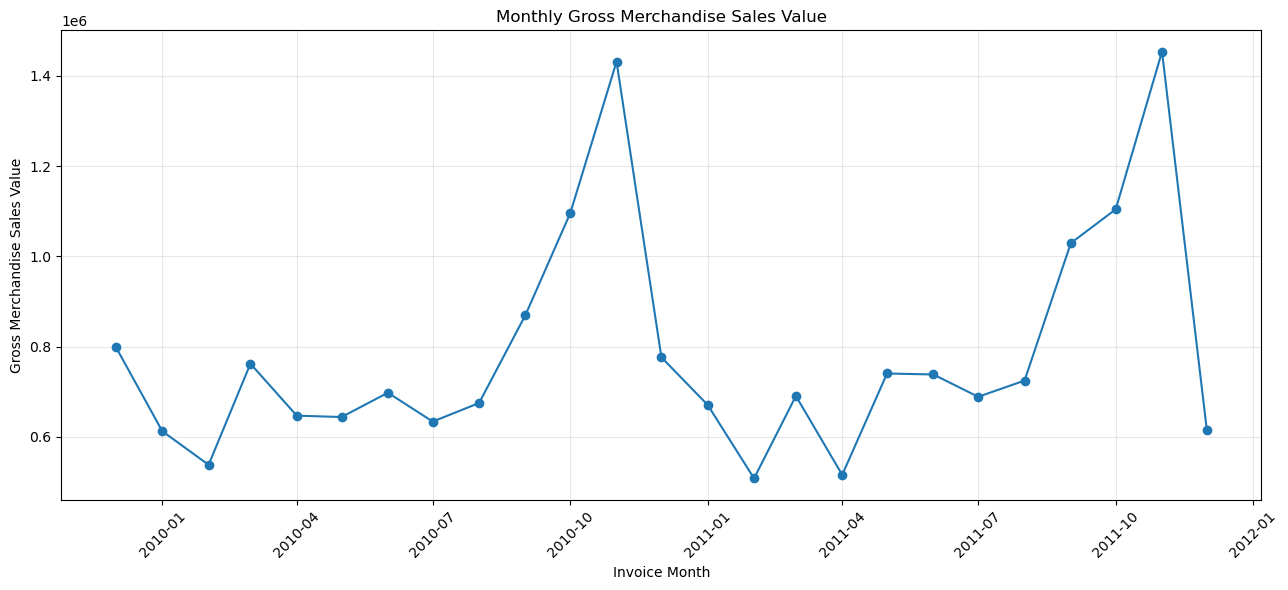

In [96]:
plt.figure(figsize=(13,6))
plt.plot(monthly_merchandise_sales["invoice_month"],monthly_merchandise_sales["gross_merchandise_sales_value"],marker = "o")
plt.title("Monthly Gross Merchandise Sales Value")
plt.xlabel("Invoice Month")
plt.ylabel("Gross Merchandise Sales Value")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

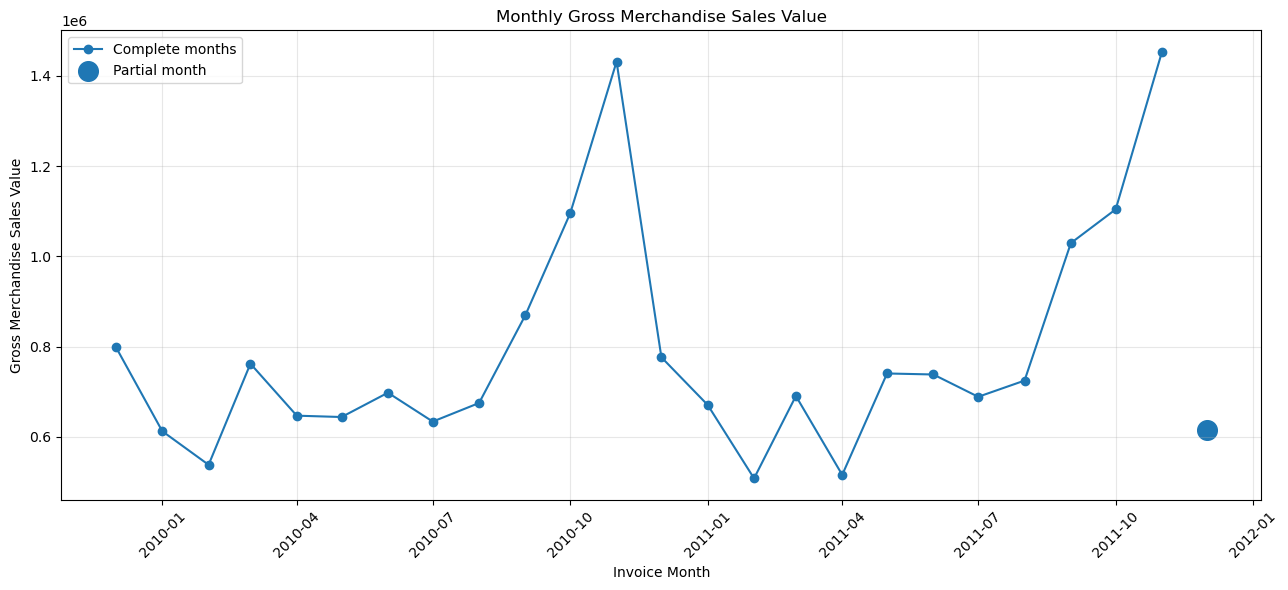

In [97]:
partial_months = monthly_merchandise_sales.loc[
    monthly_merchandise_sales["month_status"].eq("Partial month")
]

plt.figure(figsize=(13, 6))

# Connect only complete months
plt.plot(complete_monthly_sales["invoice_month"],complete_monthly_sales["gross_merchandise_sales_value"],marker="o",label="Complete months")

# Display partial months separately without connecting them
plt.scatter(partial_months["invoice_month"],partial_months["gross_merchandise_sales_value"],s=200,label="Partial month")

plt.title("Monthly Gross Merchandise Sales Value")
plt.xlabel("Invoice Month")
plt.ylabel("Gross Merchandise Sales Value")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [98]:
highest_sales_month = complete_monthly_sales.loc[complete_monthly_sales["gross_merchandise_sales_value"].idxmax()]

lowest_sales_month = complete_monthly_sales.loc[complete_monthly_sales["gross_merchandise_sales_value"].idxmin()]

highest_sales_month

invoice_month                        2011-11-01 00:00:00
gross_merchandise_sales_value               1,453,295.98
merchandise_invoice_count                           2753
total_merchandise_quantity                        746977
average_merchandise_invoice_value                 527.90
median_merchandise_invoice_value                  298.24
month_status                              Complete month
Name: 23, dtype: object

In [99]:
lowest_sales_month

invoice_month                        2011-02-01 00:00:00
gross_merchandise_sales_value                 508,081.54
merchandise_invoice_count                           1093
total_merchandise_quantity                        282635
average_merchandise_invoice_value                 464.85
median_merchandise_invoice_value                  303.00
month_status                              Complete month
Name: 14, dtype: object

#### Monthly Sales Trend Interpretation

Monthly merchandise sales displayed substantial variation across the observation period. Two prominent peaks occurred in November 2010 and November 2011, indicating a possible year-end seasonal pattern. However, only two annual cycles are available, so this pattern should be interpreted as suggestive rather than conclusive.

November 2011 was the highest complete month, generating 1,453,295.98 in gross positive merchandise sales across 2,753 invoices. February 2011 was the lowest complete month, with 508,081.54 across 1,093 invoices.

Sales in November 2011 were approximately 2.86 times those of February 2011, while invoice volume was approximately 2.52 times higher and merchandise quantity was approximately 2.64 times higher.

The average invoice value increased from 464.85 in February to 527.90 in November. However, the median invoice value decreased slightly from 303.00 to 298.24. This indicates that the November sales peak was driven primarily by a higher number of invoices and greater merchandise volume rather than a substantial increase in the value of a typical invoice.

December 2011 was retained in the visualisation but marked as a partial month because the dataset ends on 9 December. Its total sales and invoice count should therefore not be compared directly with complete calendar months.


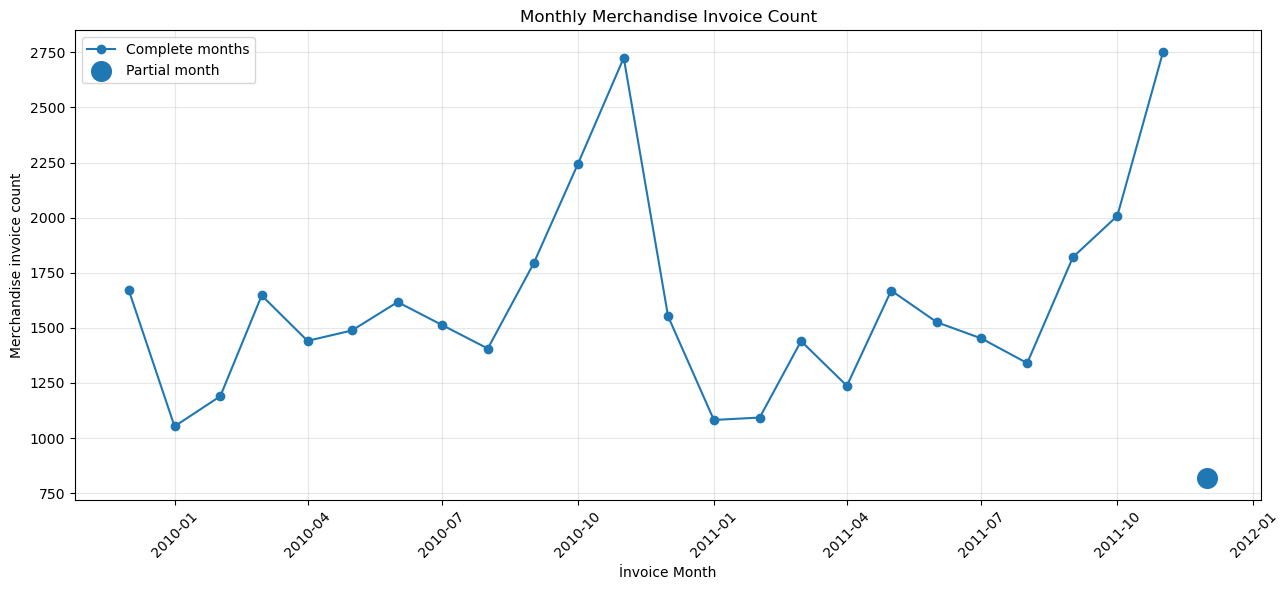

In [100]:
plt.figure(figsize=(13,6))

plt.plot(complete_monthly_sales["invoice_month"],complete_monthly_sales["merchandise_invoice_count"],label="Complete months",marker="o")

plt.scatter(partial_months["invoice_month"],partial_months["merchandise_invoice_count"],s=200,label="Partial month")

plt.title("Monthly Merchandise Invoice Count")
plt.xlabel("İnvoice Month")
plt.ylabel("Merchandise invoice count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [101]:
highest_invoice_month = complete_monthly_sales.loc[
    complete_monthly_sales[
        "merchandise_invoice_count"
    ].idxmax()
]

lowest_invoice_month = complete_monthly_sales.loc[
    complete_monthly_sales[
        "merchandise_invoice_count"
    ].idxmin()
]

highest_invoice_month

invoice_month                        2011-11-01 00:00:00
gross_merchandise_sales_value               1,453,295.98
merchandise_invoice_count                           2753
total_merchandise_quantity                        746977
average_merchandise_invoice_value                 527.90
median_merchandise_invoice_value                  298.24
month_status                              Complete month
Name: 23, dtype: object

In [102]:
lowest_invoice_month

invoice_month                        2010-01-01 00:00:00
gross_merchandise_sales_value                 612,605.50
merchandise_invoice_count                           1053
total_merchandise_quantity                        390440
average_merchandise_invoice_value                 581.77
median_merchandise_invoice_value                  307.66
month_status                              Complete month
Name: 1, dtype: object

#### Monthly Invoice Volume Interpretation

November 2011 recorded both the highest merchandise sales value and the
highest number of merchandise invoices, with 2,753 invoices generating
1,453,295.98 in gross positive merchandise sales.

However, its average and median invoice values were lower than those observed
in January 2010, the month with the fewest complete-month invoices. This
indicates that the November sales peak was primarily driven by higher invoice
volume rather than a substantial increase in the value of a typical order.

January 2010 had the lowest complete-month invoice count, with 1,053 invoices,
but it was not the lowest sales month because its average invoice value was
relatively high at 581.77.

February 2011 generated the lowest complete-month sales value despite having
slightly more invoices than January 2010. Its lower average invoice value of
464.85 resulted in a lower monthly sales total.

These findings demonstrate that monthly merchandise sales are influenced by
both invoice volume and invoice value. A low invoice count does not
necessarily produce the lowest sales value when average order values are
relatively high.

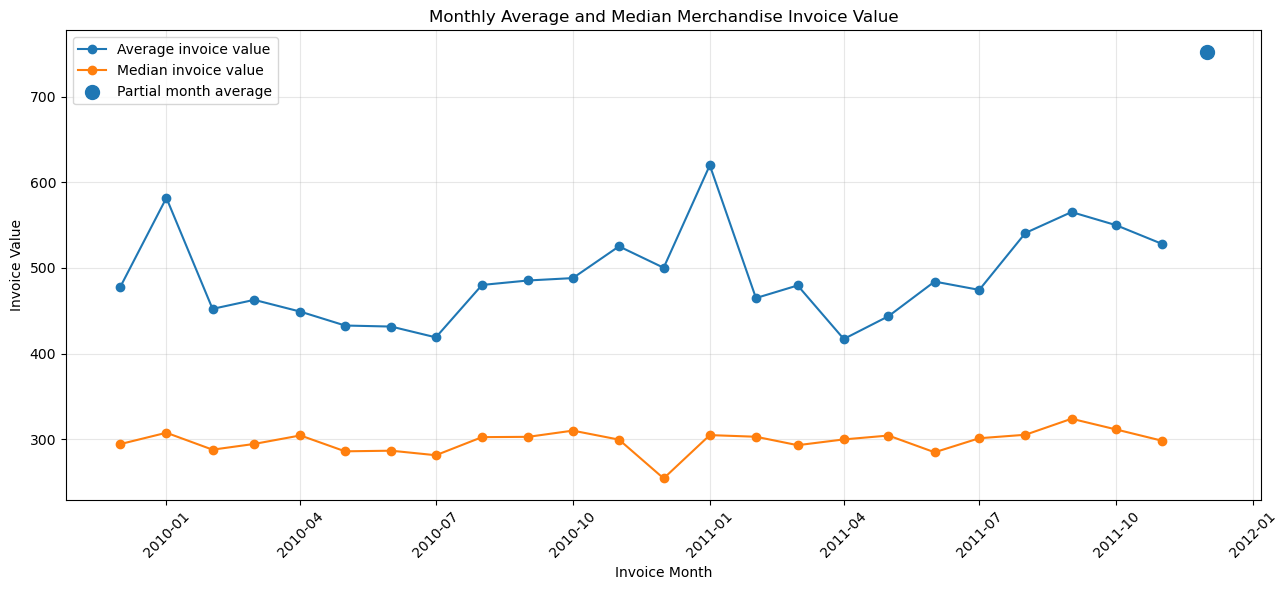

In [103]:
plt.figure(figsize=(13, 6))

plt.plot(complete_monthly_sales["invoice_month"],complete_monthly_sales["average_merchandise_invoice_value"],
         marker="o",
         label="Average invoice value")

plt.plot(complete_monthly_sales["invoice_month"],complete_monthly_sales["median_merchandise_invoice_value"],
    marker="o",
    label="Median invoice value")

plt.scatter(partial_months["invoice_month"],partial_months["average_merchandise_invoice_value"],
    s=100,
    label="Partial month average")

plt.title("Monthly Average and Median Merchandise Invoice Value")
plt.xlabel("Invoice Month")
plt.ylabel("Invoice Value")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [104]:
complete_monthly_sales["mean_median_gap"] = (complete_monthly_sales["average_merchandise_invoice_value"]
                                             - complete_monthly_sales["median_merchandise_invoice_value"])

In [105]:
complete_monthly_sales["mean_median_ratio"] = (complete_monthly_sales["average_merchandise_invoice_value"]
                                            / complete_monthly_sales["median_merchandise_invoice_value"])

In [106]:
complete_monthly_sales[
    [
        "invoice_month",
        "average_merchandise_invoice_value",
        "median_merchandise_invoice_value",
        "mean_median_gap",
        "mean_median_ratio"
    ]
].sort_values("mean_median_ratio",ascending=False).head()

,invoice_month,average_merchandise_invoice_value,median_merchandise_invoice_value,mean_median_gap,mean_median_ratio
13,2011-01-01,619.83,304.90,314.92,2.03
12,2010-12-01,500.21,254.39,245.82,1.97
1,2010-01-01,581.77,307.66,274.11,1.89
20,2011-08-01,540.83,305.31,235.52,1.77
23,2011-11-01,527.90,298.24,229.66,1.77


#### Average and Median Invoice Value Interpretation

The average merchandise invoice value remained consistently above the median throughout the observation period. This indicates that monthly invoice-value distributions were persistently right-skewed, with a relatively small number of high-value orders increasing the monthly averages.

The difference was particularly pronounced around January 2010 and January 2011. However, this does not necessarily indicate the sale of unusually expensive individual products. High invoice values may result from expensive products, large quantities of the same product, or highly diversified wholesale orders.

Median invoice values remained relatively stable compared with monthly averages. This suggests that the value of a typical invoice changed less substantially than the average, while large wholesale orders created greater volatility in monthly averages.

Therefore, average and median invoice values should be interpreted together. The median provides a more representative measure of a typical order, while the average reflects the contribution of high-value invoices to overall sales performance.

This finding also supports retaining large wholesale orders rather than removing them automatically as outliers. Their influence will instead be managed through transformations and scaling during customer-level modelling.


#### Monthly Mean–Median Gap

The average merchandise invoice value exceeded the median in every complete
month, confirming that invoice-value distributions were persistently
right-skewed.

January 2011 displayed the strongest relative difference. Its average invoice
value was 619.83, compared with a median of 304.90, producing a mean-to-median
ratio of 2.03. This indicates that high-value invoices increased the monthly
average to approximately twice the value of a typical invoice.

December 2010 and January 2010 also showed substantial differences between
average and median invoice values. High-value invoice effects were therefore
not limited to peak-sales months but appeared throughout the observation
period.

November 2011, the highest-sales month, had a mean-to-median ratio of 1.77.
Its sales peak was driven primarily by high invoice volume, although large
orders also increased the monthly average.

These findings indicate that average invoice values should not be interpreted
alone. Median values provide a more representative measure of a typical
invoice, while averages capture the contribution of high-value wholesale
orders.

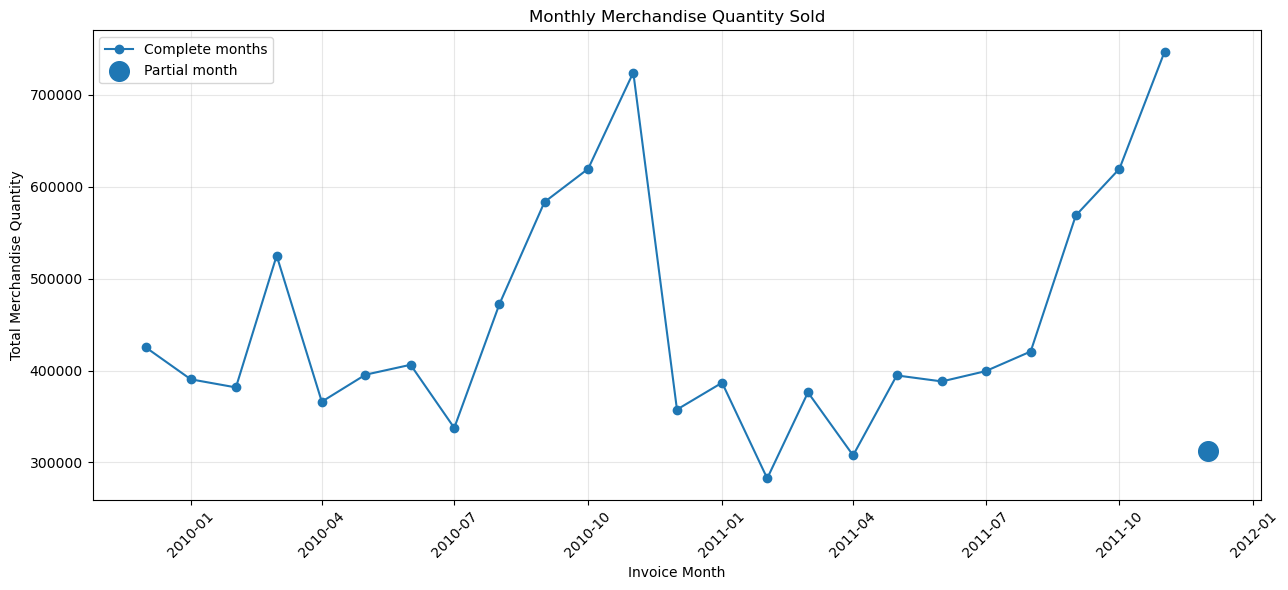

In [107]:
plt.figure(figsize=(13, 6))

plt.plot(complete_monthly_sales["invoice_month"],complete_monthly_sales["total_merchandise_quantity"],
    marker="o",
    label="Complete months"
)

plt.scatter(partial_months["invoice_month"],partial_months["total_merchandise_quantity"],
    s=200,
    label="Partial month"
)

plt.title("Monthly Merchandise Quantity Sold")
plt.xlabel("Invoice Month")
plt.ylabel("Total Merchandise Quantity")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [108]:
highest_quantity_month = complete_monthly_sales.loc[complete_monthly_sales["total_merchandise_quantity"].idxmax()]

lowest_quantity_month = complete_monthly_sales.loc[complete_monthly_sales["total_merchandise_quantity"].idxmin()]

highest_quantity_month

invoice_month                        2011-11-01 00:00:00
gross_merchandise_sales_value               1,453,295.98
merchandise_invoice_count                           2753
total_merchandise_quantity                        746977
average_merchandise_invoice_value                 527.90
median_merchandise_invoice_value                  298.24
month_status                              Complete month
mean_median_gap                                   229.66
mean_median_ratio                                   1.77
Name: 23, dtype: object

In [109]:
lowest_quantity_month

invoice_month                        2011-02-01 00:00:00
gross_merchandise_sales_value                 508,081.54
merchandise_invoice_count                           1093
total_merchandise_quantity                        282635
average_merchandise_invoice_value                 464.85
median_merchandise_invoice_value                  303.00
month_status                              Complete month
mean_median_gap                                   161.85
mean_median_ratio                                   1.53
Name: 14, dtype: object

In [110]:
monthly_merchandise_sales["average_quantity_per_invoice"] = (
    monthly_merchandise_sales["total_merchandise_quantity"]  / monthly_merchandise_sales["merchandise_invoice_count"])

In [111]:
complete_monthly_sales = (
    monthly_merchandise_sales.loc[monthly_merchandise_sales["month_status"].eq("Complete month")].copy()
)

In [112]:
complete_monthly_sales[
    [
        "invoice_month",
        "merchandise_invoice_count",
        "total_merchandise_quantity",
        "average_quantity_per_invoice"
    ]
].sort_values("total_merchandise_quantity",ascending=False).head()

,invoice_month,merchandise_invoice_count,total_merchandise_quantity,average_quantity_per_invoice
23,2011-11-01,2753,746977,271.33
11,2010-11-01,2725,724300,265.80
22,2011-10-01,2008,619615,308.57
10,2010-10-01,2244,619532,276.08
9,2010-09-01,1792,583381,325.55


#### Monthly Merchandise Quantity Interpretation

Monthly merchandise quantity followed a pattern similar to both gross
merchandise sales value and invoice volume. November 2011 recorded the highest
complete-month quantity, with 746,977 merchandise units sold across 2,753
invoices. February 2011 recorded the lowest quantity, with 282,635 units across
1,093 invoices.

November 2011 contained approximately 271 merchandise units per invoice,
compared with approximately 259 in February 2011. Therefore, the November
quantity peak was driven primarily by a substantially higher number of
invoices rather than a major increase in merchandise quantity per order.

The simultaneous peaks in merchandise value, invoice volume, and quantity
during November 2010 and November 2011 suggest a possible year-end seasonal
increase in demand. However, the dataset contains only two annual cycles, so
this pattern should be treated as suggestive rather than conclusive.

These results show that monthly performance should be evaluated through
invoice volume, invoice value, and merchandise quantity together. No single
metric fully explains monthly sales variation.

### Country-Level Merchandise Sales Analysis

Country-level performance is analysed using the invoice-level merchandise
table. Each invoice contributes once to the country associated with that
order.

The analysis compares countries through:

- gross positive merchandise sales value,
- merchandise invoice count,
- total merchandise quantity,
- average invoice value,
- median invoice value,
- share of total merchandise sales.

Transactions without a known customer identifier are retained because country
and invoice information is still available. Therefore, this analysis describes
overall merchandise activity rather than only identified customers.

In [113]:
country_merchandise_sales = (invoice_sales.groupby("country", as_index=False).agg(
        gross_merchandise_sales_value=("invoice_total","sum"),
        merchandise_invoice_count=("Invoice","size"),
        total_merchandise_quantity=("total_quantity","sum"),
        average_merchandise_invoice_value=("invoice_total","mean"),
        median_merchandise_invoice_value=("invoice_total","median")
    )
)

In [114]:
country_merchandise_sales["sales_share_pct"] = (country_merchandise_sales["gross_merchandise_sales_value"]
                                                / country_merchandise_sales["gross_merchandise_sales_value"].sum()* 100)

In [115]:
country_merchandise_sales["invoice_share_pct"] = (country_merchandise_sales["merchandise_invoice_count"]
                                                / country_merchandise_sales["merchandise_invoice_count"].sum()* 100)

In [116]:
country_merchandise_sales = (country_merchandise_sales.sort_values("gross_merchandise_sales_value",ascending=False).reset_index(drop=True))

country_merchandise_sales.head(10)

,country,gross_merchandise_sales_value,merchandise_invoice_count,total_merchandise_quantity,average_merchandise_invoice_value,median_merchandise_invoice_value,sales_share_pct,invoice_share_pct
0,United Kingdom,"16,807,646.59",36237,9176614,463.83,294.88,85.49,91.56
1,EIRE,"633,284.16",586,336288,"1,080.69",702.78,3.22,1.48
2,Netherlands,"549,773.41",216,383625,"2,545.25",657.08,2.80,0.55
3,Germany,"383,289.00",753,223089,509.02,360.30,1.95,1.90
4,France,"311,486.29",601,270587,518.28,358.88,1.58,1.52
5,Australia,"167,800.01",89,103753,"1,885.39",392.98,0.85,0.22
6,Spain,"97,766.75",144,49996,678.94,364.37,0.50,0.36
7,Switzerland,"94,024.59",85,52612,"1,106.17",507.24,0.48,0.21
8,Sweden,"86,319.14",99,88537,871.91,374.20,0.44,0.25
9,Denmark,"67,422.69",42,237406,"1,605.30",703.74,0.34,0.11


#### Country-Level Sales Interpretation

Merchandise sales were highly concentrated in the United Kingdom, which
accounted for 85.49% of gross positive merchandise sales and 91.56% of
merchandise invoices.

The United Kingdom generated the largest sales volume, although its invoice
share exceeded its sales share. This indicates that it was primarily a
high-volume market with lower average invoice values than several international
markets.

EIRE, the Netherlands, Australia, Switzerland, and Denmark generated
disproportionately high sales values relative to their invoice counts. The
Netherlands, for example, accounted for only 0.55% of invoices but 2.80% of
sales, with an average invoice value of 2,545.25.

Large differences between average and median invoice values were observed in
markets such as the Netherlands and Australia. These differences indicate that
a small number of high-value wholesale orders substantially increased country
averages.

Germany and France displayed more balanced profiles, with similar invoice and
sales shares and less extreme differences between average and median invoice
values.

Country-level averages should be interpreted cautiously for markets with small
invoice counts, since a few large wholesale orders may have a substantial
effect on their results.

In [117]:
country_merchandise_sales["average_quantity_per_invoice"] = (country_merchandise_sales["total_merchandise_quantity"]
                                                            / country_merchandise_sales["merchandise_invoice_count"])

country_merchandise_sales["mean_median_invoice_ratio"] = (country_merchandise_sales["average_merchandise_invoice_value"]
                                                            / country_merchandise_sales[ "median_merchandise_invoice_value"])

country_merchandise_sales["sales_to_invoice_share_ratio"] = (country_merchandise_sales["sales_share_pct"]
                                                             / country_merchandise_sales["invoice_share_pct"])

In [118]:
country_merchandise_sales[
    [
        "country",
        "merchandise_invoice_count",
        "average_quantity_per_invoice",
        "average_merchandise_invoice_value",
        "median_merchandise_invoice_value",
        "mean_median_invoice_ratio",
        "sales_share_pct",
        "invoice_share_pct",
        "sales_to_invoice_share_ratio"
    ]
].head(10)

,country,merchandise_invoice_count,average_quantity_per_invoice,average_merchandise_invoice_value,median_merchandise_invoice_value,mean_median_invoice_ratio,sales_share_pct,invoice_share_pct,sales_to_invoice_share_ratio
0,United Kingdom,36237,253.24,463.83,294.88,1.57,85.49,91.56,0.93
1,EIRE,586,573.87,"1,080.69",702.78,1.54,3.22,1.48,2.18
2,Netherlands,216,"1,776.04","2,545.25",657.08,3.87,2.80,0.55,5.12
3,Germany,753,296.27,509.02,360.30,1.41,1.95,1.90,1.02
4,France,601,450.23,518.28,358.88,1.44,1.58,1.52,1.04
5,Australia,89,"1,165.76","1,885.39",392.98,4.80,0.85,0.22,3.80
6,Spain,144,347.19,678.94,364.37,1.86,0.50,0.36,1.37
7,Switzerland,85,618.96,"1,106.17",507.24,2.18,0.48,0.21,2.23
8,Sweden,99,894.31,871.91,374.20,2.33,0.44,0.25,1.76
9,Denmark,42,"5,652.52","1,605.30",703.74,2.28,0.34,0.11,3.23


#### Extended Country-Level Interpretation

The United Kingdom was primarily a high-volume market. It accounted for
91.56% of merchandise invoices but 85.49% of merchandise sales, producing a
sales-to-invoice share ratio of 0.93. Its average invoice value was therefore
slightly below the overall merchandise invoice average.

Several international markets generated disproportionately high sales values
relative to their invoice counts. The Netherlands represented only 0.55% of
invoices but 2.80% of sales, producing a sales-to-invoice share ratio of 5.12.
Its average invoice value was approximately five times the overall average.

However, the Netherlands and Australia also displayed large differences
between average and median invoice values. Their mean-to-median ratios of 3.87
and 4.80 indicate that a limited number of high-value wholesale orders had a
substantial effect on their averages.

EIRE displayed a more consistently high-value profile. Both its average and
median invoice values were high, while its mean-to-median ratio was less
extreme at 1.54.

Germany and France showed more balanced market structures. Their sales shares
were close to their invoice shares, and their average invoice values were
close to the overall average.

Denmark recorded an exceptionally high average quantity per invoice, suggesting
large-volume wholesale purchases. However, its results were based on only 42
invoices and should therefore be interpreted cautiously.

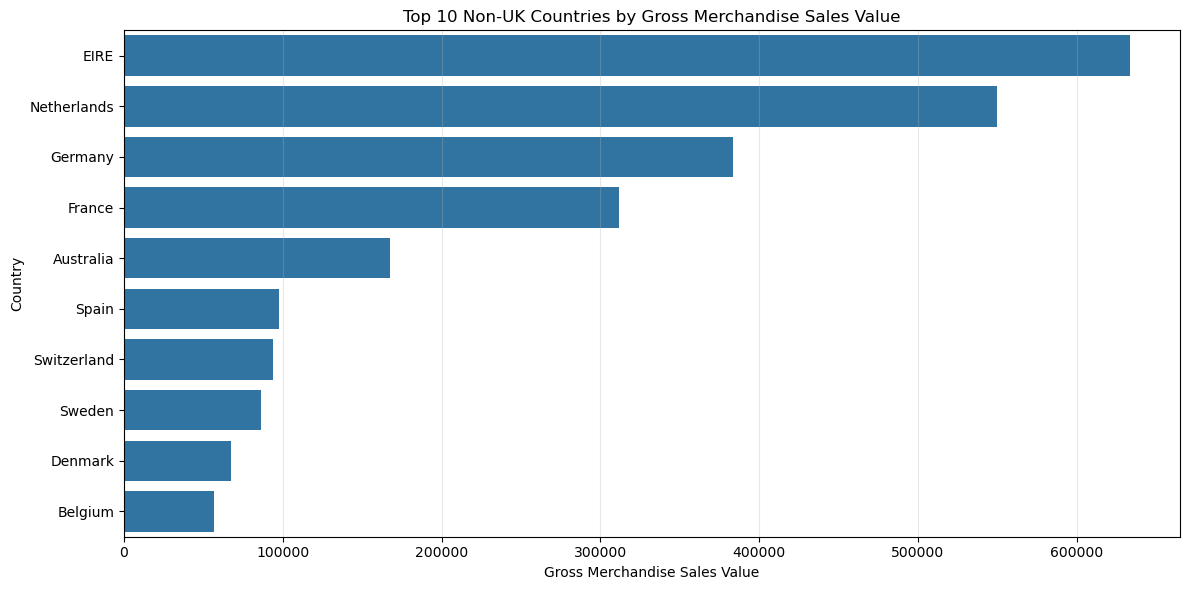

In [119]:
top_non_uk_countries = (country_merchandise_sales.loc[country_merchandise_sales["country"].ne("United Kingdom")]
    .nlargest(10,"gross_merchandise_sales_value")
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_non_uk_countries,
    x="gross_merchandise_sales_value",
    y="country",
    order=top_non_uk_countries["country"].tolist(),
    errorbar=None
)

plt.title(
    "Top 10 Non-UK Countries by Gross Merchandise Sales Value"
)
plt.xlabel("Gross Merchandise Sales Value")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

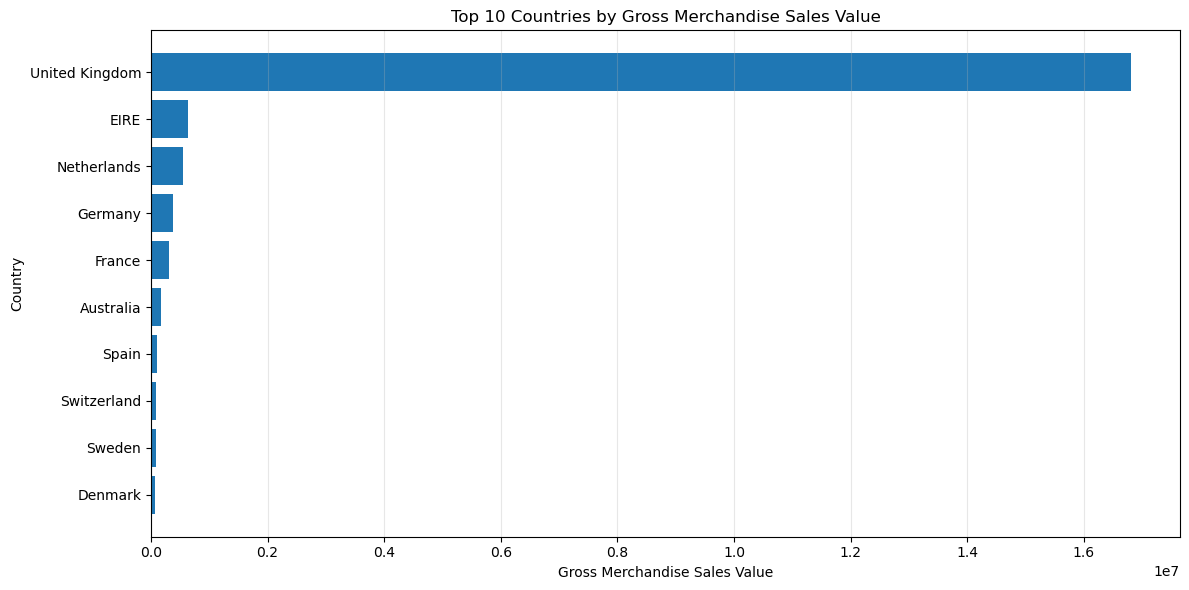

In [120]:
top_10_countries = country_merchandise_sales.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_countries["country"],
    top_10_countries["gross_merchandise_sales_value"]
)

plt.title("Top 10 Countries by Gross Merchandise Sales Value")
plt.xlabel("Gross Merchandise Sales Value")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

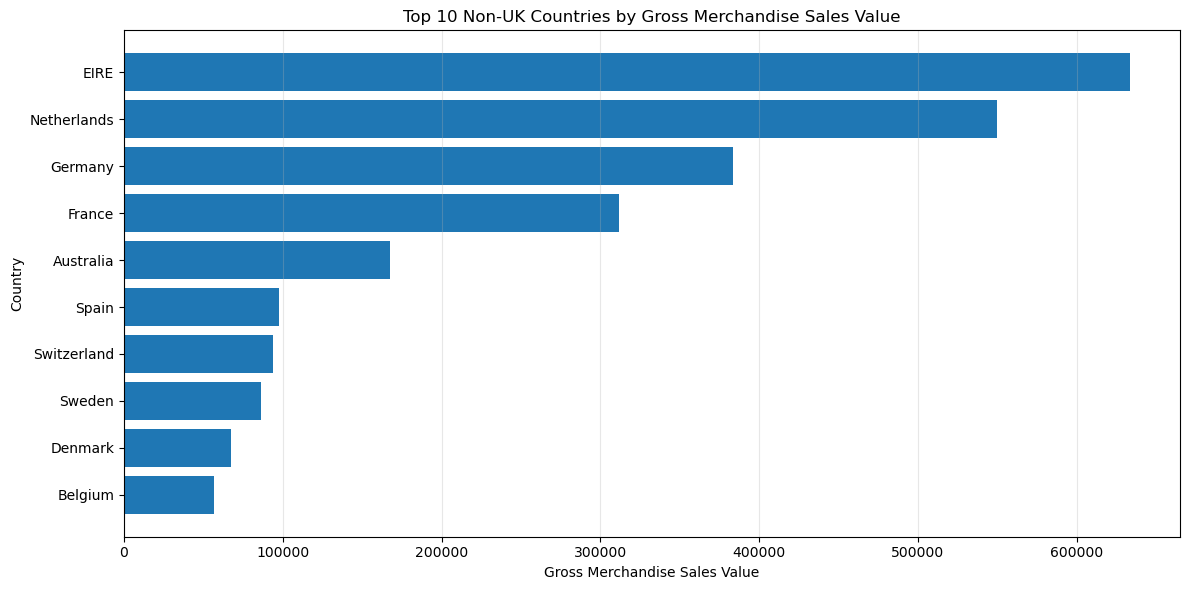

In [121]:
top_non_uk_countries = (
    country_merchandise_sales.loc[ country_merchandise_sales["country"] != ("United Kingdom")].head(10))

plt.figure(figsize=(12, 6))

plt.barh(
    top_non_uk_countries["country"],
    top_non_uk_countries[
        "gross_merchandise_sales_value"
    ]
)

plt.title(
    "Top 10 Non-UK Countries by Gross Merchandise Sales Value"
)
plt.xlabel("Gross Merchandise Sales Value")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Product-Level Merchandise Sales Analysis

Product performance is evaluated using all valid merchandise transaction
lines, including transactions without a known customer identifier.

Products are compared using sales value, purchased quantity, invoice reach and
sales concentration.

#### Transaction Scope

Both `sales_transactions` and `customer_sales` contain positive merchandise
transaction lines after clearly identifiable postage, fee, and accounting
entries were excluded.

The main difference between the two tables is customer identification:

- `sales_transactions` contains all merchandise transaction lines, including
  transactions both with and without a known `Customer ID`.

- `customer_sales` is a subset of `sales_transactions` that contains only
  transaction lines associated with a known customer identifier.

Product-level analysis does not require customer identification. Therefore,
`sales_transactions` is used so that merchandise sales linked to missing
customer identifiers are not unnecessarily excluded from product quantities,
sales values, and invoice counts.

The `customer_sales` table will be used only for analyses that require customer
identity, such as customer-level feature engineering, RFM analysis, clustering,
cohort analysis, and repeat-purchase modelling.

In [122]:
# Use sales_transactions for product analysis because product performance
# does not require a known customer identifier.
#
# sales_transactions -> all merchandise transaction lines
# customer_sales     -> merchandise lines with a known Customer ID only
#
# Using customer_sales here would exclude valid product sales associated
# with missing customer identifiers and underestimate product performance.

In [123]:
# Standardize superficial text differences without changing
# potentially meaningful product-description differences
sales_transactions["Description_normalized"] = (
    sales_transactions["Description"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", " ", regex=True)
)

In [124]:
product_merchandise_sales = (sales_transactions.groupby(["StockCode", "Description_normalized"],as_index=False,dropna=False).agg(
        gross_merchandise_sales_value=("LineTotal","sum"),
        total_quantity=("Quantity","sum"),
        invoice_count=("Invoice","nunique"),
        line_count=("Invoice","size")
        )
)

In [125]:
product_merchandise_sales.head()

,StockCode,Description_normalized,gross_merchandise_sales_value,total_quantity,invoice_count,line_count
0,10002,INFLATABLE POLITICAL GLOBE,"6,942.26",8671,362,367
1,10080,GROOVY CACTUS INFLATABLE,129.29,315,27,28
2,10109,BENDY COLOUR PENCILS,1.68,4,1,1
3,10120,DOGGY RUBBER,142.74,664,73,73
4,10125,MINI FUNKY DESIGN TAPES,"1,715.78",2103,167,173


In [126]:
product_merchandise_sales.describe()

,gross_merchandise_sales_value,total_quantity,invoice_count,line_count
count,"5,585.00","5,585.00","5,585.00","5,585.00"
mean,"3,520.33","2,003.35",177.70,179.72
std,"9,840.14","5,124.77",294.45,298.48
min,0.02,1.00,1.00,1.00
25%,192.17,78.00,17.00,18.00
50%,918.65,477.00,71.00,72.00
75%,"3,047.91","1,826.00",212.00,214.00
max,"330,590.32","106,139.00","5,356.00","5,502.00"


#### Product Summary Distribution

The product-level table contained 5,585 unique `StockCode` and normalised
description combinations. This number exceeded the number of unique stock
codes because some stock codes were associated with multiple product
descriptions or package formats.

Product performance was strongly right-skewed. The average merchandise sales
value per product group was substantially higher than the median, indicating
that a limited number of high-performing products generated a disproportionate
share of merchandise sales.

Quantity and invoice-frequency distributions displayed a similar pattern.
Most products appeared in a relatively limited number of invoices, while a
small group of widely purchased products occurred across several thousand
orders.

In [127]:
# Verify that product aggregation preserved the full merchandise totals
product_aggregation_checks = pd.Series({
    "sales_value_matches": np.isclose(
        product_merchandise_sales[
            "gross_merchandise_sales_value"
        ].sum(),
        sales_transactions["LineTotal"].sum()
    ),

    "quantity_matches": np.isclose(
        product_merchandise_sales[
            "total_quantity"
        ].sum(),
        sales_transactions["Quantity"].sum()
    )
})

product_aggregation_checks

sales_value_matches    True
quantity_matches       True
dtype: bool

In [128]:
# Calculate each product group's contribution to overall merchandise sales
product_merchandise_sales["sales_share_pct"] = (
    product_merchandise_sales[
        "gross_merchandise_sales_value"
    ]
    / product_merchandise_sales[
        "gross_merchandise_sales_value"
    ].sum()
    * 100
)

# Measure the average quantity sold whenever the product appeared in an invoice
product_merchandise_sales[
    "average_quantity_per_invoice"
] = (
    product_merchandise_sales["total_quantity"]
    / product_merchandise_sales["invoice_count"]
)

In [129]:
product_merchandise_sales = (product_merchandise_sales.sort_values("gross_merchandise_sales_value",ascending=False).reset_index(drop=True))

In [130]:
top_products_by_sales = (product_merchandise_sales.nlargest(10,"gross_merchandise_sales_value"))


top_products_by_sales[
    [
        "StockCode",
        "Description_normalized",
        "gross_merchandise_sales_value",
        "sales_share_pct",
        "total_quantity",
        "invoice_count",
        "average_quantity_per_invoice"
    ]
]

,StockCode,Description_normalized,gross_merchandise_sales_value,sales_share_pct,total_quantity,invoice_count,average_quantity_per_invoice
0,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",1.68,26478,3918,6.76
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",1.31,94142,5356,17.58
2,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",0.86,80995,1,"80,995.00"
3,47566,PARTY BUNTING,"148,318.28",0.75,28200,2674,10.55
4,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",0.74,77280,3245,23.82
5,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",0.66,80082,2807,28.53
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",0.60,35084,2018,17.39
7,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",0.42,78033,247,315.92
8,79321,CHILLI LIGHTS,"80,540.88",0.41,15841,1135,13.96
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"71,300.40",0.36,31409,756,41.55


In [131]:
top_products_by_quantity = (
    product_merchandise_sales
    .nlargest(
        10,
        "total_quantity"
    )
)

top_products_by_quantity[
    [
        "StockCode",
        "Description_normalized",
        "total_quantity",
        "gross_merchandise_sales_value",
        "invoice_count",
        "average_quantity_per_invoice"
    ]
]

,StockCode,Description_normalized,total_quantity,gross_merchandise_sales_value,invoice_count,average_quantity_per_invoice
147,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106139,"24,445.61",1019,104.16
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,94142,"257,546.20",5356,17.58
2,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1,"80,995.00"
5,84879,ASSORTED COLOUR BIRD ORNAMENT,80082,"129,324.49",2807,28.53
7,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92",247,315.92
4,85099B,JUMBO BAG RED RETROSPOT,77280,"145,961.83",3245,23.82
289,17003,BROCADE RING PURSE,70369,"14,766.42",456,154.32
109,21977,PACK OF 60 PINK PAISLEY CAKE CASES,56061,"28,081.73",1993,28.13
120,84991,60 TEATIME FAIRY CAKE CASES,54028,"27,041.21",2127,25.40
44,22197,SMALL POPCORN HOLDER,48561,"42,699.89",1407,34.51


In [132]:
top_products_by_invoice_count = (
    product_merchandise_sales
    .nlargest(
        10,
        "invoice_count"
    )
)

top_products_by_invoice_count[
    [
        "StockCode",
        "Description_normalized",
        "invoice_count",
        "total_quantity",
        "gross_merchandise_sales_value",
        "average_quantity_per_invoice"
    ]
]

,StockCode,Description_normalized,invoice_count,total_quantity,gross_merchandise_sales_value,average_quantity_per_invoice
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5356,94142,"257,546.20",17.58
0,22423,REGENCY CAKESTAND 3 TIER,3918,26478,"330,590.32",6.76
4,85099B,JUMBO BAG RED RETROSPOT,3245,77280,"145,961.83",23.82
5,84879,ASSORTED COLOUR BIRD ORNAMENT,2807,80082,"129,324.49",28.53
3,47566,PARTY BUNTING,2674,28200,"148,318.28",10.55
47,22383,LUNCH BAG SUKI DESIGN,2363,24648,"42,592.72",10.43
38,20727,LUNCH BAG BLACK SKULL.,2351,26678,"45,655.27",11.35
13,21931,JUMBO STORAGE BAG SUKI,2329,29182,"61,537.55",12.53
35,21232,STRAWBERRY CERAMIC TRINKET BOX,2310,36628,"47,169.35",15.86
20,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,2192,27281,"57,318.71",12.45


In [133]:
# Approximate the average merchandise sales value generated per unit
product_merchandise_sales["average_sales_value_per_unit"] = (product_merchandise_sales["gross_merchandise_sales_value"]
                                                             / product_merchandise_sales["total_quantity"])

In [134]:
selected_product_codes = [
    "22423",
    "85123A",
    "23843",
    "23166",
    "84077",
    "17003"
]

product_merchandise_sales.loc[
    product_merchandise_sales["StockCode"]
    .astype(str)
    .isin(selected_product_codes),
    [
        "StockCode",
        "Description_normalized",
        "gross_merchandise_sales_value",
        "total_quantity",
        "invoice_count",
        "average_quantity_per_invoice",
        "average_sales_value_per_unit"
    ]
].sort_values(
    "gross_merchandise_sales_value",
    ascending=False
)

,StockCode,Description_normalized,gross_merchandise_sales_value,total_quantity,invoice_count,average_quantity_per_invoice,average_sales_value_per_unit
0,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26478,3918,6.76,12.49
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94142,5356,17.58,2.74
2,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,"80,995.00",2.08
7,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,315.92,1.05
147,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"24,445.61",106139,1019,104.16,0.23
289,17003,BROCADE RING PURSE,"14,766.42",70369,456,154.32,0.21
4247,85123A,CREAM HANGING HEART T-LIGHT HOLDER,178.51,61,9,6.78,2.93


In [135]:
top_sales_plot = top_products_by_sales.copy()

top_sales_plot["product_label"] = (top_sales_plot["StockCode"].astype(str)+ " | "+ top_sales_plot["Description_normalized"])

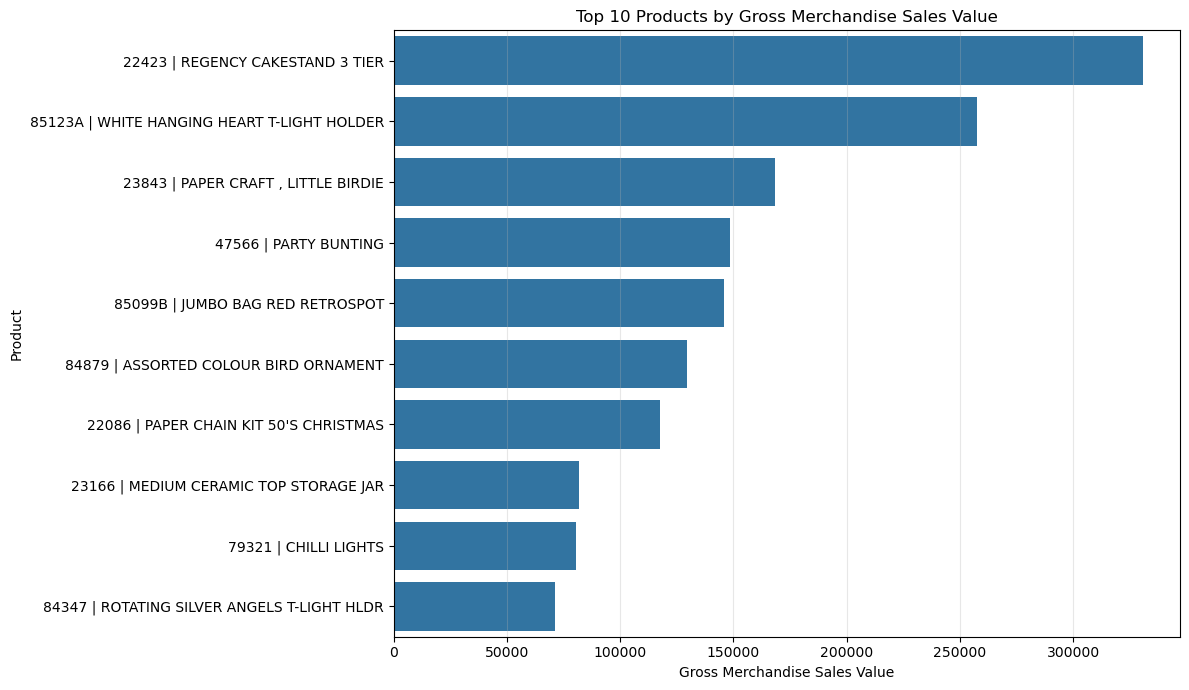

In [136]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_sales_plot,
    x="gross_merchandise_sales_value",
    y="product_label",
    order=top_sales_plot["product_label"].tolist(),
    errorbar=None
)

plt.title("Top 10 Products by Gross Merchandise Sales Value")
plt.xlabel("Gross Merchandise Sales Value")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

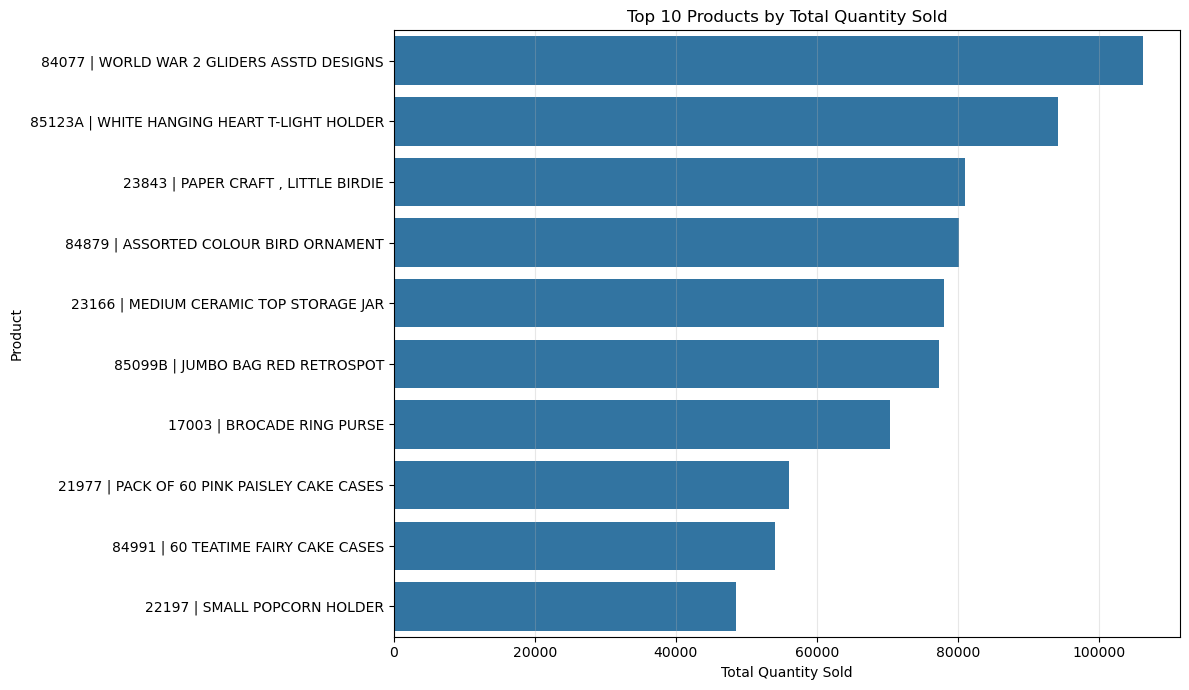

In [137]:
top_quantity_plot = top_products_by_quantity.copy()

top_quantity_plot["product_label"] = (top_quantity_plot["StockCode"].astype(str) + " | " + top_quantity_plot["Description_normalized"])

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_quantity_plot,
    x="total_quantity",
    y="product_label",
    order=top_quantity_plot["product_label"].tolist(),
    errorbar=None
)

plt.title("Top 10 Products by Total Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

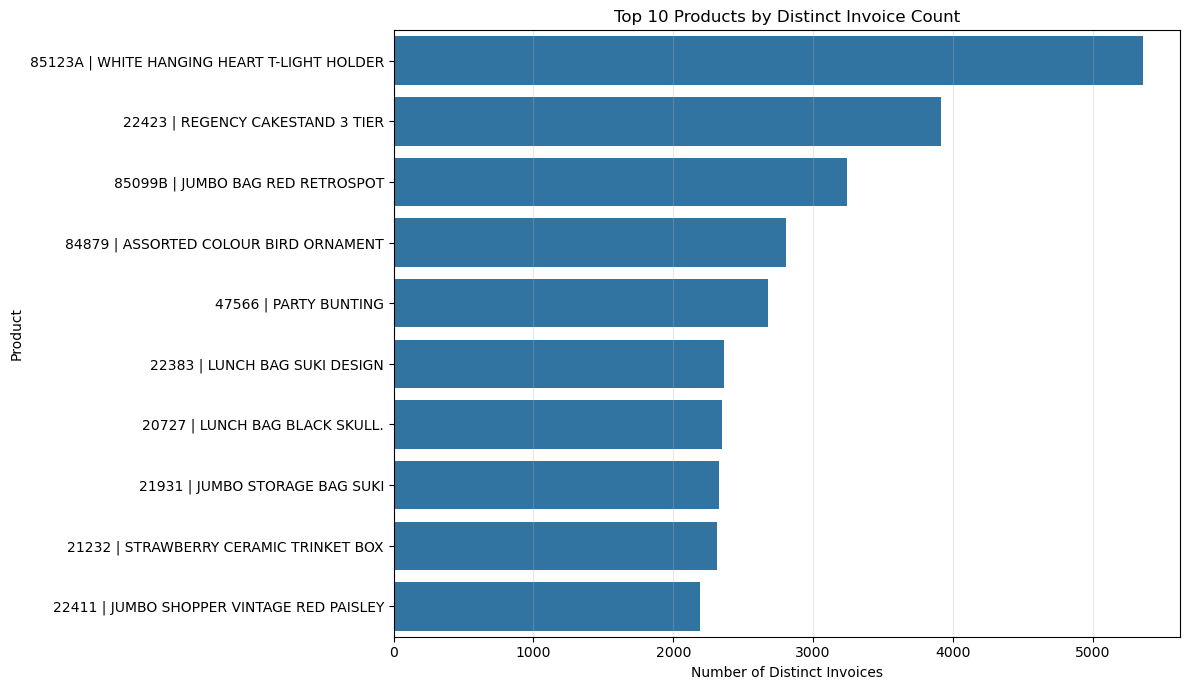

In [138]:
top_invoice_plot = top_products_by_invoice_count.copy()

top_invoice_plot["product_label"] = (top_invoice_plot["StockCode"].astype(str)+ " | "+ top_invoice_plot["Description_normalized"])

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_invoice_plot,
    x="invoice_count",
    y="product_label",
    order=top_invoice_plot["product_label"].tolist(),
    errorbar=None
)

plt.title("Top 10 Products by Distinct Invoice Count")
plt.xlabel("Number of Distinct Invoices")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

#### Product Performance Interpretation

Product performance differed depending on whether it was evaluated through
sales value, quantity, or invoice reach.

`WHITE HANGING HEART T-LIGHT HOLDER` displayed one of the strongest overall
product profiles. It ranked near the top in merchandise sales value and
quantity while appearing in the highest number of distinct invoices. Its
performance therefore reflected broad and recurring demand rather than a
limited number of wholesale orders.

`REGENCY CAKESTAND 3 TIER` generated the highest merchandise sales value and
appeared in a large number of invoices, despite having a relatively low
average quantity per invoice. This suggests that its performance was driven
by broad demand and comparatively high value per unit.

In contrast, `PAPER CRAFT, LITTLE BIRDIE` recorded 80,995 units in only one
invoice. Its position among the highest-sales and highest-quantity products
was therefore caused by a single exceptional transaction rather than recurring
product demand. This transaction should also be interpreted within the
project's gross positive merchandise scope, since a corresponding cancellation
was excluded from the positive-sales layer.

`MEDIUM CERAMIC TOP STORAGE JAR` also displayed a wholesale-oriented profile,
with a high total quantity concentrated across a relatively small number of
invoices.

Several products, including `JUMBO BAG RED RETROSPOT`, `ASSORTED COLOUR BIRD
ORNAMENT`, and `PARTY BUNTING`, performed strongly across multiple measures.
These products combined high merchandise value with broad invoice presence
and may therefore be considered core merchandise products.

Products with high quantity but substantially lower sales value, such as
`WORLD WAR 2 GLIDERS ASSTD DESIGNS`, represented high-volume and low-value
product activity.

In [139]:
import plotly.express as px

interactive_product_scatter = (
    product_merchandise_sales.loc[product_merchandise_sales["gross_merchandise_sales_value"].gt(0)
        & product_merchandise_sales["invoice_count"].gt(0)].copy())

interactive_product_scatter["product_label"] = (interactive_product_scatter["StockCode"].astype(str)+ " | "+ 
                                                interactive_product_scatter["Description_normalized"])

fig = px.scatter(
    interactive_product_scatter,
    x="invoice_count",
    y="gross_merchandise_sales_value",
    size="total_quantity",
    hover_name="product_label",
    hover_data={
        "StockCode": False,
        "Description_normalized": False,
        "invoice_count": ":,",
        "gross_merchandise_sales_value": ":,.2f",
        "total_quantity": ":,",
        "average_quantity_per_invoice": ":,.2f",
        "sales_share_pct": ":.3f",
        "product_label": False
    },
    log_x=True,
    log_y=True,
    size_max=45,
    render_mode="webgl",
    labels={
        "invoice_count": "Distinct Invoice Count",
        "gross_merchandise_sales_value":
            "Gross Merchandise Sales Value",
        "total_quantity": "Total Quantity",
        "average_quantity_per_invoice":
            "Average Quantity per Invoice",
        "sales_share_pct": "Sales Share (%)"
    },
    title="Interactive Product Sales Value vs. Invoice Reach"
)

fig.update_layout(
    width=1100,
    height=700
)

fig.show()

In [140]:
#Sağ üst
#→ Çok sayıda faturada bulunan ve yüksek satış üreten güçlü ürünler

#Sol üst
#→ Az sayıda faturadan yüksek satış üreten toplu veya sıra dışı ürünler

#Sağ alt
#→ Çok sayıda faturada bulunan fakat düşük parasal değerli yaygın ürünler

#Sol alt
#→ Düşük hacimli ve düşük satış değerli ürünler

In [141]:
# Sort products from highest to lowest merchandise sales value
product_sales_concentration = (product_merchandise_sales.sort_values("gross_merchandise_sales_value",ascending=False).reset_index(drop=True)
                .copy()
)

# Calculate cumulative contribution to total merchandise sales
product_sales_concentration["cumulative_sales_share_pct"] = (product_sales_concentration["sales_share_pct"].cumsum())

top_10_sales_share_pct = (product_sales_concentration.head(10)["sales_share_pct"].sum())

products_needed_for_80_pct = ((product_sales_concentration["cumulative_sales_share_pct"] >=80).idxmax()+ 1)

product_concentration_summary = pd.Series({
    "total_product_groups": len(product_sales_concentration),
    "top_10_product_sales_share_pct":top_10_sales_share_pct,
    "products_needed_for_80_pct_of_sales":products_needed_for_80_pct,
    "product_share_needed_for_80_pct": (products_needed_for_80_pct/ len(product_sales_concentration)* 100)
})

product_concentration_summary

total_product_groups                  5,585.00
top_10_product_sales_share_pct            7.79
products_needed_for_80_pct_of_sales   1,187.00
product_share_needed_for_80_pct          21.25
dtype: float64

#### Product Sales Concentration

The top 10 product groups generated 7.79% of total gross merchandise sales.
Although these products were commercially important, merchandise performance
was not dependent on only a small number of individual products.

A total of 1,187 product groups, representing 21.25% of all product groups,
were required to reach 80% of merchandise sales value. This result was close
to the traditional 80/20 concentration pattern.

The findings indicate that sales value was concentrated within approximately
one-fifth of the product portfolio. However, this concentration was distributed
across a relatively broad group of products rather than being dominated by
only the top few products.

The remaining 4,398 product groups collectively generated 20% of merchandise
sales. These products should not automatically be considered unimportant,
since profitability, strategic role, and inventory cost information were not
available in the dataset.

#### 5. Customer Modelling Datase

CCustomer-level analysis requires transactions that can be linked to a valid
customer identifier.

This section constructs the customer-modelling dataset by:

1. aggregating merchandise transactions to customer and invoice level,
2. examining customer-linked cancellations,
3. matching exact cancellation and positive-sale pairs,
4. removing only successfully matched cancelled sales,
5. rebuilding the final customer-level behavioural features.

The original positive merchandise table is preserved for auditing, while the
exact-match-adjusted table is used for RFM, clustering, cohort and
classification analyses.

In [142]:
customer_sales.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_standard_cancellation,is_cancelled_invoice_exception,is_manual_transaction,is_cancelled,is_negative_quantity,transaction_type,LineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,False,False,False,False,positive_sale_candidate,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,False,False,False,positive_sale_candidate,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,False,False,False,positive_sale_candidate,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,False,False,False,False,positive_sale_candidate,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,False,False,False,False,positive_sale_candidate,30.00


In [143]:
# Convert identified merchandise transaction lines into one row
# per customer and invoice
customer_invoice_sales = (customer_sales.groupby(["Customer ID", "Invoice"],as_index=False).agg(
        invoice_date=(
            "InvoiceDate",
            "min"),
        country=(
            "Country",
            "first"),
        invoice_total=(
            "LineTotal",
            "sum"),
        total_quantity=(
            "Quantity",
            "sum"),
        unique_products=(
            "StockCode",
            "nunique"),
        line_count=(
            "StockCode",
            "size")
    )
)

In [144]:
customer_invoice_checks = pd.Series({
    "one_row_per_customer_invoice": (
        ~customer_invoice_sales
        .duplicated(
            subset=["Customer ID", "Invoice"]
        )
        .any()
    ),

    "sales_value_matches": np.isclose(
        customer_invoice_sales[
            "invoice_total"
        ].sum(),
        customer_sales["LineTotal"].sum()
    ),

    "quantity_matches": np.isclose(
        customer_invoice_sales[
            "total_quantity"
        ].sum(),
        customer_sales["Quantity"].sum()
    )
})

customer_invoice_checks

one_row_per_customer_invoice    True
sales_value_matches             True
quantity_matches                True
dtype: bool

In [145]:
# Count distinct StockCodes to measure invoice-level product diversity.
# StockCode is used instead of the product-description combination because
# customer diversity should not be inflated by description or package-label
# variations.

### Initial Customer-Level Aggregation

The validated `customer_invoice_sales` table is aggregated to create one row
per customer.

Invoice-level data is used to calculate order-related features such as invoice
count, total spending, average invoice value, and purchase dates. This ensures
that individual product lines are not incorrectly treated as separate orders.

Overall product diversity is calculated separately from `customer_sales`
because summing invoice-level unique-product counts would count the same
product repeatedly when it was purchased across multiple invoices.

In [146]:
# Create one row per customer using the validated invoice-level table
customer_features = customer_invoice_sales.groupby("Customer ID",as_index=False).agg(
                first_purchase_date = ("invoice_date","min"),
                last_purchase_date = ("invoice_date","max"),
                invoice_count = ("Invoice","nunique"),
                total_spending = ("invoice_total","sum"),
                total_quantity = ("total_quantity","sum"),
                average_invoice_value=("invoice_total","mean"),
                median_invoice_value=("invoice_total","median"),
                average_quantity_per_invoice=("total_quantity","mean"),
                average_unique_products_per_invoice=("unique_products","mean")
    )


In [147]:
customer_sales.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_standard_cancellation,is_cancelled_invoice_exception,is_manual_transaction,is_cancelled,is_negative_quantity,transaction_type,LineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,False,False,False,False,positive_sale_candidate,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,False,False,False,positive_sale_candidate,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,False,False,False,positive_sale_candidate,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,False,False,False,False,positive_sale_candidate,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,False,False,False,False,positive_sale_candidate,30.00


In [148]:
# Calculate each customer's overall product diversity across all invoices
customer_product_diversity = (customer_sales.groupby("Customer ID",as_index=False).agg(unique_products_purchased=("StockCode","nunique")))

Invoice-level `unique_products` measures the number of distinct StockCodes
within each individual order.

These values are averaged to measure the customer's typical basket diversity.
They are not summed across invoices because the same StockCode may appear in
multiple orders and would therefore be counted repeatedly.

Overall customer product diversity is calculated separately from
`customer_sales` by counting each StockCode only once across the customer's
entire purchase history.

In [149]:
customer_features = (customer_features.merge(customer_product_diversity,on="Customer ID",how="left",validate="one_to_one"))

In [150]:
# Measure the number of days between the customer's first and last purchase
customer_features["customer_lifetime_days"] = (customer_features["last_purchase_date"]- customer_features["first_purchase_date"]).dt.days

In [151]:
# Validate the customer-level aggregation
customer_feature_checks = pd.Series({"one_row_per_customer": (~customer_features["Customer ID"].duplicated().any()),

    "customer_count_matches": (len(customer_features)== customer_sales[
            "Customer ID"
        ].nunique()
    ),

    "total_spending_matches": np.isclose(
        customer_features[
            "total_spending"
        ].sum(),
        customer_sales[
            "LineTotal"
        ].sum()
    ),

    "total_quantity_matches": np.isclose(
        customer_features[
            "total_quantity"
        ].sum(),
        customer_sales[
            "Quantity"
        ].sum()
    ),

    "invoice_count_matches": (
        customer_features[
            "invoice_count"
        ].sum()
        == len(customer_invoice_sales)
    ),

    "missing_product_diversity": (
        customer_features[
            "unique_products_purchased"
        ].isna().sum()
        == 0
    )
})

customer_feature_checks

one_row_per_customer         True
customer_count_matches       True
total_spending_matches       True
total_quantity_matches       True
invoice_count_matches        True
missing_product_diversity    True
dtype: bool

In [152]:
customer_features.head()

,Customer ID,first_purchase_date,last_purchase_date,invoice_count,total_spending,total_quantity,average_invoice_value,median_invoice_value,average_quantity_per_invoice,average_unique_products_per_invoice,unique_products_purchased,customer_lifetime_days
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.46",74285,"6,463.04",22.50,"6,190.42",2.83,27,400
1,12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,"4,921.53",2967,615.19,598.22,370.88,27.75,126,402
2,12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,"1,658.40",2704,331.68,270.00,540.80,8.40,24,362
3,12349,2010-04-29 13:20:00,2011-11-21 09:51:00,3,"3,678.69",1621,"1,226.23","1,152.62",540.33,57.33,137,570
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,196,294.40,294.40,196.00,16.00,16,0


In [153]:
customer_features[
    [
        "invoice_count",
        "total_spending",
        "total_quantity",
        "average_invoice_value",
        "median_invoice_value",
        "average_quantity_per_invoice",
        "average_unique_products_per_invoice",
        "unique_products_purchased",
        "customer_lifetime_days"
    ]].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
invoice_count,"5,853.00",6.26,12.79,1.00,1.00,3.00,7.00,13.00,20.00,46.00,376.00
total_spending,"5,853.00","2,918.66","14,335.74",2.95,340.85,856.03,"2,240.90","5,391.47","9,269.80","28,626.15","580,987.04"
total_quantity,"5,853.00","1,793.83","8,890.93",1.00,189.00,484.00,"1,352.00","3,176.60","5,354.40","16,725.28","367,072.00"
average_invoice_value,"5,853.00",381.00,"1,212.34",2.95,176.10,277.94,410.55,624.39,872.21,"1,874.77","84,236.25"
median_invoice_value,"5,853.00",358.85,"1,190.95",2.95,165.86,270.92,387.26,592.58,793.36,"1,715.39","84,236.25"
average_quantity_per_invoice,"5,853.00",251.37,"1,431.50",1.00,92.00,155.00,259.00,407.02,551.00,"1,337.52","87,167.00"
average_unique_products_per_invoice,"5,853.00",21.25,18.25,1.00,9.80,17.00,27.00,42.00,54.00,84.48,297.88
unique_products_purchased,"5,853.00",82.19,116.51,1.00,19.00,45.00,103.00,198.00,281.00,502.96,"2,548.00"
customer_lifetime_days,"5,853.00",273.53,258.51,0.00,0.00,223.00,511.00,666.80,712.00,732.00,738.00


In [154]:
# Examine customer identification coverage among standard cancellation rows
standard_cancellations = (retail_clean.loc[retail_clean["transaction_type"].eq("standard_cancellation")].copy())

cancellation_customer_coverage = pd.Series({
    "total_cancellation_rows": len(
        standard_cancellations
    ),

    "known_customer_rows": (
        standard_cancellations["Customer ID"]
        .notna()
        .sum()
    ),

    "missing_customer_rows": (
        standard_cancellations["Customer ID"]
        .isna()
        .sum()
    ),

    "known_customer_pct": (
        standard_cancellations["Customer ID"]
        .notna()
        .mean()
        * 100
    ),

    "total_cancellation_invoices": (
        standard_cancellations["Invoice"]
        .nunique()
    ),

    "cancellation_invoices_with_known_customer": (
        standard_cancellations.loc[
            standard_cancellations["Customer ID"]
            .notna(),
            "Invoice"
        ]
        .nunique()
    )
})

cancellation_customer_coverage

total_cancellation_rows                     19,103.00
known_customer_rows                         18,390.00
missing_customer_rows                          713.00
known_customer_pct                              96.27
total_cancellation_invoices                  8,291.00
cancellation_invoices_with_known_customer    7,901.00
dtype: float64

In [155]:
standard_cancellations["customer_status"] = np.where(
    standard_cancellations["Customer ID"].notna(),
    "Known customer",
    "Missing customer"
)

cancellation_customer_summary = (standard_cancellations.groupby("customer_status",as_index=False)
    .agg(
        cancellation_rows=("Invoice", "size"),
        cancellation_invoices=("Invoice", "nunique"),
        cancellation_quantity=("Quantity", "sum")
    )
)

cancellation_customer_summary

,customer_status,cancellation_rows,cancellation_invoices,cancellation_quantity
0,Known customer,18390,7901,-472976
1,Missing customer,713,390,-3844


### Customer Cancellation Coverage

Most standard cancellation records contained a known customer identifier.
Among 19,103 cancellation lines, 18,390 lines, representing 96.27% of the
total, were associated with a known customer.

This high customer-identification coverage makes customer-level cancellation
matching feasible. However, cancellation records are not removed directly
from `customer_sales`, because that table already contains only positive
merchandise transactions.

Instead, known-customer cancellation lines are matched to their corresponding
earlier positive transaction lines. Successfully matched positive lines will
be excluded from a separate customer-modelling transaction scope.

Cancellation records without a known customer identifier will not be
force-matched, since they cannot be assigned to a customer reliably.

In [156]:
from collections import defaultdict
from bisect import bisect_right

# The same clearly identified non-merchandise codes used earlier
non_merchandise_codes = ["AMAZONFEE","POST","DOT","ADJUST","B"]

In [157]:
# Keep a stable row identifier so that matched positive lines
# can later be removed from the customer-modelling scope
positive_match_candidates = (customer_sales.reset_index().rename(columns={"index": "positive_row_id"}).copy())

positive_match_candidates["customer_id_match"] = (positive_match_candidates["Customer ID"].astype("int64"))

positive_match_candidates["stock_code_match"] = (positive_match_candidates["StockCode"].fillna("").astype(str).str.strip().str.upper())

positive_match_candidates["price_match"] = (positive_match_candidates["Price"].round(4))

positive_match_candidates["quantity_match"] = (positive_match_candidates["Quantity"].astype("int64"))

positive_match_candidates["event_date"] = pd.to_datetime(positive_match_candidates["InvoiceDate"])

In [158]:
# Select standard cancellations with a known customer identifier
cancellation_match_candidates = (retail_clean.loc[ retail_clean["transaction_type"].eq("standard_cancellation")& retail_clean["Customer ID"].notna()]
    .reset_index()
    .rename(columns={"index": "cancellation_row_id"})
    .copy()
)

cancellation_match_candidates["customer_id_match"] = (cancellation_match_candidates["Customer ID"].astype("int64"))

cancellation_match_candidates["stock_code_match"] = (cancellation_match_candidates["StockCode"].fillna("").astype(str).str.strip().str.upper())

cancellation_match_candidates["price_match"] = (cancellation_match_candidates["Price"].round(4))

cancellation_match_candidates["quantity_match"] = (cancellation_match_candidates["Quantity"].abs().astype("int64"))

cancellation_match_candidates["event_date"] = pd.to_datetime(cancellation_match_candidates["InvoiceDate"])

In [159]:
cancellation_match_candidates = (cancellation_match_candidates.loc[~cancellation_match_candidates["stock_code_match"].isin(non_merchandise_codes)]
    .copy()
)

In [160]:
match_key_columns = [
    "customer_id_match",
    "stock_code_match",
    "price_match",
    "quantity_match"
]

In [161]:
# Store available positive transactions under their exact matching keys
positive_lookup = defaultdict(list)

positive_columns = (match_key_columns+ ["event_date","positive_row_id","Invoice"])

for row in positive_match_candidates[positive_columns].itertuples(index=False, name=None):

    (
        customer_id,
        stock_code,
        price,
        quantity,
        positive_date,
        positive_row_id,
        positive_invoice
    ) = row

    match_key = (
        customer_id,
        stock_code,
        price,
        quantity
    )

    positive_lookup[match_key].append(
        (
            positive_date,
            positive_row_id,
            str(positive_invoice)
        )
    )

In [162]:
for match_key in positive_lookup:
    positive_lookup[match_key].sort(key=lambda item: item[0])

In [163]:
matched_pairs = []

cancellation_columns = (match_key_columns+ ["event_date","cancellation_row_id","Invoice"])

cancellations_sorted = (cancellation_match_candidates.sort_values("event_date"))

for row in cancellations_sorted[cancellation_columns].itertuples(index=False, name=None):

    (
        customer_id,
        stock_code,
        price,
        quantity,
        cancellation_date,
        cancellation_row_id,
        cancellation_invoice
    ) = row

    match_key = (
        customer_id,
        stock_code,
        price,
        quantity
    )

    available_positives = positive_lookup.get(match_key , [])

    if not available_positives:
        continue

    positive_dates = [
        item[0]
        for item in available_positives]

    # Find the closest positive transaction occurring
    # before or at the cancellation date
    match_position = (
        bisect_right(positive_dates,cancellation_date) - 1)

    if match_position < 0:
        continue

    (
        positive_date,
        positive_row_id,
        positive_invoice
    ) = available_positives.pop(match_position)

    matched_pairs.append({
        "customer_id": customer_id,
        "stock_code": stock_code,
        "price": price,
        "cancelled_quantity": quantity,
        "positive_row_id": positive_row_id,
        "positive_invoice": positive_invoice,
        "positive_date": positive_date,
        "cancellation_row_id": cancellation_row_id,
        "cancellation_invoice": str(
            cancellation_invoice
        ),
        "cancellation_date": cancellation_date
    })

In [164]:
matched_cancellation_pairs = pd.DataFrame(matched_pairs)

In [165]:
cancellation_matching_summary = pd.Series({
    "known_customer_merchandise_cancellation_rows": (len(cancellation_match_candidates)),

    "exact_full_matches": (len(matched_cancellation_pairs)),

    "unmatched_cancellation_rows": (len(cancellation_match_candidates)- len(matched_cancellation_pairs)),

    "exact_match_rate_pct": (len(matched_cancellation_pairs)/ len(cancellation_match_candidates)* 100)
})

cancellation_matching_summary

known_customer_merchandise_cancellation_rows   18,181.00
exact_full_matches                              6,030.00
unmatched_cancellation_rows                    12,151.00
exact_match_rate_pct                               33.17
dtype: float64

In [166]:
matched_cancellation_pairs.head(15)

,customer_id,stock_code,price,cancelled_quantity,positive_row_id,positive_invoice,positive_date,cancellation_row_id,cancellation_invoice,cancellation_date
0,13526,90090,0.85,12,1262,489560,2009-12-01 12:56:00,1361,C489563,2009-12-01 13:09:00
1,13526,90092,0.85,3,1263,489560,2009-12-01 12:56:00,1360,C489563,2009-12-01 13:09:00
2,13526,90087,0.85,48,1277,489560,2009-12-01 12:56:00,1359,C489563,2009-12-01 13:09:00
3,13526,90085,0.85,81,1279,489560,2009-12-01 12:56:00,1357,C489563,2009-12-01 13:09:00
4,13526,90092,0.85,24,1278,489560,2009-12-01 12:56:00,1358,C489563,2009-12-01 13:09:00
5,13526,90084,0.85,12,1281,489560,2009-12-01 12:56:00,1355,C489563,2009-12-01 13:09:00
6,13526,90090,0.85,24,1282,489560,2009-12-01 12:56:00,1354,C489563,2009-12-01 13:09:00
7,13526,90088,0.85,24,1283,489560,2009-12-01 12:56:00,1353,C489563,2009-12-01 13:09:00
8,13526,90093,0.85,24,1280,489560,2009-12-01 12:56:00,1356,C489563,2009-12-01 13:09:00
9,13526,90125A,2.10,12,1366,489564,2009-12-01 13:13:00,1376,C489565,2009-12-01 13:14:00


In [167]:
matched_cancellation_pairs.loc[
    matched_cancellation_pairs[
        "positive_invoice"
    ].eq("541431")
    | matched_cancellation_pairs[
        "cancellation_invoice"
    ].eq("C541433")
]

,customer_id,stock_code,price,cancelled_quantity,positive_row_id,positive_invoice,positive_date,cancellation_row_id,cancellation_invoice,cancellation_date
3288,12346,23166,1.04,74215,587080,541431,2011-01-18 10:01:00,587085,C541433,2011-01-18 10:17:00


In [168]:
# Validate that every matched cancellation and positive row
# was used only once and that the date order is correct
matched_pair_checks = pd.Series({
    "positive_rows_are_unique": (
        matched_cancellation_pairs[
            "positive_row_id"
        ].is_unique
    ),

    "cancellation_rows_are_unique": (
        matched_cancellation_pairs[
            "cancellation_row_id"
        ].is_unique
    ),

    "positive_dates_are_not_after_cancellations": (
        matched_cancellation_pairs[
            "positive_date"
        ]
        .le(
            matched_cancellation_pairs[
                "cancellation_date"
            ]
        )
        .all()
    ),

    "matched_pair_count": (
        len(matched_cancellation_pairs)
    )
})

matched_pair_checks

positive_rows_are_unique                      True
cancellation_rows_are_unique                  True
positive_dates_are_not_after_cancellations    True
matched_pair_count                            6030
dtype: object

In [169]:
# Calculate the absolute merchandise value represented by each cancellation
cancellation_match_candidates[
    "cancelled_value_abs"
] = (
    cancellation_match_candidates[
        "quantity_match"
    ]
    * cancellation_match_candidates[
        "price_match"
    ]
)

In [170]:
matched_cancellation_pairs[
    "cancelled_value_abs"
] = (
    matched_cancellation_pairs[
        "cancelled_quantity"
    ]
    * matched_cancellation_pairs[
        "price"
    ]
)

In [171]:
# Compare row, quantity, and monetary coverage of exact matches
exact_match_coverage = pd.Series({
    "total_cancellation_rows": (
        len(cancellation_match_candidates)
    ),

    "matched_cancellation_rows": (
        len(matched_cancellation_pairs)
    ),

    "row_match_rate_pct": (
        len(matched_cancellation_pairs)
        / len(cancellation_match_candidates)
        * 100
    ),

    "total_cancelled_quantity": (
        cancellation_match_candidates[
            "quantity_match"
        ].sum()
    ),

    "matched_cancelled_quantity": (
        matched_cancellation_pairs[
            "cancelled_quantity"
        ].sum()
    ),

    "quantity_match_rate_pct": (
        matched_cancellation_pairs[
            "cancelled_quantity"
        ].sum()
        / cancellation_match_candidates[
            "quantity_match"
        ].sum()
        * 100
    ),

    "total_cancelled_value": (
        cancellation_match_candidates[
            "cancelled_value_abs"
        ].sum()
    ),

    "matched_cancelled_value": (
        matched_cancellation_pairs[
            "cancelled_value_abs"
        ].sum()
    ),

    "value_match_rate_pct": (
        matched_cancellation_pairs[
            "cancelled_value_abs"
        ].sum()
        / cancellation_match_candidates[
            "cancelled_value_abs"
        ].sum()
        * 100
    )
})

exact_match_coverage

total_cancellation_rows         18,181.00
matched_cancellation_rows        6,030.00
row_match_rate_pct                  33.17
total_cancelled_quantity       472,693.00
matched_cancelled_quantity     390,079.00
quantity_match_rate_pct             82.52
total_cancelled_value        1,069,003.05
matched_cancelled_value        547,083.78
value_match_rate_pct                51.18
dtype: float64

In [172]:
# Identify cancellation rows that were not captured
# by the exact full-match procedure
matched_cancellation_row_ids = (
    matched_cancellation_pairs[
        "cancellation_row_id"
    ]
)

unmatched_cancellations = (
    cancellation_match_candidates.loc[
        ~cancellation_match_candidates[
            "cancellation_row_id"
        ].isin(matched_cancellation_row_ids)
    ]
    .copy()
)

In [173]:
unmatched_cancellation_checks = pd.Series({
    "unmatched_row_count": (
        len(unmatched_cancellations)
    ),

    "expected_unmatched_row_count": (
        len(cancellation_match_candidates)
        - len(matched_cancellation_pairs)
    ),

    "unmatched_count_matches": (
        len(unmatched_cancellations)
        == (
            len(cancellation_match_candidates)
            - len(matched_cancellation_pairs)
        )
    )
})

unmatched_cancellation_checks

unmatched_row_count             12151
expected_unmatched_row_count    12151
unmatched_count_matches          True
dtype: object

#### Exact Cancellation Matching Results

A total of 18,181 known-customer merchandise cancellation lines were included
in the matching procedure. The difference from the earlier 18,390
known-customer cancellation lines was caused by the exclusion of clearly
identified non-merchandise codes.

The conservative exact-matching procedure successfully matched 6,030
cancellation lines, representing 33.17% of the merchandise cancellation rows.
Each match required the same customer, product code, price, and absolute
quantity, together with a valid chronological order.

The matched examples showed that individual lines from multi-product invoices
were correctly connected to their corresponding cancellation lines. The
previously examined transaction `541431` was also successfully matched to
cancellation invoice `C541433`.

Unmatched cancellation lines are not assumed to be invalid. They may represent
partial cancellations, combined or split quantities, transactions whose
original sales occurred before the observation window, price differences, or
other recording inconsistencies.

Before applying the correction to customer features, matching coverage is
evaluated not only by row count but also by cancelled quantity and monetary
value.

In [174]:
#customer_sales
#→ Hâlâ bütün bilinen müşterili pozitif merchandise satırlarını içeriyor.
#→ Eşleşen 6.030 pozitif satış satırı hâlâ bunun içinde.

#matched_cancellation_pairs
#→ Hangi 6.030 pozitif satırın iptal edildiğini gösteriyor.
#→ Silme işlemi yapmıyor.

In [175]:
#customer_sales
#→ orijinal pozitif müşteri satış kapsamı

#customer_model_transactions_exact_adjusted
#→ tam eşleşmiş iptallerin pozitif tarafı çıkarılmış kapsam

In [176]:
# Collect the original customer_sales row identifiers
# associated with successfully matched cancellations
matched_positive_row_ids = (matched_cancellation_pairs["positive_row_id"].unique())

In [177]:
# Preserve the matched positive sales for validation and auditing
matched_positive_sales = (customer_sales.loc[customer_sales.index.isin(matched_positive_row_ids)].copy())

In [178]:
matched_positive_sales[
    [
        "Invoice",
        "StockCode",
        "Quantity",
        "Price",
        "LineTotal",
        "Customer ID",
        "InvoiceDate"
    ]
].head()

,Invoice,StockCode,Quantity,Price,LineTotal,Customer ID,InvoiceDate
598,489526,22180,3,9.95,29.85,12533,2009-12-01 11:50:00
607,489526,22232,8,1.65,13.20,12533,2009-12-01 11:50:00
615,489526,21731,12,1.65,19.80,12533,2009-12-01 11:50:00
616,489526,22254,12,1.25,15.00,12533,2009-12-01 11:50:00
617,489526,22255,12,0.85,10.20,12533,2009-12-01 11:50:00


In [179]:
matched_positive_sales.loc[
    matched_positive_sales["Invoice"]
    .astype(str)
    .eq("541431")
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_standard_cancellation,is_cancelled_invoice_exception,is_manual_transaction,is_cancelled,is_negative_quantity,transaction_type,LineTotal
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,False,False,False,False,False,positive_sale_candidate,"77,183.60"


In [180]:
# Create an exact-match-adjusted customer transaction scope
# without modifying the original customer_sales table
customer_model_transactions_exact_adjusted = (customer_sales.loc[~customer_sales.index.isin(matched_positive_row_ids)].copy())

In [181]:
exact_adjustment_checks = pd.Series({
    "matched_positive_rows_found": (
        len(matched_positive_sales)
        == len(matched_positive_row_ids)
    ),

    "expected_rows_removed": (
        len(customer_sales)
        - len(
            customer_model_transactions_exact_adjusted
        )
        == len(matched_positive_row_ids)
    ),

    "no_matched_rows_remain": (
        ~customer_model_transactions_exact_adjusted
        .index
        .isin(matched_positive_row_ids)
        .any()
    ),

    "original_customer_sales_unchanged": (
        len(customer_sales)
        == (
            len(customer_model_transactions_exact_adjusted)
            + len(matched_positive_sales)
        )
    )
})

exact_adjustment_checks

matched_positive_rows_found          True
expected_rows_removed                True
no_matched_rows_remain               True
original_customer_sales_unchanged    True
dtype: bool

In [182]:
exact_adjustment_impact = pd.Series({
    "removed_positive_rows": (len(matched_positive_sales)),

    "removed_positive_quantity": (matched_positive_sales["Quantity"].sum()),

    "removed_positive_sales_value": (matched_positive_sales["LineTotal"].sum()),

    "remaining_customer_rows": (len(customer_model_transactions_exact_adjusted)),

    "remaining_customer_quantity": (customer_model_transactions_exact_adjusted["Quantity"].sum()),

    "remaining_customer_sales_value": (customer_model_transactions_exact_adjusted["LineTotal"].sum())
})

exact_adjustment_impact

removed_positive_rows                 6,030.00
removed_positive_quantity           390,079.00
removed_positive_sales_value        547,083.78
remaining_customer_rows             770,863.00
remaining_customer_quantity      10,109,206.00
remaining_customer_sales_value   16,535,849.90
dtype: float64

#### Exact-Match Customer Transaction Adjustment

The matching procedure itself did not modify `customer_sales`. It only
identified the original positive transaction lines associated with exact
cancellation matches.

A separate transaction scope,
`customer_model_transactions_exact_adjusted`, was therefore created by
excluding the 6,030 matched positive lines. The original `customer_sales`
table was preserved for traceability and comparison.

This adjusted table should not yet be considered the final customer-modelling
scope because unmatched cancellation records remain to be investigated.

### Final Customer Modelling Dataset

A conservative cancellation-adjustment strategy was selected to prevent the
customer analysis from becoming dependent on uncertain transaction matching.

Only exact cancellation matches were applied. Each accepted match required the
same customer identifier, product code, unit price, absolute quantity, and a
valid chronological order between the positive transaction and cancellation.

The exact-matching procedure identified 6,030 cancellation lines. Although
these represented 33.17% of cancellation rows, they covered 82.52% of cancelled
quantity and 51.18% of cancelled value.

Unmatched cancellations were not force-matched because they may involve partial
cancellations, split transactions, price differences, or purchases outside the
dataset's observation period.

Therefore, the resulting customer-modelling scope should be interpreted as
exact-match adjusted rather than fully netted. More advanced partial
cancellation matching is retained as a possible future enhancement.

In [183]:
# Freeze the exact-match-adjusted transaction scope
# as the final base for customer modelling
customer_model_transactions = (customer_model_transactions_exact_adjusted.copy())

In [184]:
# Rebuild one row per customer and merchandise invoice
# using the cancellation-adjusted modelling scope
customer_model_invoice_sales = (customer_model_transactions.groupby(["Customer ID", "Invoice"],as_index=False).agg(
        invoice_date=("InvoiceDate", "min"),
        country=("Country", "first"),
        invoice_total=("LineTotal", "sum"),
        total_quantity=("Quantity", "sum"),
        unique_products=("StockCode", "nunique"),
        line_count=("StockCode", "size")
    )
)

In [185]:
customer_model_invoice_checks = pd.Series({
    "one_row_per_customer_invoice": (~customer_model_invoice_sales.duplicated(subset=["Customer ID", "Invoice"]).any()),

    "sales_value_matches": np.isclose(
        customer_model_invoice_sales["invoice_total"].sum(),
        customer_model_transactions["LineTotal"].sum()
    ),

    "quantity_matches": (
        customer_model_invoice_sales["total_quantity"].sum()
        == customer_model_transactions["Quantity"].sum()
    ),

    "all_invoice_totals_positive": (
        customer_model_invoice_sales["invoice_total"]
        .gt(0)
        .all()
    ),

    "all_invoice_quantities_positive": (
        customer_model_invoice_sales["total_quantity"]
        .gt(0)
        .all()
    )
})

customer_model_invoice_checks

one_row_per_customer_invoice       True
sales_value_matches                True
quantity_matches                   True
all_invoice_totals_positive        True
all_invoice_quantities_positive    True
dtype: bool

In [186]:
#customer_model_transactions
#        +
#customer_model_invoice_sales
#        ↓
#customer_model_features

In [187]:
# Create one cancellation-adjusted row per customer
# using the validated invoice-level modelling table
customer_model_features = (customer_model_invoice_sales.groupby("Customer ID",as_index=False).agg(
        first_purchase_date=(
            "invoice_date",
            "min"),
        last_purchase_date=(
            "invoice_date",
            "max"),
        invoice_count=(
            "Invoice",
            "size"),
        total_spending=(
            "invoice_total",
            "sum"),
        total_quantity=(
            "total_quantity",
            "sum"),
        average_invoice_value=(
            "invoice_total",
            "mean"),
        median_invoice_value=(
            "invoice_total",
            "median"),
        average_quantity_per_invoice=(
            "total_quantity",
            "mean"),
        average_unique_products_per_invoice=(
            "unique_products",
            "mean")
    )
)

In [188]:
# Count each distinct StockCode once across the customer's
# complete cancellation-adjusted purchase history
customer_model_product_diversity = (customer_model_transactions.groupby("Customer ID",as_index=False).agg(
        unique_products_purchased=("StockCode","nunique"))
)

In [189]:
customer_model_features = (customer_model_features.merge(customer_model_product_diversity,on="Customer ID", how="left",validate="one_to_one")
)

In [190]:
# Measure the observed time between the customer's
# first and last retained merchandise purchases
customer_model_features["customer_lifetime_days"] = (
    customer_model_features["last_purchase_date"]
    - customer_model_features["first_purchase_date"]
).dt.days

In [191]:
customer_model_feature_checks = pd.Series({
    "one_row_per_customer": (
        customer_model_features[
            "Customer ID"
        ].is_unique
    ),

    "customer_count_matches": (
        len(customer_model_features)
        == customer_model_transactions[
            "Customer ID"
        ].nunique()
    ),

    "total_spending_matches": np.isclose(
        customer_model_features[
            "total_spending"
        ].sum(),
        customer_model_transactions[
            "LineTotal"
        ].sum()
    ),

    "total_quantity_matches": (
        customer_model_features[
            "total_quantity"
        ].sum()
        == customer_model_transactions[
            "Quantity"
        ].sum()
    ),

    "invoice_count_matches": (
        customer_model_features[
            "invoice_count"
        ].sum()
        == len(customer_model_invoice_sales)
    ),

    "no_missing_product_diversity": (
        customer_model_features[
            "unique_products_purchased"
        ].notna()
        .all()
    )
})

customer_model_feature_checks

one_row_per_customer            True
customer_count_matches          True
total_spending_matches          True
total_quantity_matches          True
invoice_count_matches           True
no_missing_product_diversity    True
dtype: bool

| Feature | Business Question |
|---|---|
| `average_unique_products_per_invoice` | How many distinct products does the customer typically purchase in one order? |
| `unique_products_purchased` | How many distinct products has the customer purchased across the complete observed history? |

In [192]:
comparison_columns = [
    "first_purchase_date",
    "last_purchase_date",
    "invoice_count",
    "total_spending",
    "total_quantity",
    "average_invoice_value",
    "median_invoice_value",
    "average_quantity_per_invoice",
    "average_unique_products_per_invoice",
    "unique_products_purchased",
    "customer_lifetime_days"
]

customer_12346_before = (
    customer_features
    .set_index("Customer ID")
    .loc[12346, comparison_columns]
)

customer_12346_after = (
    customer_model_features
    .set_index("Customer ID")
    .loc[12346, comparison_columns]
)

customer_12346_comparison = pd.DataFrame({
    "before_exact_cancellation_adjustment":
        customer_12346_before,

    "after_exact_cancellation_adjustment":
        customer_12346_after
})

customer_12346_comparison

,before_exact_cancellation_adjustment,after_exact_cancellation_adjustment
first_purchase_date,2009-12-14 08:34:00,2009-12-14 08:34:00
last_purchase_date,2011-01-18 10:01:00,2010-06-28 13:53:00
invoice_count,12,11
total_spending,"77,556.46",372.86
total_quantity,74285,70
average_invoice_value,"6,463.04",33.90
median_invoice_value,22.50,22.50
average_quantity_per_invoice,"6,190.42",6.36
average_unique_products_per_invoice,2.83,3.00
unique_products_purchased,27,26


In [193]:
customer_model_invoice_sales.loc[
    customer_model_invoice_sales[
        "Customer ID"
    ].eq(12346)
    & customer_model_invoice_sales[
        "Invoice"
    ].astype(str).eq("541431")
]

,Customer ID,Invoice,invoice_date,country,invoice_total,total_quantity,unique_products,line_count


In [194]:
customer_invoice_sales.loc[
    customer_invoice_sales[
        "Customer ID"
    ].eq(12346)
    & customer_invoice_sales[
        "Invoice"
    ].astype(str).eq("541431")
]

,Customer ID,Invoice,invoice_date,country,invoice_total,total_quantity,unique_products,line_count
11,12346,541431,2011-01-18 10:01:00,United Kingdom,"77,183.60",74215,1,1


In [195]:
customer_adjustment_comparison = pd.DataFrame({
    "before_adjustment": {
        "customer_count": len(
            customer_features
        ),

        "total_invoice_count": (
            customer_features[
                "invoice_count"
            ].sum()
        ),

        "total_spending": (
            customer_features[
                "total_spending"
            ].sum()
        ),

        "total_quantity": (
            customer_features[
                "total_quantity"
            ].sum()
        ),

        "maximum_customer_spending": (
            customer_features[
                "total_spending"
            ].max()
        ),

        "maximum_customer_quantity": (
            customer_features[
                "total_quantity"
            ].max()
        ),

        "maximum_average_invoice_value": (
            customer_features[
                "average_invoice_value"
            ].max()
        )
    },

    "after_adjustment": {
        "customer_count": len(
            customer_model_features
        ),

        "total_invoice_count": (
            customer_model_features[
                "invoice_count"
            ].sum()
        ),

        "total_spending": (
            customer_model_features[
                "total_spending"
            ].sum()
        ),

        "total_quantity": (
            customer_model_features[
                "total_quantity"
            ].sum()
        ),

        "maximum_customer_spending": (
            customer_model_features[
                "total_spending"
            ].max()
        ),

        "maximum_customer_quantity": (
            customer_model_features[
                "total_quantity"
            ].max()
        ),

        "maximum_average_invoice_value": (
            customer_model_features[
                "average_invoice_value"
            ].max()
        )
    }
})

customer_adjustment_comparison[
    "absolute_change"
] = (
    customer_adjustment_comparison[
        "after_adjustment"
    ]
    - customer_adjustment_comparison[
        "before_adjustment"
    ]
)

customer_adjustment_comparison

,before_adjustment,after_adjustment,absolute_change
customer_count,"5,853.00","5,840.00",-13.00
total_invoice_count,"36,648.00","36,389.00",-259.00
total_spending,"17,082,933.68","16,535,849.90","-547,083.78"
total_quantity,"10,499,285.00","10,109,206.00","-390,079.00"
maximum_customer_spending,"580,987.04","579,128.64","-1,858.40"
maximum_customer_quantity,"367,072.00","365,114.00","-1,958.00"
maximum_average_invoice_value,"84,236.25","19,809.75","-64,426.50"


In [196]:
top_customers_by_spending = (customer_model_features.nlargest(10,"total_spending"))

top_customers_by_spending[
    [
        "Customer ID",
        "total_spending",
        "invoice_count",
        "average_invoice_value",
        "median_invoice_value",
        "total_quantity",
        "unique_products_purchased",
        "customer_lifetime_days"
    ]
]

,Customer ID,total_spending,invoice_count,average_invoice_value,median_invoice_value,total_quantity,unique_products_purchased,customer_lifetime_days
5655,18102,"579,128.64",145,"3,993.99","2,284.92",181173,382,738
2254,14646,"523,987.34",144,"3,638.80","1,556.03",365114,959,735
1772,14156,"299,966.25",145,"2,068.73",806.40,162531,1440,728
2512,14911,"267,108.48",372,718.03,625.17,141888,2509,737
5015,17450,"233,675.91",49,"4,768.90","2,825.40",80212,137,429
1316,13694,"193,087.77",141,"1,369.42",937.54,185933,894,731
5074,17511,"169,626.87",59,"2,875.03","3,108.64",115774,656,734
67,12415,"143,275.72",23,"6,229.38","2,326.74",91126,495,503
4262,16684,"141,955.55",53,"2,678.41","1,421.40",101192,172,728
2659,15061,"125,720.73",126,997.78,613.86,73805,129,734


In [197]:
top_customers_by_quantity = (customer_model_features.nlargest(10,"total_quantity"))

top_customers_by_quantity[
    [
        "Customer ID",
        "total_quantity",
        "invoice_count",
        "average_quantity_per_invoice",
        "total_spending",
        "average_invoice_value",
        "unique_products_purchased"
    ]
]

,Customer ID,total_quantity,invoice_count,average_quantity_per_invoice,total_spending,average_invoice_value,unique_products_purchased
2254,14646,365114,144,"2,535.51","523,987.34","3,638.80",959
1521,13902,218092,5,"43,618.40","30,392.46","6,078.49",57
1316,13694,185933,141,"1,318.67","193,087.77","1,369.42",894
5655,18102,181173,145,"1,249.47","579,128.64","3,993.99",382
1772,14156,162531,145,"1,120.90","299,966.25","2,068.73",1440
2512,14911,141888,372,381.42,"267,108.48",718.03,2509
5074,17511,115774,59,"1,962.27","169,626.87","2,875.03",656
4262,16684,101192,53,"1,909.28","141,955.55","2,678.41",172
1912,14298,100176,82,"1,221.66","91,154.17","1,111.64",1369
67,12415,91126,23,"3,962.00","143,275.72","6,229.38",495


In [198]:
highest_spending_customer = (customer_model_features.loc[customer_model_features["total_spending"].idxmax()])

highest_quantity_customer = (customer_model_features.loc[customer_model_features["total_quantity"].idxmax()])

highest_average_invoice_customer = (customer_model_features.loc[customer_model_features["average_invoice_value"].idxmax()])

In [199]:
highest_spending_customer

Customer ID                                          18102
first_purchase_date                    2009-12-01 09:24:00
last_purchase_date                     2011-12-09 11:50:00
invoice_count                                          145
total_spending                                  579,128.64
total_quantity                                      181173
average_invoice_value                             3,993.99
median_invoice_value                              2,284.92
average_quantity_per_invoice                      1,249.47
average_unique_products_per_invoice                   7.15
unique_products_purchased                              382
customer_lifetime_days                                 738
Name: 5655, dtype: object

In [200]:
highest_quantity_customer


Customer ID                                          14646
first_purchase_date                    2009-12-02 16:52:00
last_purchase_date                     2011-12-08 12:12:00
invoice_count                                          144
total_spending                                  523,987.34
total_quantity                                      365114
average_invoice_value                             3,638.80
median_invoice_value                              1,556.03
average_quantity_per_invoice                      2,535.51
average_unique_products_per_invoice                  26.38
unique_products_purchased                              959
customer_lifetime_days                                 735
Name: 2254, dtype: object

In [201]:
highest_average_invoice_customer

Customer ID                                          15098
first_purchase_date                    2011-06-10 15:28:00
last_purchase_date                     2011-06-10 15:33:00
invoice_count                                            2
total_spending                                   39,619.50
total_quantity                                          61
average_invoice_value                            19,809.75
median_invoice_value                             19,809.75
average_quantity_per_invoice                         30.50
average_unique_products_per_invoice                   1.00
unique_products_purchased                                1
customer_lifetime_days                                   0
Name: 2696, dtype: object

#### Review of High-Value Customer Profiles

The highest customer spending and quantity values remained large after the
exact cancellation adjustment. However, the leading customers generally
displayed long observed lifetimes, high invoice counts, and broad product
histories.

Customers `18102` and `14646`, for example, remained active for more than
730 days and each generated over 140 invoices. Their high totals therefore
reflected sustained wholesale purchasing rather than a single exceptional
transaction.

Customer `14911` generated 372 invoices and purchased more than 2,500 distinct
product codes, indicating exceptionally broad and frequent purchasing
behaviour.

Customer `13902` displayed a more concentrated profile, purchasing 218,092
units across only five invoices. This customer requires a brief transaction-
level review because the exceptionally high quantity appears to be concentrated
within a small number of low-value bulk orders.

Customer `15098` recorded the highest average invoice value. The customer
purchased 61 units of one product at an average value of 649.50 per unit,
consistent with the previously reviewed packaged product transaction.

High-value customers are not removed solely because of their magnitude.
Verified wholesale customers will be retained, while logarithmic
transformations and feature scaling will be applied before clustering.

In [202]:
customer_model_transactions.loc[
    customer_model_transactions["Customer ID"].eq(15098),
    [
        "Invoice",
        "InvoiceDate",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "LineTotal"
    ]
].sort_values("InvoiceDate")

,Invoice,InvoiceDate,StockCode,Description,Quantity,Price,LineTotal
748132,556444,2011-06-10 15:28:00,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,"38,970.00"
748143,556446,2011-06-10 15:33:00,22502,PICNIC BASKET WICKER 60 PIECES,1,649.50,649.50


In [203]:
customer_model_invoice_sales.loc[
    customer_model_invoice_sales["Customer ID"].eq(13902),
    [
        "Customer ID",
        "Invoice",
        "invoice_date",
        "invoice_total",
        "total_quantity",
        "unique_products",
        "line_count"
    ]
].sort_values("invoice_date")

,Customer ID,Invoice,invoice_date,invoice_total,total_quantity,unique_products,line_count
9555,13902,491988,2009-12-15 10:02:00,357.66,90,6,6
9556,13902,495194,2010-01-21 15:11:00,"6,989.40",63302,15,15
9557,13902,497946,2010-02-15 11:57:00,"13,342.30",81270,29,29
9558,13902,498152,2010-02-17 10:51:00,"2,836.80",9456,1,1
9559,13902,501534,2010-03-17 13:09:00,"6,866.30",63974,10,10


In [204]:
customer_model_transactions.loc[
    customer_model_transactions["Customer ID"].eq(13902),
    [
        "Invoice",
        "InvoiceDate",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "LineTotal"
    ]
].sort_values(
        ["InvoiceDate", "LineTotal"],
        ascending=[True, False]
).head(25)

,Invoice,InvoiceDate,StockCode,Description,Quantity,Price,LineTotal
32201,491988,2009-12-15 10:02:00,79323W,WHITE CHERRY LIGHTS,24,5.45,130.80
32204,491988,2009-12-15 10:02:00,21282,NATURAL BARK CANDLE LARGE,24,3.75,90.00
32200,491988,2009-12-15 10:02:00,79323P,PINK CHERRY LIGHTS,12,6.75,81.00
32202,491988,2009-12-15 10:02:00,21702,SET 5 MINI GATEAUX FRIDGE MAGNETS,12,1.69,20.28
32203,491988,2009-12-15 10:02:00,21699,SET 5 MINI CHOCOLATE FRIDGE MAGNETS,12,1.69,20.28
32199,491988,2009-12-15 10:02:00,21559,STRAWBERRY LUNCHBOX WITH CUTLERY,6,2.55,15.30
65091,495194,2010-01-21 15:11:00,20993,JAZZ HEARTS MEMO PAD,9312,0.10,931.20
65090,495194,2010-01-21 15:11:00,20991,JAZZ HEARTS MAGNETIC MEMO PAD,6768,0.10,676.80
65080,495194,2010-01-21 15:11:00,21702,SET 5 MINI GATEAUX FRIDGE MAGNETS,2040,0.30,612.00
65077,495194,2010-01-21 15:11:00,37410,BLACK AND WHITE PAISLEY FLOWER MUG,6012,0.10,601.20


#### Final Review of Extreme Customer Values

The remaining extreme customer values were reviewed at transaction level.

Customer `15098` purchased 61 units of `PICNIC BASKET WICKER 60 PIECES`
across two invoices on the same day. Although the unit price was unusually
high, the product description, package structure, and absence of a matching
cancellation made the transaction reasonably explainable.

Customer `13902` generated exceptionally high quantities across five
invoices. These transactions involved multiple products, repeated purchasing
dates, and very low unit prices. The line totals were mathematically
consistent with the recorded quantities and prices, indicating a large-volume
wholesale purchasing pattern rather than an isolated data-entry error.

These customers were therefore retained. High-value or high-quantity customers
were not removed solely because of their magnitude. Logarithmic transformations
and feature scaling will be used later to reduce their disproportionate
influence on clustering.

## 6. RFM Segmentation

RFM analysis summarises identified customer behaviour using three dimensions:

- **Recency:** the number of days since the customer's latest retained purchase,
- **Frequency:** the number of distinct retained merchandise invoices,
- **Monetary:** the total retained merchandise spending generated by the
  customer.

Each dimension is converted into a score from 1 to 5. Recency and Frequency
scores are then combined to assign customers to interpretable business
segments.

In [205]:
# Use one day after the latest retained transaction
# as the reference date for Recency
rfm_analysis_date = (customer_model_invoice_sales["invoice_date"].max().normalize()+ pd.Timedelta(days=1))

rfm_analysis_date

Timestamp('2011-12-10 00:00:00')

In [206]:
# Create the RFM table from the validated,
# cancellation-adjusted customer features
rfm = (customer_model_features[
        [
            "Customer ID",
            "last_purchase_date",
            "invoice_count",
            "total_spending"
        ]].copy())

In [207]:
rfm["Recency"] = (rfm_analysis_date - rfm["last_purchase_date"].dt.normalize()).dt.days

In [208]:
rfm = (rfm.rename(columns={
            "invoice_count": "Frequency",
            "total_spending": "Monetary"
        })
    [
        [
            "Customer ID",
            "Recency",
            "Frequency",
            "Monetary"
        ]
    ]
)

In [209]:
rfm_checks = pd.Series({
    "one_row_per_customer": (rfm["Customer ID"].is_unique),

    "customer_count_matches": (len(rfm)== len(customer_model_features)),

    "no_missing_values": ( rfm.isna().sum().sum() == 0),

    "recency_is_positive": (rfm["Recency"].gt(0).all()),

    "frequency_is_positive": (rfm["Frequency"].gt(0).all()),

    "monetary_is_positive": ( rfm["Monetary"].gt(0).all())
})

rfm_checks

one_row_per_customer      True
customer_count_matches    True
no_missing_values         True
recency_is_positive       True
frequency_is_positive     True
monetary_is_positive      True
dtype: bool

In [210]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,530,11,372.86
1,12347,3,8,"4,921.53"
2,12348,76,5,"1,658.40"
3,12349,19,3,"3,678.69"
4,12350,311,1,294.40


In [211]:
rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
Recency,"5,840.00",200.85,208.52,1.00,26.00,96.00,380.00,531.00,624.00,726.61,739.00
Frequency,"5,840.00",6.23,12.68,1.00,1.00,3.00,7.00,13.00,20.00,46.00,372.00
Monetary,"5,840.00","2,831.48","13,928.76",2.90,337.26,852.02,"2,206.88","5,319.55","8,989.65","26,808.10","579,128.64"


#### RFM Distribution Interpretation

The median Recency value was 96 days. This does not represent customer
lifetime; it indicates that half of the customers made their latest purchase
within the final 96 days of the observation period.

The upper Recency quartile was 380 days, showing that approximately one-quarter
of customers had been inactive for at least 380 days by the analysis date.

The median customer generated three invoices, while at least 25% of customers
generated only one invoice. The substantially higher mean and maximum
Frequency values indicate that a relatively small group of customers purchased
very frequently.

Monetary values were also strongly right-skewed. The median customer generated
852.02 in merchandise value, while a limited number of long-term wholesale
customers produced substantially higher spending totals.

All three RFM variables displayed right-skewed distributions. However, their
business directions differ: lower Recency is desirable, whereas higher
Frequency and Monetary values are desirable.

### RFM Scoring and Business Segmentation

Customers are assigned Recency, Frequency, and Monetary scores ranging from
1 to 5.

Lower Recency values receive higher scores because recent purchasing activity
is desirable. Higher Frequency and Monetary values receive higher scores
because they indicate repeated purchasing and greater customer value.

Percentile ranks are used instead of directly applying equal-sized quantile
bins. Frequency contains many tied values, particularly customers with only
one or a few invoices. Percentile ranking keeps customers with the same metric
value in the same score group and avoids unstable quantile boundaries.

In [212]:
# Calculate percentile positions while assigning the same percentile
# to customers with identical metric values
recency_percentile = (rfm["Recency"].rank(method="average",pct=True))

frequency_percentile = (rfm["Frequency"].rank(method="average",pct=True))

monetary_percentile = (rfm["Monetary"].rank(method="average",pct=True))

In [213]:
# Lower Recency is better, so the score direction is reversed
rfm["R_score"] = (6 - np.ceil(recency_percentile * 5)).astype("int8")

| Recency percentile | `ceil(p × 5)` | `R_score` |
| -----------------: | ------------: | --------: |
|               0.10 |             1 |         5 |
|               0.35 |             2 |         4 |
|               0.60 |             3 |         3 |
|               0.75 |             4 |         2 |
|               0.95 |             5 |         1 |


In [214]:
# Higher Frequency and Monetary values are better
rfm["F_score"] = (np.ceil(frequency_percentile * 5)).astype("int8")

rfm["M_score"] = (np.ceil(monetary_percentile * 5)).astype("int8")

| Score | Recency | Frequency | Monetary |
|---:|---|---|---|
| 1 | Very long inactivity | Very infrequent purchasing | Very low spending |
| 2 | Long inactivity | Infrequent purchasing | Low spending |
| 3 | Moderate | Moderate | Moderate |
| 4 | Recent purchasing | Frequent purchasing | High spending |
| 5 | Very recent purchasing | Very frequent purchasing | Very high spending |

In [215]:
# Combine individual scores for reporting
rfm["RFM_score"] = (rfm["R_score"].astype(str)+ rfm["F_score"].astype(str)+ rfm["M_score"].astype(str))

rfm["RF_score"] = (rfm["R_score"].astype(str)+ rfm["F_score"].astype(str))

rfm["RFM_total_score"] = (rfm["R_score"]+ rfm["F_score"]+ rfm["M_score"])

In [216]:
rfm_score_checks = pd.Series({"r_score_between_1_and_5": (rfm["R_score"].between(1, 5).all()),

    "f_score_between_1_and_5": (rfm["F_score"].between(1, 5).all()),

    "m_score_between_1_and_5": (rfm["M_score"].between(1, 5).all()),

    "total_score_between_3_and_15": (rfm["RFM_total_score"].between(3, 15).all()),

    "no_missing_scores": (rfm[[ "R_score","F_score", "M_score"]].isna().sum().sum()== 0)
})

rfm_score_checks

r_score_between_1_and_5         True
f_score_between_1_and_5         True
m_score_between_1_and_5         True
total_score_between_3_and_15    True
no_missing_scores               True
dtype: bool

In [217]:
rfm_score_distribution = pd.DataFrame({
    "R_score_customer_count": (rfm["R_score"].value_counts().sort_index()),

    "F_score_customer_count": ( rfm["F_score"].value_counts().sort_index()),

    "M_score_customer_count": ( rfm["M_score"].value_counts().sort_index() )
})

rfm_score_distribution

,R_score_customer_count,F_score_customer_count,M_score_customer_count
1,1165,1614,1168
2,1170,948,1167
3,1161,1144,1169
4,1192,1021,1168
5,1152,1113,1168


In [218]:
segment_map = {
    r"[1-2][1-2]": "Hibernating",
    r"[1-2][3-4]": "At Risk",
    r"[1-2]5": "Cannot Lose Them",
    r"3[1-2]": "About To Sleep",
    r"33": "Need Attention",
    r"[3-4][4-5]": "Loyal Customers",
    r"41": "Promising",
    r"51": "New Customers",
    r"[4-5][2-3]": "Potential Loyalists",
    r"5[4-5]": "Champions"
}

#### RFM Segment Definitions

| Segment | General Customer Profile |
|---|---|
| Champions | Customers who purchased recently and frequently |
| Loyal Customers | Customers who purchase regularly and frequently |
| Potential Loyalists | Recent customers with the potential to become loyal |
| New Customers | Customers who made their first or only purchase very recently |
| Promising | Recent customers with low purchase frequency |
| Need Attention | Moderately active customers whose engagement may be declining |
| About To Sleep | Customers whose purchasing activity is beginning to decline |
| At Risk | Previously frequent customers who have not purchased recently |
| Cannot Lose Them | Formerly frequent and valuable customers who have been inactive for a long period |
| Hibernating | Infrequent customers who have been inactive for a long period |

In [219]:
rfm["Segment"] = (rfm["RF_score"].replace(segment_map,regex=True))

In [220]:
rfm_segment_checks = pd.Series({
    "no_missing_segments": (rfm["Segment"].notna().all()),

    "all_customers_segmented": (rfm["Segment"].value_counts().sum()== len(rfm)),

    "segment_count": (rfm["Segment"].nunique())
})

rfm_segment_checks

no_missing_segments        True
all_customers_segmented    True
segment_count                10
dtype: object

In [221]:
rfm_segment_summary = (rfm.groupby("Segment",as_index=False).agg(
        customer_count=("Customer ID","size"),

        average_recency=("Recency","mean"),

        median_recency=("Recency","median"),

        average_frequency=("Frequency","mean"),

        median_frequency=("Frequency","median"),

        total_monetary=("Monetary","sum"),

        average_monetary=("Monetary","mean"),

        median_monetary=("Monetary", "median")
    )
)

In [222]:
rfm_segment_summary["customer_share_pct"] = (rfm_segment_summary["customer_count"]/ rfm_segment_summary["customer_count"].sum() * 100)

rfm_segment_summary["monetary_share_pct"] = (rfm_segment_summary["total_monetary"]/ rfm_segment_summary[ "total_monetary"].sum() * 100)

In [223]:
rfm_segment_summary = (rfm_segment_summary.sort_values("total_monetary",ascending=False).reset_index(drop=True))

rfm_segment_summary    

,Segment,customer_count,average_recency,median_recency,average_frequency,median_frequency,total_monetary,average_monetary,median_monetary,customer_share_pct,monetary_share_pct
0,Champions,796,8.84,9.00,19.68,12.00,"8,550,443.64","10,741.76","4,047.16",13.63,51.71
1,Loyal Customers,1055,65.65,53.00,10.30,8.00,"4,541,881.33","4,305.10","2,732.45",18.07,27.47
2,At Risk,638,364.57,372.00,4.28,4.00,"891,875.70","1,397.92","1,061.59",10.92,5.39
3,Hibernating,1631,453.48,431.00,1.30,1.00,"716,650.63",439.39,289.87,27.93,4.33
4,Potential Loyalists,715,25.86,24.00,2.88,3.00,"686,629.48",960.32,748.33,12.24,4.15
5,Cannot Lose Them,66,330.03,315.50,17.17,12.00,"470,027.93","7,121.64","3,801.50",1.13,2.84
6,Need Attention,281,111.36,101.00,3.45,3.00,"332,307.44","1,182.59","1,005.50",4.81,2.01
7,About To Sleep,420,108.52,96.00,1.42,1.00,"266,716.47",635.04,374.71,7.19,1.61
8,Promising,167,38.79,38.00,1.00,1.00,"54,961.05",329.11,228.91,2.86,0.33
9,New Customers,71,11.35,12.00,1.00,1.00,"24,356.22",343.05,247.32,1.22,0.15


#### RFM Segment Interpretation

`Champions` represented 13.63% of customers but generated 51.71% of total
customer merchandise value. These customers purchased recently, frequently,
and at substantially higher values than other segments.

Together, `Champions` and `Loyal Customers` represented 31.70% of customers
and generated 79.18% of total customer merchandise value. This indicates that
customer value was strongly concentrated within a relatively limited group of
recent and frequent customers.

`Hibernating` was the largest segment, representing 27.93% of customers, but
generated only 4.33% of monetary value. Most customers in this segment made
very few purchases and had been inactive for a long period.

`At Risk` and `Cannot Lose Them` customers had stronger historical purchasing
behaviour but had not purchased recently. `Cannot Lose Them` was particularly
important because the segment contained only 1.13% of customers but had high
average Frequency and Monetary values.

`Potential Loyalists`, `Promising`, and `New Customers` had relatively recent
activity but lower purchase frequency. These groups may benefit from campaigns
designed to encourage a second purchase and develop long-term loyalty.

In [224]:
segment_share_plot = (
    rfm_segment_summary[["Segment","customer_share_pct","monetary_share_pct"]].melt(id_vars="Segment",
                    value_vars=["customer_share_pct","monetary_share_pct"],
                    var_name="share_type",
                    value_name="share_pct"
    )
)

segment_share_plot["share_type"] = (segment_share_plot["share_type"].replace(
                    {"customer_share_pct": "Customer Share","monetary_share_pct": "Monetary Share"})
)

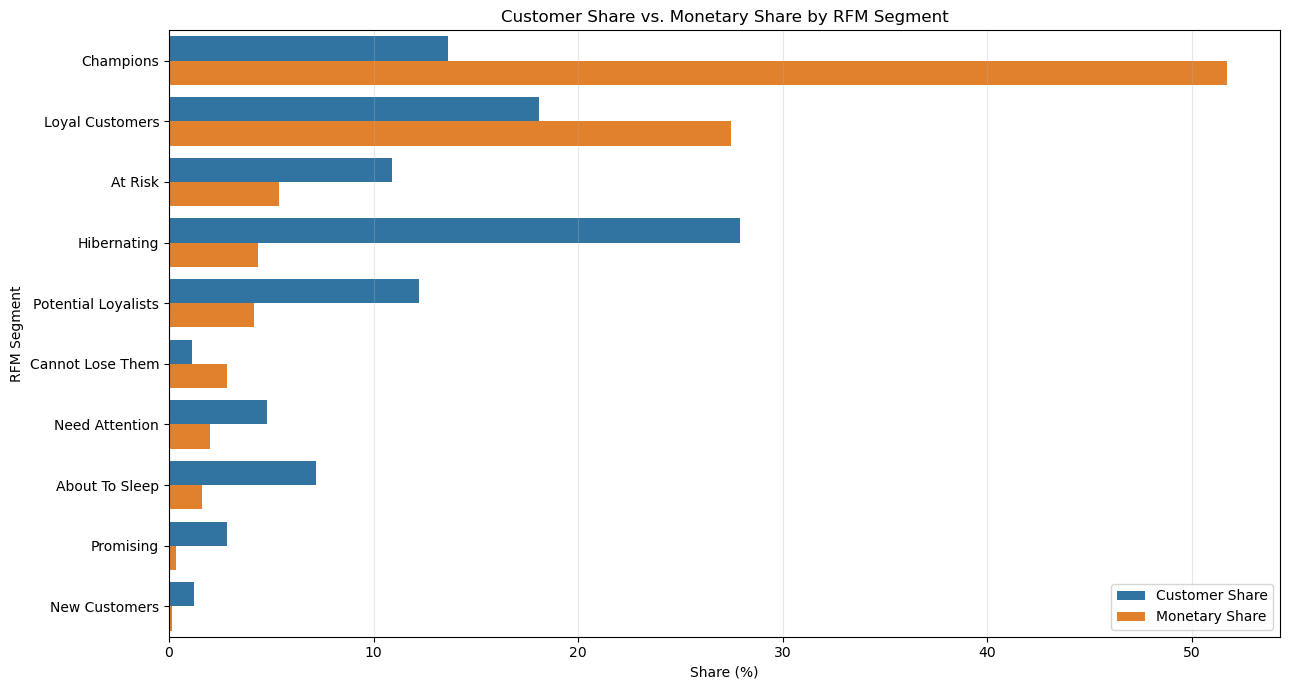

In [225]:
segment_order = (rfm_segment_summary.sort_values("monetary_share_pct",ascending=False)["Segment"].tolist())

plt.figure(figsize=(13, 7))

sns.barplot(
    data=segment_share_plot,
    x="share_pct",
    y="Segment",
    hue="share_type",
    order=segment_order,
    errorbar=None
)

plt.title("Customer Share vs. Monetary Share by RFM Segment")
plt.xlabel("Share (%)")
plt.ylabel("RFM Segment")
plt.grid(axis="x", alpha=0.3)
plt.legend(title ="")
plt.tight_layout()

plt.show()

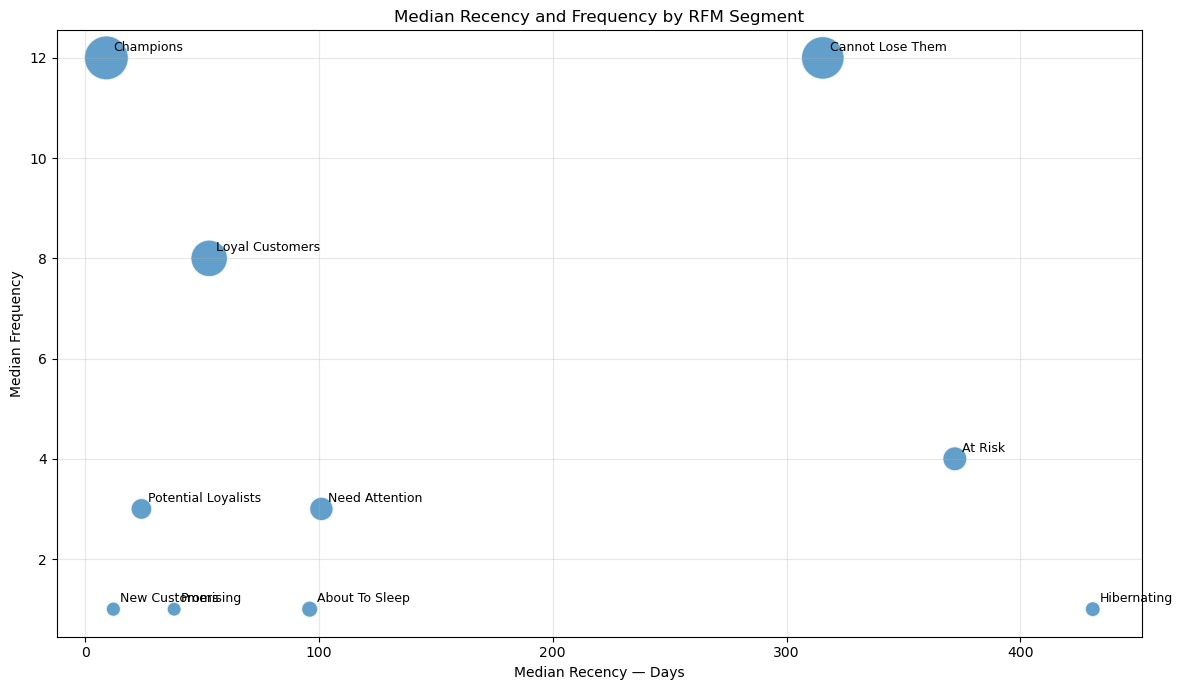

In [226]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=rfm_segment_summary,
    x="median_recency",
    y="median_frequency",
    size="median_monetary",
    sizes=(100, 1000),
    alpha=0.7,
    legend=False
)

for _, row in rfm_segment_summary.iterrows():
    plt.annotate(
        row["Segment"],
        xy=(
            row["median_recency"],
            row["median_frequency"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Median Recency and Frequency by RFM Segment")
plt.xlabel("Median Recency — Days")
plt.ylabel("Median Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [227]:
# Combine cancellation-adjusted customer features
# with RFM scores and business segments
customer_rfm_profile = (customer_model_features.merge(rfm[
            [
                "Customer ID",
                "Recency",
                "Frequency",
                "Monetary",
                "R_score",
                "F_score",
                "M_score",
                "RFM_score",
                "RFM_total_score",
                "Segment"
            ]
        ],
        on="Customer ID",
        how="left",
        validate="one_to_one"
    )
)

## 7. Customer Clustering

RFM segmentation assigns customers to predefined business groups using
rule-based Recency and Frequency scores. Clustering follows a different
approach by identifying naturally occurring customer groups from the numerical
feature structure.

The clustering workflow includes:

1. candidate feature selection,
2. distribution and skewness analysis,
3. correlation analysis,
4. logarithmic transformation,
5. feature scaling,
6. cluster-number evaluation,
7. K-Means modelling,
8. cluster profiling and business interpretation.

Customer identifiers, RFM scores, and existing RFM segment labels are not used
as clustering inputs. Including them would either add no behavioural
information or force the rule-based RFM structure into the unsupervised model.

In [228]:
clustering_feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "average_invoice_value",
    "average_quantity_per_invoice",
    "average_unique_products_per_invoice",
    "unique_products_purchased",
    "customer_lifetime_days"
]

clustering_candidates = (customer_rfm_profile[["Customer ID"] + clustering_feature_columns].copy())

In [229]:
clustering_candidates.head()

,Customer ID,Recency,Frequency,Monetary,average_invoice_value,average_quantity_per_invoice,average_unique_products_per_invoice,unique_products_purchased,customer_lifetime_days
0,12346,530,11,372.86,33.90,6.36,3.00,26,196
1,12347,3,8,"4,921.53",615.19,370.88,27.75,126,402
2,12348,76,5,"1,658.40",331.68,540.80,8.40,24,362
3,12349,19,3,"3,678.69","1,226.23",540.33,57.33,137,570
4,12350,311,1,294.40,294.40,196.00,16.00,16,0


In [230]:
#Buraya total_quantity kolonunu şimdilik eklemedim. Çünkü hem Frequency hem de average_quantity_per_invoice ile güçlü biçimde ilişkili olabilir

In [231]:
clustering_feature_skewness = (clustering_candidates[clustering_feature_columns].skew().sort_values(ascending=False))

clustering_feature_skewness

average_quantity_per_invoice          55.55
Monetary                              26.57
average_invoice_value                 16.60
Frequency                             12.01
unique_products_purchased              6.18
average_unique_products_per_invoice    3.26
Recency                                0.89
customer_lifetime_days                 0.39
dtype: float64

#### Why Spearman Correlation Was Used

Spearman correlation was used because several candidate clustering features
were strongly right-skewed and contained extreme customer values.

Pearson correlation measures linear relationships using the original numerical
values and can be strongly affected by extreme observations. Spearman
correlation instead uses ranked values and measures whether two variables move
together in a monotonic direction.

This makes Spearman correlation more suitable for the initial redundancy
analysis of the current customer features. The objective is to identify
features that provide similar customer-ordering information and may therefore
receive excessive weight in a distance-based clustering model.

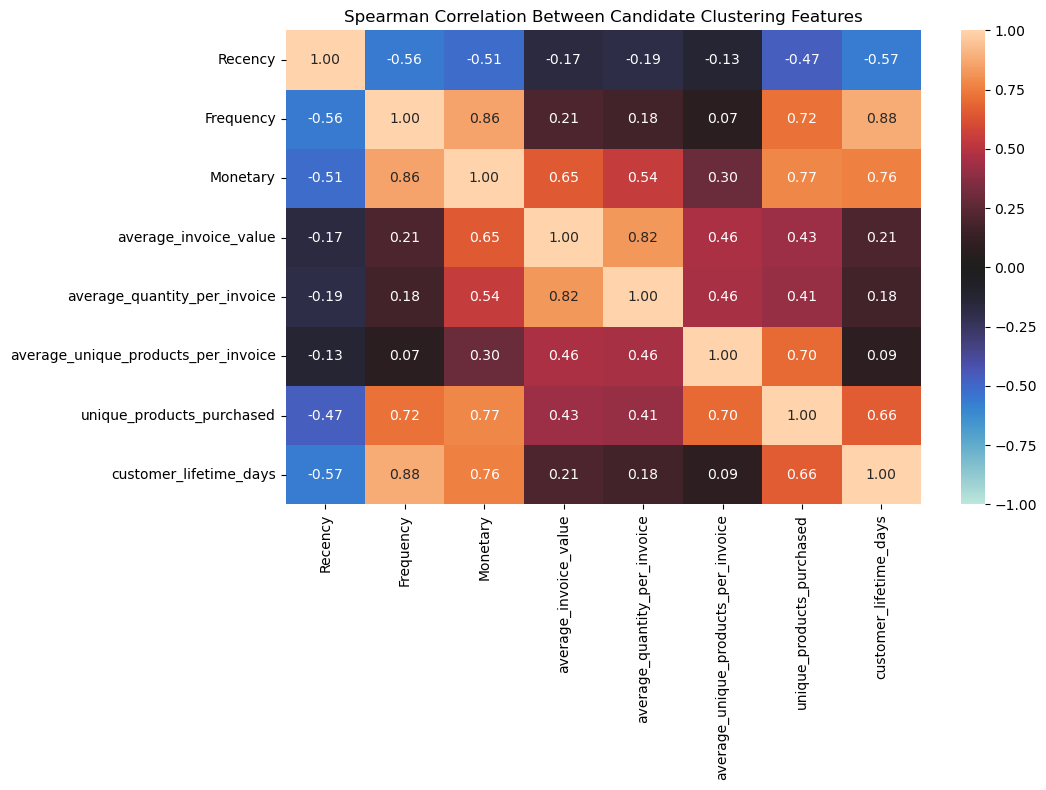

In [232]:
clustering_spearman_corr = (clustering_candidates[clustering_feature_columns].corr(method="spearman"))

plt.figure(figsize=(11, 8))

sns.heatmap(clustering_spearman_corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Spearman Correlation Between Candidate Clustering Features")
plt.tight_layout()

plt.show()

### Final Clustering Feature Selection

Candidate customer features were evaluated according to three criteria:

1. whether the feature represented a distinct and meaningful customer behaviour,
2. whether it repeated information already represented by another feature,
3. whether including it could give a particular behavioural dimension excessive
   influence in the distance-based clustering model.

A Spearman correlation value of approximately `|0.80|` was used as an
investigation threshold rather than an automatic removal rule. Features with
high correlation were evaluated together with their business meanings and
calculation structures.

#### Features Retained for Clustering

| Feature | Reason for Retention |
|---|---|
| `Recency` | Measures how recently the customer made a purchase. It represents customer inactivity and is a fundamental behavioural dimension not replaced by the other features. Lower values indicate more recent activity. |
| `Frequency` | Measures the number of distinct merchandise invoices generated by the customer. It captures repeat-purchase behaviour and customer engagement. Although it was strongly correlated with Monetary and customer lifetime, it has a distinct business interpretation and is a core RFM measure. |
| `Monetary` | Measures the customer's total gross merchandise value within the cancellation-adjusted modelling scope. It represents economic customer value. It was retained together with Frequency because customers with similar invoice counts may still generate substantially different spending levels. |
| `average_quantity_per_invoice` | Measures the average number of product units purchased per invoice. It helps distinguish ordinary purchasing behaviour from high-volume wholesale ordering. Although it was correlated with average invoice value, it provides a more direct measure of physical order volume. |
| `average_unique_products_per_invoice` | Measures the customer's typical basket diversity. Its low correlation with Frequency showed that customers who purchase frequently do not necessarily buy a wide variety of products in each order. It therefore adds a distinct behavioural dimension. |
| `unique_products_purchased` | Measures the number of distinct StockCodes purchased throughout the customer's complete observed history. It represents overall catalogue diversity and can distinguish customers who repeatedly purchase a limited product set from those who explore a broad product range. |

The final clustering input features were therefore defined as:

```python
final_clustering_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "average_quantity_per_invoice",
    "average_unique_products_per_invoice",
    "unique_products_purchased"
]

| Feature                  | Reason for Exclusion                                                                                                                                                                                                                                                                                                                                                              |
| ------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `average_invoice_value`  | This feature is mathematically derived from two retained features: `Monetary / Frequency`. It was also strongly correlated with `average_quantity_per_invoice` (`0.82`). Including it could repeatedly represent order size and give this behaviour excessive influence in the Euclidean distance calculation. It will remain available for cluster profiling and interpretation. |
| `customer_lifetime_days` | This feature had a strong correlation with Frequency (`0.88`). Customers observed for longer periods naturally have more opportunities to generate invoices, so the feature partly reflects the dataset observation window rather than only independent customer behaviour. It was excluded from model fitting but retained for later cluster interpretation.                     |


In [233]:
# Keep Customer ID only for reconnecting cluster labels later.
# Customer ID is not included in the clustering calculations.
final_clustering_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "average_quantity_per_invoice",
    "average_unique_products_per_invoice",
    "unique_products_purchased"
]

clustering_data = (customer_rfm_profile[["Customer ID"] + final_clustering_features].copy())

X_clustering_raw = (clustering_data[final_clustering_features].copy())

In [234]:
# log1p requires values to be greater than or equal to zero
clustering_log_input_checks = pd.Series({
    "no_missing_values": (X_clustering_raw.notna().all().all()),

    "all_values_are_non_negative": (X_clustering_raw.ge(0).all().all())
})

clustering_log_input_checks

no_missing_values              True
all_values_are_non_negative    True
dtype: bool

In [235]:
# Compress the long right tails of customer behaviour features
X_clustering_log = np.log1p(X_clustering_raw)

In [236]:
clustering_skewness_comparison = pd.DataFrame({
    "before_log1p": (X_clustering_raw.skew()),

    "after_log1p": (X_clustering_log.skew())
})

clustering_skewness_comparison[ "absolute_skewness_reduction"] = (
    clustering_skewness_comparison["before_log1p"].abs()  - clustering_skewness_comparison["after_log1p"].abs()
)

clustering_skewness_comparison = (
    clustering_skewness_comparison.sort_values("before_log1p",ascending=False))

clustering_skewness_comparison

,before_log1p,after_log1p,absolute_skewness_reduction
average_quantity_per_invoice,55.55,-0.38,55.18
Monetary,26.57,0.25,26.32
Frequency,12.01,1.01,11.00
unique_products_purchased,6.18,-0.26,5.92
average_unique_products_per_invoice,3.26,-0.44,2.82
Recency,0.89,-0.45,0.45


### Logarithmic Transformation

The selected clustering features contained strongly right-skewed
distributions. Without transformation, a limited number of extremely large
customer values could dominate the Euclidean distance calculations used by
K-Means.

A `log1p` transformation was therefore applied to all selected clustering
features. This transformation calculates `log(1 + x)`, compressing large
values while preserving their ordering and remaining valid for zero-valued
observations.

The transformation does not remove high-value wholesale customers. Instead,
it reduces their disproportionate numerical influence and allows customer
differences across multiple behavioural dimensions to contribute more
balanced information to the clustering model.

In [237]:
import math
def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

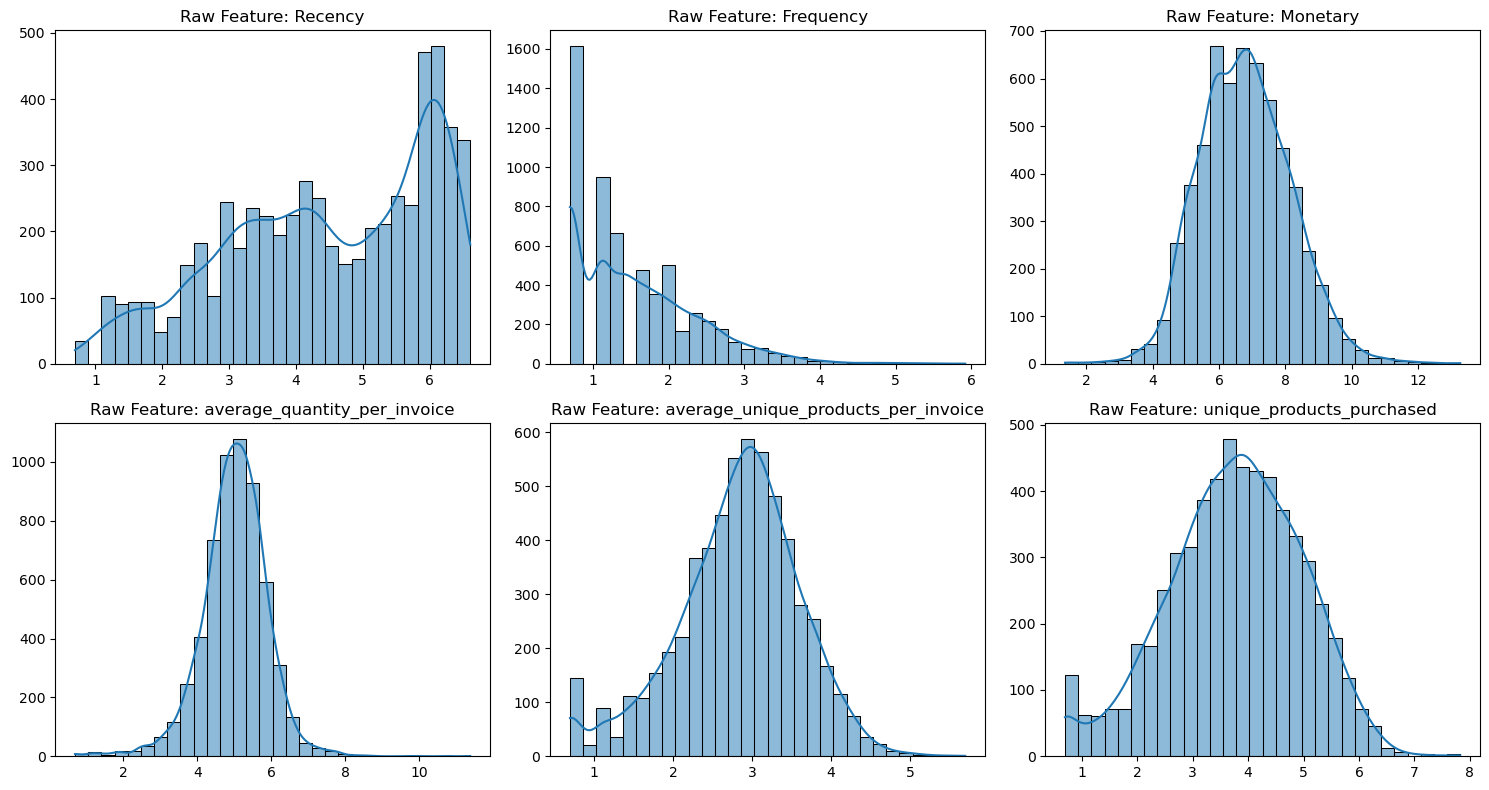

In [238]:
plot_all_histograms(X_clustering_log, title_prefix="Raw Feature: ")

In [239]:
from sklearn.preprocessing import StandardScaler

In [240]:
clustering_scaler = StandardScaler()

In [241]:
X_clustering_scaled_array = clustering_scaler.fit_transform(X_clustering_log)

In [242]:
X_clustering_scaled = pd.DataFrame(X_clustering_scaled_array,columns=final_clustering_features,index=X_clustering_log.index)

In [243]:
scaling_summary = pd.DataFrame({
    "scaled_mean": (X_clustering_scaled.mean()),

    "scaled_std": (X_clustering_scaled.std(ddof=0)),

    "scaled_min": (X_clustering_scaled.min()),

    "scaled_max": (X_clustering_scaled.max())
})

scaling_summary

,scaled_mean,scaled_std,scaled_min,scaled_max
Recency,0.00,1.00,-2.47,1.40
Frequency,0.00,1.00,-1.06,5.43
Monetary,0.00,1.00,-3.95,4.70
average_quantity_per_invoice,-0.00,1.00,-4.86,7.18
average_unique_products_per_invoice,-0.00,1.00,-2.69,3.65
unique_products_purchased,-0.00,1.00,-2.54,3.36


In [244]:
from sklearn.cluster import KMeans
elbow_results = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    model.fit(X_clustering_scaled)

    elbow_results.append({
        "k": k,
        "inertia": model.inertia_
    })

elbow_evaluation = pd.DataFrame(elbow_results)
elbow_evaluation

,k,inertia
0,1,"35,040.00"
1,2,"22,235.30"
2,3,"17,634.43"
3,4,"15,676.17"
4,5,"13,967.58"
5,6,"12,994.18"
6,7,"12,164.01"
7,8,"11,395.57"
8,9,"10,783.98"
9,10,"10,263.05"


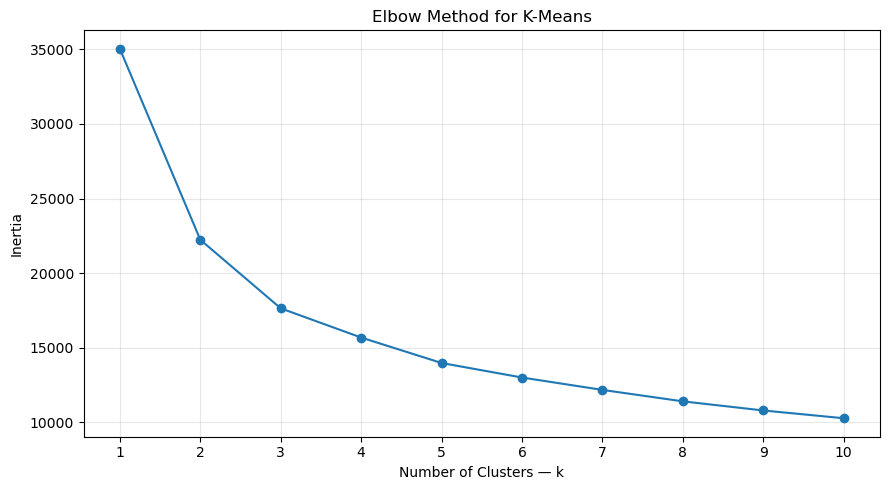

In [245]:
plt.figure(figsize=(9, 5))

plt.plot(elbow_evaluation["k"],elbow_evaluation["inertia"],marker="o")

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters — k")
plt.ylabel("Inertia")
plt.xticks(elbow_evaluation["k"])
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [246]:
from sklearn.metrics import silhouette_score
silhouette_results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )
    cluster_labels = model.fit_predict(X_clustering_scaled)
    silhouette = silhouette_score(X_clustering_scaled, cluster_labels)

    silhouette_results.append({
        "k": k,
        "silhouette_score": silhouette
    })

silhouette_evaluation = pd.DataFrame(silhouette_results)

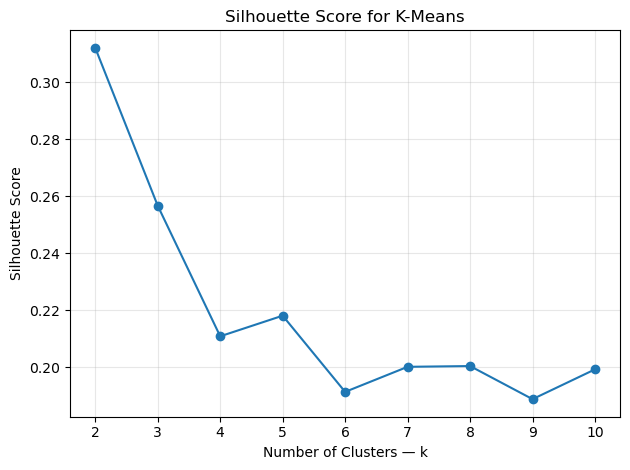

In [247]:
plt.plot(silhouette_evaluation["k"],silhouette_evaluation["silhouette_score"],marker="o")

plt.title("Silhouette Score for K-Means")
plt.xlabel("Number of Clusters — k")
plt.ylabel("Silhouette Score")
plt.xticks(silhouette_evaluation["k"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Selection of Candidate Cluster Counts

The elbow and silhouette analyses did not identify a single cluster count that
was clearly superior according to every evaluation criterion. Therefore, three
candidate solutions were retained for further comparison: `k=2`, `k=3`, and
`k=5`.

#### Two-Cluster Solution

The two-cluster solution produced the highest silhouette score, approximately
`0.31`. This indicates that `k=2` provided the strongest overall separation
and within-cluster consistency among the tested solutions.

However, a two-cluster structure may be too broad for customer segmentation.
It may separate customers mainly into generally active and valuable customers
versus inactive and lower-value customers without capturing more detailed
purchasing patterns.

#### Three-Cluster Solution

The inertia curve showed another meaningful reduction when moving from two to
three clusters. The three-cluster solution also achieved the second-highest
silhouette score, approximately `0.26`.

Therefore, `k=3` was retained as a balanced candidate that may provide more
behavioural detail than `k=2` while maintaining relatively strong cluster
separation.

#### Five-Cluster Solution

The inertia curve continued to decrease until approximately five clusters and
became more gradual afterwards. In addition, the silhouette score at `k=5`
showed a small local improvement compared with `k=4`.

Although its silhouette score was lower than those of `k=2` and `k=3`, the
five-cluster solution was retained to investigate whether a more detailed
structure could reveal distinct customer profiles such as:

- high-value active customers,
- regular customers,
- low-frequency or new customers,
- inactive customers,
- high-volume wholesale customers.

#### Final Evaluation Strategy

The final number of clusters will not be selected only from inertia or
silhouette score. The `k=2`, `k=3`, and `k=5` solutions will also be compared
according to:

- cluster sizes and balance,
- median customer behaviour metrics,
- behavioural distinctiveness,
- business interpretability,
- whether additional clusters represent meaningful and actionable customer
  profiles.

A more complex solution will be preferred only when its additional clusters
provide useful behavioural information rather than dividing similar customers
into unnecessarily small groups.

In [248]:
candidate_k_values = [2, 3, 5]

In [249]:
candidate_cluster_models = {}
candidate_cluster_labels = {}

for k in candidate_k_values:

    kmeans_model = KMeans(n_clusters=k,init="k-means++",n_init=20,random_state=42)

    cluster_labels = kmeans_model.fit_predict(X_clustering_scaled)

    candidate_cluster_models[k] = kmeans_model
    candidate_cluster_labels[k] = cluster_labels

In [250]:
cluster_profile_base = (customer_rfm_profile.loc[X_clustering_scaled.index].copy())

In [251]:
for k in candidate_k_values:

    cluster_profile_base[f"Cluster_k{k}"] = candidate_cluster_labels[k]

In [252]:
cluster_label_checks = {
    "customer_order_matches": (cluster_profile_base.index.equals(X_clustering_scaled.index)),

    "customer_count_matches": (len(cluster_profile_base)== len(X_clustering_scaled)),

    "customer_id_is_unique": (cluster_profile_base["Customer ID"].is_unique)
}

In [253]:
for k in candidate_k_values:

    cluster_column = f"Cluster_k{k}"

    cluster_label_checks[f"k{k}_has_no_missing_labels"] = (cluster_profile_base[cluster_column].notna().all())

    cluster_label_checks[f"k{k}_has_expected_cluster_count"] = (cluster_profile_base[cluster_column].nunique()== k)

In [254]:
cluster_label_checks = pd.Series(cluster_label_checks)

cluster_label_checks

customer_order_matches           True
customer_count_matches           True
customer_id_is_unique            True
k2_has_no_missing_labels         True
k2_has_expected_cluster_count    True
k3_has_no_missing_labels         True
k3_has_expected_cluster_count    True
k5_has_no_missing_labels         True
k5_has_expected_cluster_count    True
dtype: bool

In [255]:
cluster_size_results = []

for k in candidate_k_values:

    cluster_column = f"Cluster_k{k}"

    cluster_counts = (cluster_profile_base[cluster_column].value_counts().sort_index())

    for cluster_number, customer_count in cluster_counts.items():

        cluster_size_results.append({
            "k": k,
            "Cluster": cluster_number,
            "customer_count": customer_count,
            "customer_share_pct": (customer_count/ len(cluster_profile_base)* 100)
        })

cluster_size_comparison = pd.DataFrame(cluster_size_results)

cluster_size_comparison

,k,Cluster,customer_count,customer_share_pct
0,2,0,2735,46.83
1,2,1,3105,53.17
2,3,0,2567,43.96
3,3,1,1894,32.43
4,3,2,1379,23.61
5,5,0,1148,19.66
6,5,1,755,12.93
7,5,2,1503,25.74
8,5,3,1222,20.92
9,5,4,1212,20.75


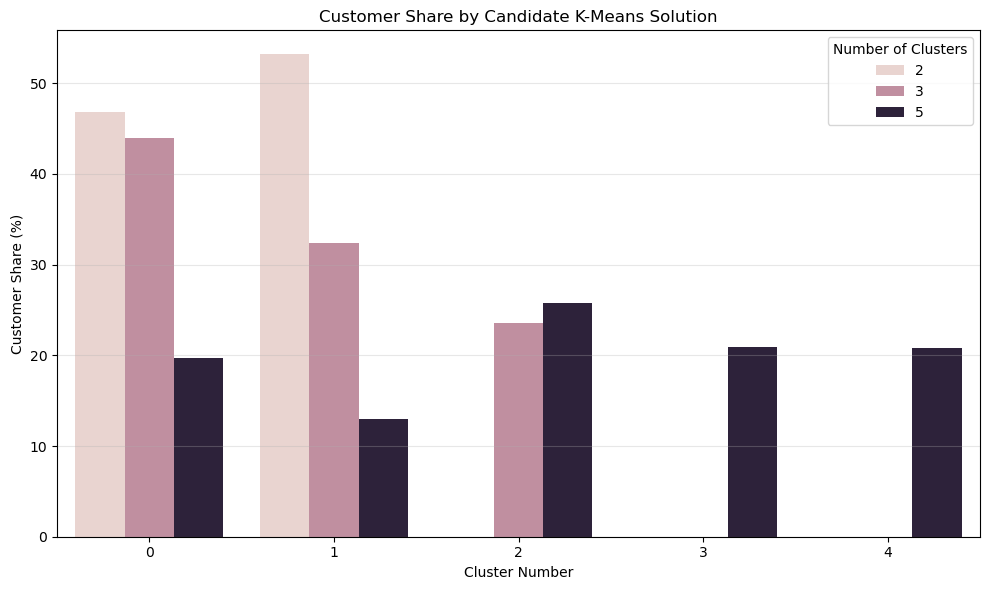

In [256]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cluster_size_comparison,
    x="Cluster",
    y="customer_share_pct",
    hue="k"
)

plt.title("Customer Share by Candidate K-Means Solution")
plt.xlabel("Cluster Number")
plt.ylabel("Customer Share (%)")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Number of Clusters")
plt.tight_layout()

plt.show()

In [257]:
cluster_profile_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "average_invoice_value",
    "average_quantity_per_invoice",
    "average_unique_products_per_invoice",
    "unique_products_purchased",
    "customer_lifetime_days"
]

In [258]:
# final_clustering_features + average_invoice_value + customer_lifetime_days

In [259]:
candidate_cluster_profiles = {}

for k in candidate_k_values:

    cluster_column = f"Cluster_k{k}"

    cluster_profile = (cluster_profile_base.groupby(cluster_column)[cluster_profile_features].median())

    cluster_customer_counts = (cluster_profile_base.groupby(cluster_column).size())

    cluster_profile.insert(0,"customer_count",cluster_customer_counts)

    cluster_profile.insert(1,"customer_share_pct",(cluster_customer_counts / len(cluster_profile_base) * 100))

    candidate_cluster_profiles[k] = (cluster_profile.reset_index())

In [260]:
k2_cluster_profile = candidate_cluster_profiles[2]
k3_cluster_profile = candidate_cluster_profiles[3]
k5_cluster_profile = candidate_cluster_profiles[5]

In [261]:
k2_cluster_profile

,Cluster_k2,customer_count,customer_share_pct,Recency,Frequency,Monetary,average_invoice_value,average_quantity_per_invoice,average_unique_products_per_invoice,unique_products_purchased,customer_lifetime_days
0,0,2735,46.83,32.00,7.00,"2,318.10",352.45,214.11,22.40,109.00,494.00
1,1,3105,53.17,295.00,2.00,358.15,206.03,110.50,12.50,20.00,0.00


In [262]:
k3_cluster_profile

,Cluster_k3,customer_count,customer_share_pct,Recency,Frequency,Monetary,average_invoice_value,average_quantity_per_invoice,average_unique_products_per_invoice,unique_products_purchased,customer_lifetime_days
0,0,2567,43.96,214.00,2.00,668.04,302.82,177.00,21.00,41.00,103.00
1,1,1894,32.43,23.00,9.00,"3,346.97",346.83,205.63,20.50,136.50,583.00
2,2,1379,23.61,298.00,1.00,211.32,138.53,68.67,6.00,9.00,0.00


In [263]:
k5_cluster_profile

,Cluster_k5,customer_count,customer_share_pct,Recency,Frequency,Monetary,average_invoice_value,average_quantity_per_invoice,average_unique_products_per_invoice,unique_products_purchased,customer_lifetime_days
0,0,1148,19.66,17.00,13.00,"4,891.74",369.87,219.28,21.25,178.00,632.50
1,1,755,12.93,331.00,1.00,152.35,110.05,49.00,4.00,6.00,0.00
2,2,1503,25.74,390.00,1.00,328.80,236.06,135.50,17.00,23.00,0.00
3,3,1222,20.92,40.00,5.00,"1,068.72",229.84,123.71,12.00,43.00,391.00
4,4,1212,20.75,108.50,3.00,"1,233.00",429.07,275.50,32.50,83.00,252.00


In [264]:
from sklearn.metrics import silhouette_samples

cluster_silhouette_results = []

for k in candidate_k_values:

    cluster_labels = candidate_cluster_labels[k]

    customer_silhouette_scores = silhouette_samples(X_clustering_scaled,cluster_labels)

    silhouette_customer_table = pd.DataFrame({
        "Cluster": cluster_labels,
        "silhouette_score": customer_silhouette_scores
    })

    cluster_silhouette_summary_current = (silhouette_customer_table.groupby("Cluster", as_index=False).agg(
            customer_count=(
                "silhouette_score",
                "size"
            ),
            average_silhouette=(
                "silhouette_score",
                "mean"
            ),
            median_silhouette=(
                "silhouette_score",
                "median"
            ),
            minimum_silhouette=(
                "silhouette_score",
                "min"
            ),
            negative_customer_share_pct=(
                "silhouette_score",
                lambda values: (values.lt(0).mean() * 100)
            )
        )
    )

    cluster_silhouette_summary_current.insert(0,"k",k)

    cluster_silhouette_results.append(cluster_silhouette_summary_current)

cluster_silhouette_summary = pd.concat(cluster_silhouette_results,ignore_index=True)

cluster_silhouette_summary

,k,Cluster,customer_count,average_silhouette,median_silhouette,minimum_silhouette,negative_customer_share_pct
0,2,0,2735,0.30,0.33,-0.02,1.54
1,2,1,3105,0.32,0.35,-0.01,0.16
2,3,0,2567,0.27,0.27,0.02,0.00
3,3,1,1894,0.26,0.29,-0.06,5.70
4,3,2,1379,0.23,0.25,-0.06,8.63
5,5,0,1148,0.24,0.25,-0.03,4.09
6,5,1,755,0.20,0.22,-0.13,15.36
7,5,2,1503,0.30,0.30,0.03,0.00
8,5,3,1222,0.16,0.15,-0.08,8.76
9,5,4,1212,0.17,0.17,-0.08,7.59


In [265]:
from sklearn.metrics import davies_bouldin_score,calinski_harabasz_score

candidate_model_evaluation_results = []

for k in candidate_k_values:

    cluster_labels = candidate_cluster_labels[k]
    kmeans_model = candidate_cluster_models[k]

    candidate_model_evaluation_results.append({
        "k": k,
        "inertia": kmeans_model.inertia_,

        "silhouette_score": silhouette_score(X_clustering_scaled,cluster_labels),

        "davies_bouldin_score": davies_bouldin_score(X_clustering_scaled,cluster_labels),

        "calinski_harabasz_score": calinski_harabasz_score( X_clustering_scaled,cluster_labels)
    })

candidate_model_evaluation = pd.DataFrame(candidate_model_evaluation_results)

candidate_model_evaluation

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,"22,235.30",0.31,1.20,"3,361.96"
1,3,"17,634.43",0.26,1.26,"2,880.63"
2,5,"13,967.58",0.22,1.34,"2,200.79"


In [266]:
from sklearn.metrics import adjusted_rand_score

# Reference k=3 solution fitted on the complete dataset
reference_k3_model = KMeans(n_clusters=3,init="k-means++",n_init=20,random_state=42)

reference_k3_labels = reference_k3_model.fit_predict(X_clustering_scaled)

rng = np.random.default_rng(42)

stability_results = []

for run in range(20):

    sample_indices = rng.choice(X_clustering_scaled.index,size=int(len(X_clustering_scaled) * 0.80),replace=False)

    sample_model = KMeans(n_clusters=3,init="k-means++",n_init=20,random_state=run)

    sample_model.fit(X_clustering_scaled.loc[sample_indices])

    full_data_labels = sample_model.predict(X_clustering_scaled)

    stability_results.append({
        "run": run + 1,
        "adjusted_rand_index": adjusted_rand_score(reference_k3_labels,full_data_labels)
    })

k3_stability_evaluation = pd.DataFrame(stability_results)

k3_stability_evaluation

,run,adjusted_rand_index
0,1,0.95
1,2,0.98
2,3,0.95
3,4,0.99
4,5,0.95
5,6,0.99
6,7,0.99
7,8,0.95
8,9,0.93
9,10,0.93


In [267]:
k3_stability_summary = (k3_stability_evaluation["adjusted_rand_index"].describe())

k3_stability_summary

count   20.00
mean     0.97
std      0.02
min      0.93
25%      0.95
50%      0.97
75%      0.99
max      1.00
Name: adjusted_rand_index, dtype: float64

In [268]:
from sklearn.cluster import AgglomerativeClustering


agglomerative_k3_model = AgglomerativeClustering(n_clusters=3,linkage="ward")

agglomerative_k3_labels = (agglomerative_k3_model.fit_predict(X_clustering_scaled))

algorithm_comparison = pd.DataFrame([
    {
        "model": "K-Means",
        "silhouette_score": silhouette_score(X_clustering_scaled,reference_k3_labels),
        "davies_bouldin_score": davies_bouldin_score(X_clustering_scaled,reference_k3_labels),
        "calinski_harabasz_score": calinski_harabasz_score( X_clustering_scaled, reference_k3_labels)
    },
    {
        "model": "Agglomerative Ward",
        "silhouette_score": silhouette_score( X_clustering_scaled, agglomerative_k3_labels),
        "davies_bouldin_score": davies_bouldin_score( X_clustering_scaled, agglomerative_k3_labels),
        "calinski_harabasz_score": calinski_harabasz_score( X_clustering_scaled, agglomerative_k3_labels)
    }
])

algorithm_comparison

,model,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,K-Means,0.26,1.26,"2,880.63"
1,Agglomerative Ward,0.22,1.33,"2,338.27"


### Final Clustering Model Selection

The three-cluster K-Means solution was selected as the final customer
clustering model.

The two-cluster solution achieved the highest silhouette score but produced
customer groups that were too broad for detailed business interpretation. The
five-cluster solution generated more detailed profiles, but several clusters
had relatively low silhouette values and higher proportions of customers with
negative silhouette scores.

The three-cluster solution provided the strongest balance between mathematical
separation, behavioural detail, cluster size, and business interpretability.

The stability of the three-cluster K-Means solution was evaluated by repeatedly
fitting the model on random 80% customer samples and comparing the resulting
full-data assignments with the reference solution. Across 20 runs, the
Adjusted Rand Index ranged from `0.93` to `1.00`, with an average of
approximately `0.97`. This indicated that the cluster structure was highly
stable under changes in the customer sample.

K-Means was also compared with Agglomerative Clustering using Ward linkage.
K-Means produced:

- a higher silhouette score (`0.26` versus `0.22`),
- a lower Davies–Bouldin score (`1.26` versus `1.33`),
- a higher Calinski–Harabasz score (`2,880.63` versus `2,338.27`).

Based on these results, K-Means provided the better-supported and more
operationally practical solution. Unlike Agglomerative Clustering, the fitted
K-Means model can also assign future customers to existing clusters using its
learned centroids.

In [269]:
final_k = 3

final_kmeans_model = (candidate_cluster_models[final_k])

final_cluster_labels = (candidate_cluster_labels[final_k])

In [270]:
final_customer_clusters = (customer_rfm_profile.loc[X_clustering_scaled.index].copy())

final_customer_clusters["Cluster"] = (final_cluster_labels)

In [271]:
cluster_name_map = {
    0: "Lapsing Occasional Customers",
    1: "Active High-Value Customers",
    2: "Inactive One-Time Customers"
}

final_customer_clusters["Cluster_Name"] = (final_customer_clusters["Cluster"].map(cluster_name_map))

In [272]:
final_cluster_checks = pd.Series({
    "customer_count_is_preserved": (len(final_customer_clusters)== len(X_clustering_scaled)),

    "customer_id_is_unique": (final_customer_clusters["Customer ID"].is_unique),

    "no_missing_cluster_labels": (final_customer_clusters["Cluster"].notna().all()),

    "three_clusters_are_present": (final_customer_clusters["Cluster"].nunique()== final_k),

    "no_missing_cluster_names": (final_customer_clusters["Cluster_Name"].notna().all())
})

final_cluster_checks

customer_count_is_preserved    True
customer_id_is_unique          True
no_missing_cluster_labels      True
three_clusters_are_present     True
no_missing_cluster_names       True
dtype: bool

### Final Cluster Profiling

The selected three-cluster K-Means solution was profiled using customer
behaviour metrics in their original numerical scale.

Median values were used to describe the typical customer within each cluster
because the dataset contained highly active and high-volume wholesale
customers whose extreme values could substantially affect arithmetic means.

Total Monetary value and percentage shares were also calculated to evaluate
the overall business contribution of each cluster. Therefore, the profile
tables distinguish between:

- the behaviour of a typical customer, represented by median values,
- the total commercial contribution of the cluster, represented by aggregate
  Monetary value and percentage shares.

In [273]:
final_cluster_summary = (final_customer_clusters.groupby(["Cluster","Cluster_Name"],as_index=False).agg(
        customer_count=(
            "Customer ID",
            "size"
        ),

        median_recency=(
            "Recency",
            "median"
        ),

        median_frequency=(
            "Frequency",
            "median"
        ),

        total_monetary=(
            "Monetary",
            "sum"
        ),

        median_monetary=(
            "Monetary",
            "median"
        ),

        median_average_invoice_value=(
            "average_invoice_value",
            "median"
        ),

        median_average_quantity_per_invoice=(
            "average_quantity_per_invoice",
            "median"
        ),

        median_average_unique_products_per_invoice=(
            "average_unique_products_per_invoice",
            "median"
        ),

        median_unique_products_purchased=(
            "unique_products_purchased",
            "median"
        ),

        median_customer_lifetime_days=(
            "customer_lifetime_days",
            "median"
        )
    )
)

In [274]:
final_cluster_summary["customer_share_pct"] = (final_cluster_summary["customer_count"]/ final_cluster_summary["customer_count"].sum()* 100)

final_cluster_summary["monetary_share_pct"] = (final_cluster_summary["total_monetary"] / final_cluster_summary["total_monetary"].sum() * 100)

In [275]:
final_cluster_summary = (final_cluster_summary.sort_values( "total_monetary", ascending=False) .reset_index(drop=True))

final_cluster_summary

,Cluster,Cluster_Name,customer_count,median_recency,median_frequency,total_monetary,median_monetary,median_average_invoice_value,median_average_quantity_per_invoice,median_average_unique_products_per_invoice,median_unique_products_purchased,median_customer_lifetime_days,customer_share_pct,monetary_share_pct
0,1,Active High-Value Customers,1894,23.00,9.00,"13,776,166.98","3,346.97",346.83,205.63,20.50,136.50,583.00,32.43,83.31
1,0,Lapsing Occasional Customers,2567,214.00,2.00,"2,219,636.61",668.04,302.82,177.00,21.00,41.00,103.00,43.96,13.42
2,2,Inactive One-Time Customers,1379,298.00,1.00,"540,046.31",211.32,138.53,68.67,6.00,9.00,0.00,23.61,3.27


In [276]:
final_cluster_share_plot = (
    final_cluster_summary[["Cluster_Name","customer_share_pct", "monetary_share_pct"]].melt(
        id_vars="Cluster_Name",
        value_vars=["customer_share_pct","monetary_share_pct"],
        var_name="share_type",
        value_name="share_pct"
    )
)

final_cluster_share_plot["share_type"] = ( final_cluster_share_plot["share_type"].replace(
    {"customer_share_pct": "Customer Share",
     "monetary_share_pct": "Monetary Share"
    })
)

In [277]:
final_cluster_order = (final_cluster_summary[ "Cluster_Name" ] .tolist())

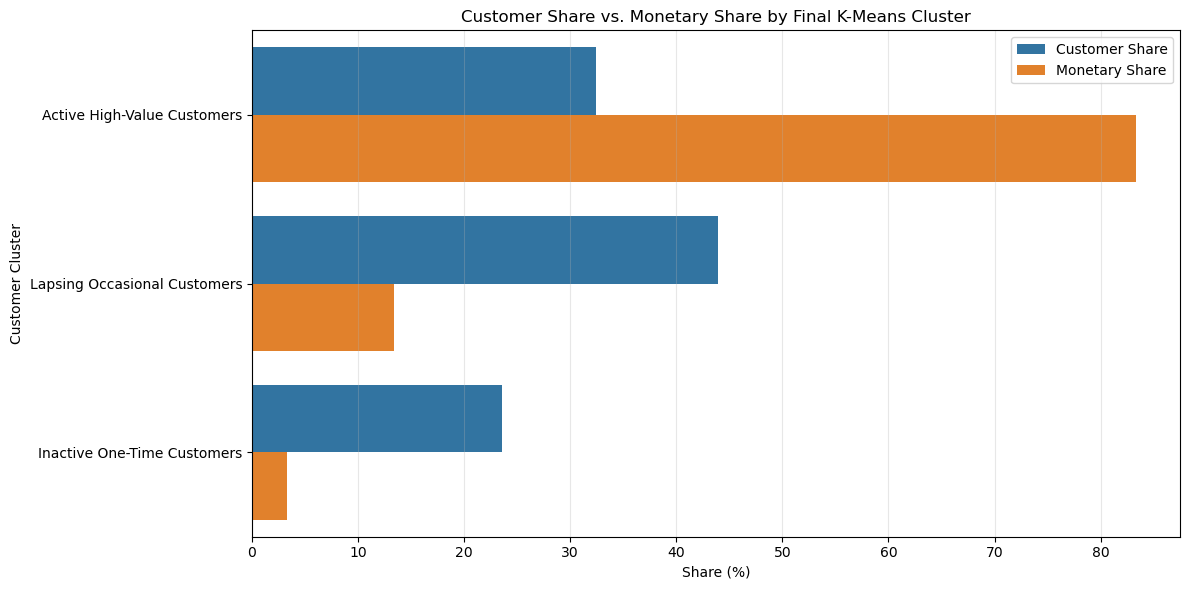

In [278]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_cluster_share_plot,
    x="share_pct",
    y="Cluster_Name",
    hue="share_type",
    order=final_cluster_order,
    errorbar=None
)

plt.title(
    "Customer Share vs. Monetary Share by Final K-Means Cluster"
)

plt.xlabel("Share (%)")
plt.ylabel("Customer Cluster")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.legend(title="")
plt.tight_layout()

plt.show()

In [279]:
final_clustering_features

['Recency',
 'Frequency',
 'Monetary',
 'average_quantity_per_invoice',
 'average_unique_products_per_invoice',
 'unique_products_purchased']

In [280]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_clustering_pca_array = (pca.fit_transform(X_clustering_scaled))

In [281]:
pca_cluster_plot = pd.DataFrame(X_clustering_pca_array,columns=["PC1","PC2"],index=X_clustering_scaled.index)

In [282]:
pca_cluster_plot["Cluster"] = (final_customer_clusters["Cluster"])

pca_cluster_plot["Cluster_Name"] = (final_customer_clusters["Cluster_Name"])

In [283]:
pca_plot_checks = pd.Series({
    "row_count_is_preserved": (len(pca_cluster_plot)== len(X_clustering_scaled)),

    "index_is_preserved": (pca_cluster_plot.index.equals( X_clustering_scaled.index)),

    "no_missing_cluster_names": (pca_cluster_plot["Cluster_Name"].notna().all()),

    "two_components_are_present": (pca.n_components_== 2)
})

pca_plot_checks

row_count_is_preserved        True
index_is_preserved            True
no_missing_cluster_names      True
two_components_are_present    True
dtype: bool

In [284]:
pca_explained_variance = pd.Series(pca.explained_variance_ratio_,index=["PC1","PC2"],name="explained_variance_ratio")

pca_explained_variance

PC1   0.57
PC2   0.21
Name: explained_variance_ratio, dtype: float64

In [285]:
pca_total_explained_variance = (pca.explained_variance_ratio_.sum())

pca_total_explained_variance

np.float64(0.7823623992794074)

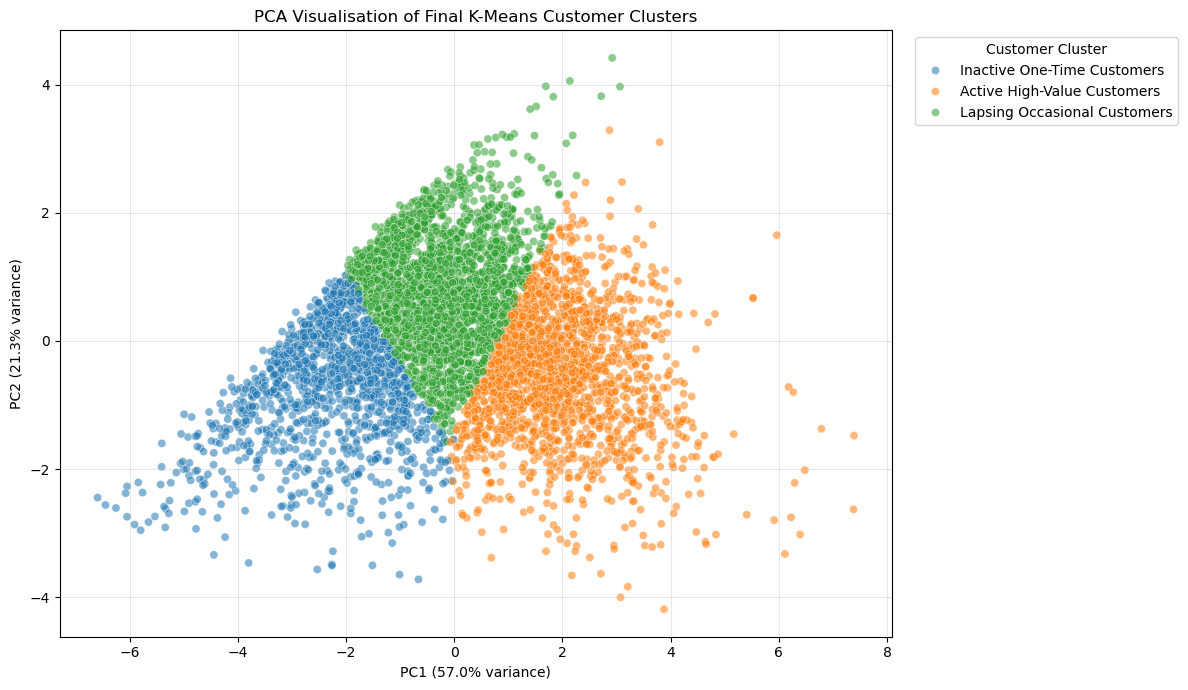

In [286]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pca_cluster_plot,
    x="PC1",
    y="PC2",
    hue="Cluster_Name",
    alpha=0.55,
    s=35
)

plt.title(
    "PCA Visualisation of Final K-Means Customer Clusters"
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.grid(alpha=0.3)
plt.legend(
    title="Customer Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### PCA Visualisation Results

The first two principal components explained approximately `78.24%` of the
total variance in the six-dimensional clustering feature space. PC1 explained
approximately `57.0%`, while PC2 explained approximately `21.3%`.

This level of explained variance indicates that the two-dimensional PCA
projection preserves a substantial proportion of the original customer
information and is therefore suitable for visual interpretation.

The final clusters occupied distinguishable regions of the PCA space:

- `Inactive One-Time Customers` were concentrated mainly on the left side,
- `Active High-Value Customers` were concentrated mainly on the right side,
- `Lapsing Occasional Customers` occupied a more intermediate region.

Some overlap was visible near the cluster boundaries. This was consistent
with the moderate silhouette score and reflects the continuous nature of real
customer behaviour rather than a technical error.

The PCA plot was used only as an approximate visual representation. The final
K-Means model was fitted on all six transformed and standardised features, not
on the two PCA components.

In [287]:
pca_loadings = pd.DataFrame(pca.components_.T,index=X_clustering_scaled.columns,columns=["PC1_loading","PC2_loading"]
)

pca_loadings

,PC1_loading,PC2_loading
Recency,-0.34,0.40
Frequency,0.43,-0.46
Monetary,0.50,-0.16
average_quantity_per_invoice,0.33,0.41
average_unique_products_per_invoice,0.32,0.63
unique_products_purchased,0.50,0.15


In [288]:
final_customer_clusters.columns

Index(['Customer ID', 'first_purchase_date', 'last_purchase_date',
       'invoice_count', 'total_spending', 'total_quantity',
       'average_invoice_value', 'median_invoice_value',
       'average_quantity_per_invoice', 'average_unique_products_per_invoice',
       'unique_products_purchased', 'customer_lifetime_days', 'Recency',
       'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_score',
       'RFM_total_score', 'Segment', 'Cluster', 'Cluster_Name'],
      dtype='object')

In [289]:
rfm_cluster_count_table = pd.crosstab(
    index=final_customer_clusters["Cluster_Name"],
    columns=final_customer_clusters["Segment"]
)

rfm_cluster_count_table

Segment,About To Sleep,At Risk,Cannot Lose Them,Champions,Hibernating,Loyal Customers,Need Attention,New Customers,Potential Loyalists,Promising
Cluster_Name,,,,,,,,,,
Active High-Value Customers,1,38,57,778,0,843,17,0,160,0
Inactive One-Time Customers,146,137,3,16,734,60,57,28,134,64
Lapsing Occasional Customers,273,463,6,2,897,152,207,43,421,103


In [290]:
rfm_cluster_pct_table = (pd.crosstab(index=final_customer_clusters["Cluster_Name"],columns=final_customer_clusters["Segment"],normalize="index")* 100
)

rfm_cluster_pct_table

Segment,About To Sleep,At Risk,Cannot Lose Them,Champions,Hibernating,Loyal Customers,Need Attention,New Customers,Potential Loyalists,Promising
Cluster_Name,,,,,,,,,,
Active High-Value Customers,0.05,2.01,3.01,41.08,0.00,44.51,0.90,0.00,8.45,0.00
Inactive One-Time Customers,10.59,9.93,0.22,1.16,53.23,4.35,4.13,2.03,9.72,4.64
Lapsing Occasional Customers,10.63,18.04,0.23,0.08,34.94,5.92,8.06,1.68,16.40,4.01


In [291]:
rfm_segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "New Customers",
    "Promising",
    "Need Attention",
    "About To Sleep",
    "At Risk",
    "Cannot Lose Them",
    "Hibernating"
]

rfm_cluster_pct_table = (rfm_cluster_pct_table.reindex(columns=rfm_segment_order,fill_value=0))

rfm_cluster_pct_table

Segment,Champions,Loyal Customers,Potential Loyalists,New Customers,Promising,Need Attention,About To Sleep,At Risk,Cannot Lose Them,Hibernating
Cluster_Name,,,,,,,,,,
Active High-Value Customers,41.08,44.51,8.45,0.00,0.00,0.90,0.05,2.01,3.01,0.00
Inactive One-Time Customers,1.16,4.35,9.72,2.03,4.64,4.13,10.59,9.93,0.22,53.23
Lapsing Occasional Customers,0.08,5.92,16.40,1.68,4.01,8.06,10.63,18.04,0.23,34.94


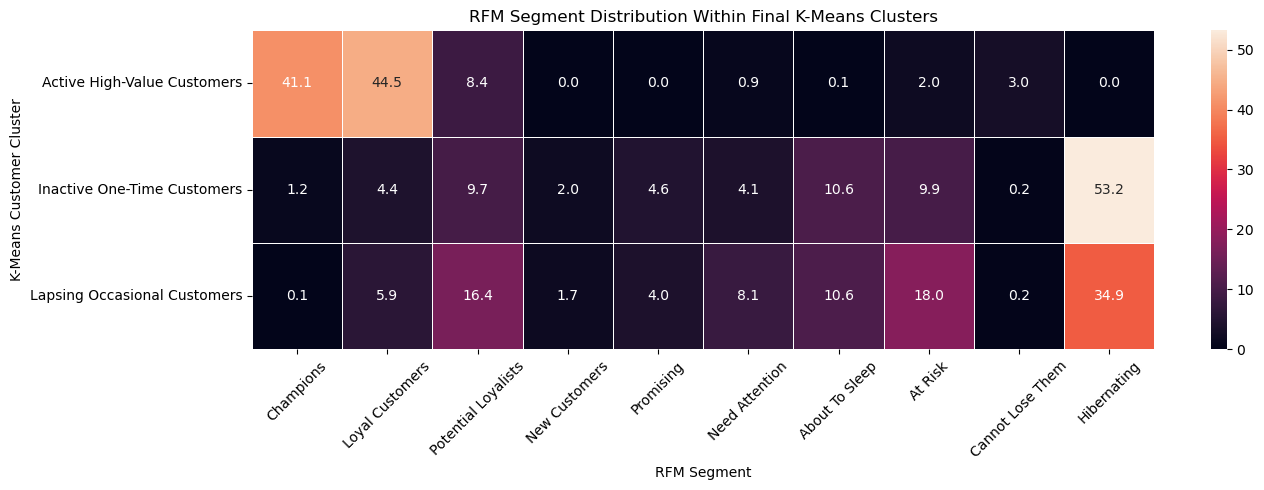

In [292]:
plt.figure(figsize=(14, 5))

sns.heatmap(rfm_cluster_pct_table,annot=True,fmt=".1f",linewidths=0.5)

plt.title("RFM Segment Distribution Within Final K-Means Clusters")

plt.xlabel("RFM Segment")
plt.ylabel("K-Means Customer Cluster")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Final Customer-Cluster Conclusions

The final three-cluster K-Means model identified three commercially distinct
customer profiles.

| Customer Cluster | Main Characteristics | Recommended Business Action |
|---|---|---|
| `Active High-Value Customers` | Recent, frequent, high-value customers with broad product engagement. The cluster was composed primarily of Champions and Loyal Customers and generated the majority of total customer Monetary value. | Protect and strengthen these relationships through loyalty rewards, personalised recommendations, premium service, cross-selling, and early access to relevant products. |
| `Lapsing Occasional Customers` | Customers with previous purchasing activity and moderate historical value whose recent engagement had declined. This cluster contained meaningful shares of At Risk, Hibernating, Potential Loyalist, About To Sleep, and Need Attention customers. | Prioritise selective reactivation campaigns based on previous products, targeted reminders, personalised offers, and limited-time incentives. |
| `Inactive One-Time Customers` | Mostly low-value customers who purchased once and had been inactive for a long period. Hibernating customers represented the largest RFM group within this cluster. | Use low-cost and selective second-purchase or reactivation campaigns. Expensive broad campaigns may be inefficient because of the cluster's limited historical value. |

The RFM and K-Means results were strongly consistent but not identical. RFM
primarily represented customer lifecycle status through rule-based Recency and
Frequency scores. K-Means additionally incorporated Monetary value, order
quantity, basket diversity, and overall product diversity.

Consequently, clustering provided additional behavioural detail within broad
RFM segments. The final model was therefore interpreted as a complementary
customer profiling system rather than a replacement for RFM segmentation.

## 8. Cohort Retention Analysis
Cohort analysis groups customers according to the month of their first
observed merchandise purchase and follows their purchasing activity over
subsequent months.

Unlike RFM and clustering, which summarise customer behaviour at a particular
analysis date, cohort analysis focuses on how customer engagement develops
over time.

The analysis aims to answer:

- how many customers were acquired in each month,
- what proportion returned in the following months,
- whether newer customer cohorts retained better or worse than earlier
  cohorts.

The cancellation-adjusted customer invoice dataset is used so that each
customer–invoice combination represents one retained merchandise purchase.

In [293]:
cohort_data = (customer_model_invoice_sales[["Customer ID","Invoice","invoice_date"]].copy())

In [294]:
cohort_data.head()

,Customer ID,Invoice,invoice_date
0,12346,491725,2009-12-14 08:34:00
1,12346,491742,2009-12-14 11:00:00
2,12346,491744,2009-12-14 11:02:00
3,12346,492718,2009-12-18 10:47:00
4,12346,492722,2009-12-18 10:55:00


In [295]:
cohort_data["invoice_month"] = (cohort_data["invoice_date"].dt.to_period("M"))

In [296]:
cohort_data.head()

,Customer ID,Invoice,invoice_date,invoice_month
0,12346,491725,2009-12-14 08:34:00,2009-12
1,12346,491742,2009-12-14 11:00:00,2009-12
2,12346,491744,2009-12-14 11:02:00,2009-12
3,12346,492718,2009-12-18 10:47:00,2009-12
4,12346,492722,2009-12-18 10:55:00,2009-12


In [297]:
cohort_data["cohort_month"] = (cohort_data.groupby("Customer ID")["invoice_month"].transform("min"))

In [298]:
cohort_initial_checks = pd.Series({
    "one_row_per_customer_invoice": (~cohort_data.duplicated(subset=["Customer ID","Invoice"]).any()),

    "no_missing_invoice_month": (cohort_data["invoice_month"].notna().all()),

    "no_missing_cohort_month": (cohort_data["cohort_month"].notna().all()),

    "cohort_is_not_after_invoice": (cohort_data["cohort_month"].le(cohort_data["invoice_month"]).all())
})

cohort_initial_checks

one_row_per_customer_invoice    True
no_missing_invoice_month        True
no_missing_cohort_month         True
cohort_is_not_after_invoice     True
dtype: bool

### Cohort Period Index

A cohort index was calculated to measure the number of months between each
customer's first observed purchase month and the month of each subsequent
purchase.

The acquisition month was assigned `Cohort Index = 1`. Therefore:

- `1` represents the customer's first purchase month,
- `2` represents the following month,
- `3` represents two months after acquisition.

This relative time index allows cohorts acquired in different calendar months
to be compared on the same customer-lifecycle timeline.

In [299]:
cohort_data["cohort_index"] = ((cohort_data["invoice_month"].dt.year- cohort_data["cohort_month"].dt.year)* 12
                        +(cohort_data["invoice_month"].dt.month- cohort_data["cohort_month"].dt.month)+ 1).astype("int16")

In [300]:
cohort_index_checks = pd.Series({
    "minimum_index_is_one": (
        cohort_data["cohort_index"].min()
        == 1
    ),

    "no_non_positive_indices": (
        cohort_data["cohort_index"]
        .ge(1)
        .all()
    ),

    "acquisition_month_has_index_one": (
        cohort_data.loc[
            cohort_data["invoice_month"]
            .eq(cohort_data["cohort_month"]),
            "cohort_index"
        ]
        .eq(1)
        .all()
    ),

    "later_activity_has_index_above_one": (
        cohort_data.loc[
            cohort_data["invoice_month"]
            .gt(cohort_data["cohort_month"]),
            "cohort_index"
        ]
        .gt(1)
        .all()
    )
})

cohort_index_checks

minimum_index_is_one                  True
no_non_positive_indices               True
acquisition_month_has_index_one       True
later_activity_has_index_above_one    True
dtype: bool

In [301]:
cohort_customer_counts = (cohort_data.groupby(["cohort_month","cohort_index"])["Customer ID"].nunique().reset_index(name="active_customer_count")
)

cohort_customer_counts.head(15)

,cohort_month,cohort_index,active_customer_count
0,2009-12,1,952
1,2009-12,2,332
2,2009-12,3,317
3,2009-12,4,403
4,2009-12,5,360
5,2009-12,6,342
6,2009-12,7,359
7,2009-12,8,327
8,2009-12,9,320
9,2009-12,10,343


In [302]:
cohort_count_matrix = (cohort_customer_counts.pivot(index="cohort_month",columns="cohort_index",values="active_customer_count").sort_index()
)

cohort_count_matrix

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,952.00,332.00,317.00,403.00,360.00,342.00,359.00,327.00,320.00,343.00,401.00,471.00,359.00,267.00,232.00,286.00,247.00,288.00,269.00,245.00,242.00,299.00,289.00,386.00,187.00
2010-01,366.00,77.00,116.00,116.00,99.00,115.00,98.00,86.00,105.00,119.00,112.00,63.00,84.00,66.00,71.00,56.00,88.00,75.00,71.00,74.00,91.00,73.00,93.00,20.00,NaN
2010-02,374.00,88.00,85.00,110.00,92.00,73.00,72.00,108.00,96.00,104.00,43.00,47.00,56.00,66.00,46.00,76.00,60.00,61.00,54.00,86.00,86.00,62.00,22.00,NaN,NaN
2010-03,440.00,83.00,102.00,106.00,102.00,89.00,108.00,136.00,122.00,48.00,50.00,64.00,88.00,72.00,87.00,75.00,77.00,68.00,78.00,90.00,92.00,35.00,NaN,NaN,NaN
2010-04,294.00,56.00,56.00,47.00,54.00,65.00,81.00,78.00,32.00,32.00,22.00,41.00,42.00,46.00,46.00,46.00,42.00,44.00,52.00,68.00,17.00,NaN,NaN,NaN,NaN
2010-05,253.00,39.00,43.00,45.00,45.00,65.00,54.00,32.00,15.00,21.00,29.00,34.00,39.00,39.00,25.00,32.00,35.00,41.00,39.00,12.00,NaN,NaN,NaN,NaN,NaN
2010-06,267.00,47.00,50.00,55.00,62.00,76.00,34.00,24.00,22.00,30.00,28.00,37.00,40.00,33.00,30.00,33.00,35.00,53.00,13.00,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,187.00,29.00,34.00,55.00,54.00,26.00,21.00,28.00,28.00,21.00,25.00,27.00,24.00,24.00,35.00,32.00,43.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.00,32.00,47.00,53.00,27.00,19.00,16.00,21.00,22.00,20.00,21.00,19.00,24.00,28.00,28.00,32.00,12.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [303]:
cohort_sizes = (cohort_count_matrix[1].rename("cohort_size"))

cohort_sizes

cohort_month
2009-12   952.00
2010-01   366.00
2010-02   374.00
2010-03   440.00
2010-04   294.00
2010-05   253.00
2010-06   267.00
2010-07   187.00
2010-08   162.00
2010-09   235.00
2010-10   369.00
2010-11   328.00
2010-12    77.00
2011-01    73.00
2011-02   126.00
2011-03   178.00
2011-04   106.00
2011-05   113.00
2011-06   108.00
2011-07   101.00
2011-08   108.00
2011-09   185.00
2011-10   221.00
2011-11   190.00
2011-12    27.00
Freq: M, Name: cohort_size, dtype: float64

In [304]:
cohort_size_exceedance_mask = (
    cohort_count_matrix.notna()
    &
    cohort_count_matrix.gt(
        cohort_sizes,
        axis=0
    )
)

In [305]:
cohort_count_checks = pd.Series({
    "first_period_has_no_missing_values": (cohort_count_matrix[1].notna().all()),

    "all_first_period_counts_are_positive": (cohort_count_matrix[1].gt(0).all()),

    "active_count_never_exceeds_cohort_size": (~cohort_size_exceedance_mask.any().any())
})

cohort_count_checks

first_period_has_no_missing_values        True
all_first_period_counts_are_positive      True
active_count_never_exceeds_cohort_size    True
dtype: bool

In [306]:
cohort_retention_matrix = (cohort_count_matrix.div(cohort_sizes,axis=0)* 100)

cohort_retention_matrix

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.00,34.87,33.30,42.33,37.82,35.92,37.71,34.35,33.61,36.03,42.12,49.47,37.71,28.05,24.37,30.04,25.95,30.25,28.26,25.74,25.42,31.41,30.36,40.55,19.64
2010-01,100.00,21.04,31.69,31.69,27.05,31.42,26.78,23.50,28.69,32.51,30.60,17.21,22.95,18.03,19.40,15.30,24.04,20.49,19.40,20.22,24.86,19.95,25.41,5.46,NaN
2010-02,100.00,23.53,22.73,29.41,24.60,19.52,19.25,28.88,25.67,27.81,11.50,12.57,14.97,17.65,12.30,20.32,16.04,16.31,14.44,22.99,22.99,16.58,5.88,NaN,NaN
2010-03,100.00,18.86,23.18,24.09,23.18,20.23,24.55,30.91,27.73,10.91,11.36,14.55,20.00,16.36,19.77,17.05,17.50,15.45,17.73,20.45,20.91,7.95,NaN,NaN,NaN
2010-04,100.00,19.05,19.05,15.99,18.37,22.11,27.55,26.53,10.88,10.88,7.48,13.95,14.29,15.65,15.65,15.65,14.29,14.97,17.69,23.13,5.78,NaN,NaN,NaN,NaN
2010-05,100.00,15.42,17.00,17.79,17.79,25.69,21.34,12.65,5.93,8.30,11.46,13.44,15.42,15.42,9.88,12.65,13.83,16.21,15.42,4.74,NaN,NaN,NaN,NaN,NaN
2010-06,100.00,17.60,18.73,20.60,23.22,28.46,12.73,8.99,8.24,11.24,10.49,13.86,14.98,12.36,11.24,12.36,13.11,19.85,4.87,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.00,15.51,18.18,29.41,28.88,13.90,11.23,14.97,14.97,11.23,13.37,14.44,12.83,12.83,18.72,17.11,22.99,8.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.00,19.75,29.01,32.72,16.67,11.73,9.88,12.96,13.58,12.35,12.96,11.73,14.81,17.28,17.28,19.75,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [307]:
cohort_retention_plot = (cohort_retention_matrix.loc[:, 1:13])

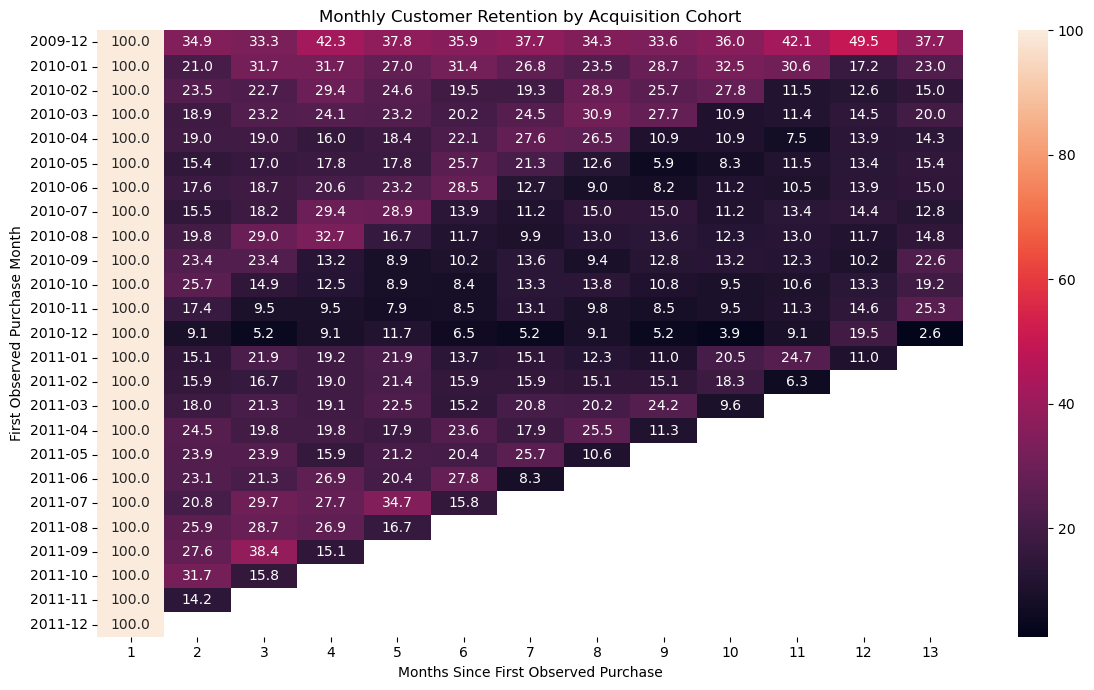

In [308]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    cohort_retention_plot,
    annot=True,
    fmt=".1f",
    mask=cohort_retention_plot.isna()
)

plt.title("Monthly Customer Retention by Acquisition Cohort")

plt.xlabel( "Months Since First Observed Purchase")

plt.ylabel("First Observed Purchase Month")

plt.tight_layout()
plt.show()

In [309]:
cohort_retention_long = (cohort_customer_counts.copy()
)

cohort_retention_long["cohort_size"] = (cohort_retention_long["cohort_month"].map(cohort_sizes))

cohort_retention_long["retention_pct"] = ( cohort_retention_long["active_customer_count"]/ cohort_retention_long["cohort_size"]* 100
)

In [310]:
cohort_retention_long["activity_month"] = (pd.PeriodIndex(cohort_retention_long["cohort_month"],freq="M")
                                            +(cohort_retention_long["cohort_index"] - 1).astype(int)
)

In [311]:
cohort_retention_long["is_initial_dataset_cohort"] = (
    cohort_retention_long["cohort_month"]
    .eq(pd.Period("2009-12", freq="M"))
)

cohort_retention_long["is_partial_final_month"] = (
    cohort_retention_long["activity_month"]
    .eq(pd.Period("2011-12", freq="M"))
)

In [312]:
comparable_cohort_retention = (
    cohort_retention_long.loc[ ~cohort_retention_long["is_initial_dataset_cohort"]
        & ~cohort_retention_long["is_partial_final_month"]]
    .copy()
)

### Cohort Observation-Boundary Adjustments

Two observation-boundary effects were considered before comparing cohort
retention performance.

The `2009-12` cohort was the first cohort available in the dataset. Customers
assigned to this cohort may have purchased before the observation window and
therefore may not represent genuinely newly acquired customers. This cohort
was retained in the complete heatmap but excluded from comparative retention
summaries.

December 2011 contained only a partial month of transaction data. Therefore,
all retention cells whose actual activity month corresponded to `2011-12`
were excluded from comparative summaries. This adjustment was applied not only
to the `2011-12` cohort but also to earlier cohorts whose later cohort periods
fell within the incomplete final month.

In [313]:
selected_cohort_indices = [2, 3, 6, 12]

selected_retention_summary = (
    comparable_cohort_retention.loc[
        comparable_cohort_retention[
            "cohort_index"
        ].isin(selected_cohort_indices)
    ]
    .groupby(
        "cohort_index",
        as_index=False
    )
    .agg(
        eligible_cohort_count=(
            "cohort_month",
            "nunique"
        ),

        total_initial_customers=(
            "cohort_size",
            "sum"
        ),

        total_active_customers=(
            "active_customer_count",
            "sum"
        ),

        median_cohort_retention_pct=(
            "retention_pct",
            "median"
        ),

        minimum_cohort_retention_pct=(
            "retention_pct",
            "min"
        ),

        maximum_cohort_retention_pct=(
            "retention_pct",
            "max"
        )
    )
)

In [314]:
selected_retention_summary[
    "weighted_retention_pct"
] = (
    selected_retention_summary[
        "total_active_customers"
    ]
    / selected_retention_summary[
        "total_initial_customers"
    ]
    * 100
)

selected_retention_summary

,cohort_index,eligible_cohort_count,total_initial_customers,total_active_customers,median_cohort_retention_pct,minimum_cohort_retention_pct,maximum_cohort_retention_pct,weighted_retention_pct
0,2,22,"4,671.00",976,20.27,9.09,31.67,20.89
1,3,21,"4,450.00",956,21.35,5.19,38.38,21.48
2,6,18,"4,056.00",751,17.70,6.49,31.42,18.52
3,12,12,"3,352.00",468,13.90,10.21,19.48,13.96


In [315]:
weighted_retention_curve = (comparable_cohort_retention.groupby("cohort_index",as_index=False).agg(
        eligible_cohort_count=(
            "cohort_month",
            "nunique"
        ),

        total_initial_customers=(
            "cohort_size",
            "sum"
        ),

        total_active_customers=(
            "active_customer_count",
            "sum"
        )
    )
)

In [316]:
weighted_retention_curve[
    "weighted_retention_pct"
] = (
    weighted_retention_curve[
        "total_active_customers"
    ]
    / weighted_retention_curve[
        "total_initial_customers"
    ]
    * 100
)

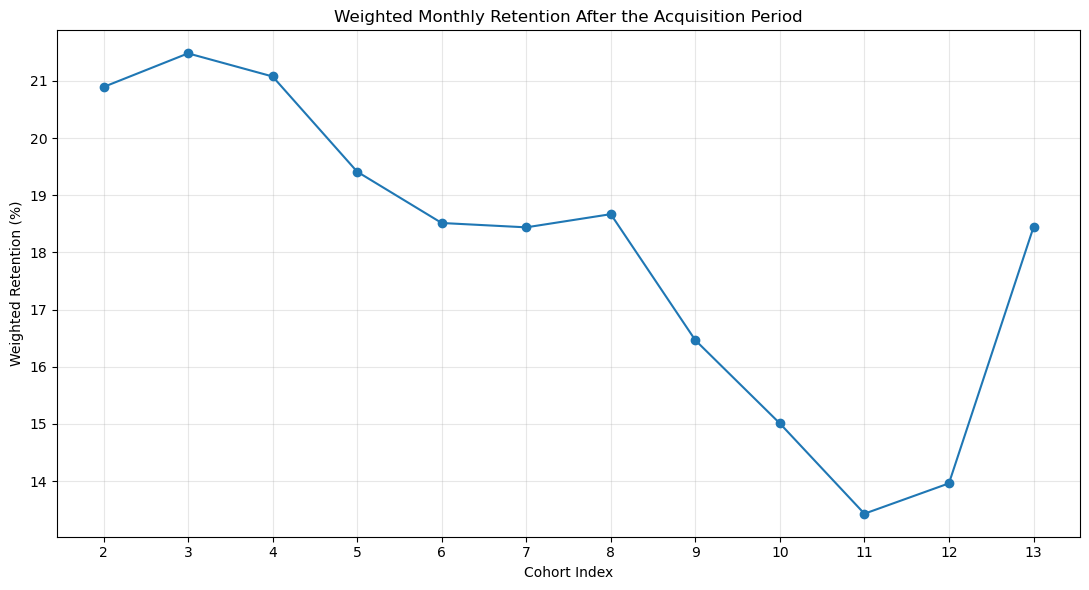

In [317]:
weighted_retention_plot = (
    weighted_retention_curve.loc[
        weighted_retention_curve[
            "cohort_index"
        ].between(2, 13)
    ]
)

plt.figure(figsize=(11, 6))

plt.plot(
    weighted_retention_plot["cohort_index"],
    weighted_retention_plot["weighted_retention_pct"],
    marker="o"
)

plt.title(
    "Weighted Monthly Retention After the Acquisition Period"
)

plt.xlabel("Cohort Index")
plt.ylabel("Weighted Retention (%)")

plt.xticks(
    weighted_retention_plot["cohort_index"]
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [318]:
weighted_retention_curve[
    [
        "cohort_index",
        "eligible_cohort_count",
        "total_initial_customers",
        "total_active_customers",
        "weighted_retention_pct"
    ]
]

,cohort_index,eligible_cohort_count,total_initial_customers,total_active_customers,weighted_retention_pct
0,1,23,"4,861.00",4861,100.00
1,2,22,"4,671.00",976,20.89
2,3,21,"4,450.00",956,21.48
3,4,20,"4,265.00",899,21.08
4,5,19,"4,157.00",807,19.41
5,6,18,"4,056.00",751,18.52
6,7,17,"3,948.00",728,18.44
7,8,16,"3,835.00",716,18.67
8,9,15,"3,729.00",614,16.47
9,10,14,"3,551.00",533,15.01


In [319]:
weighted_retention_curve["months_after_acquisition"] = (
    weighted_retention_curve["cohort_index"] - 1
)

In [320]:
weighted_retention_plot = (
    weighted_retention_curve.loc[weighted_retention_curve["months_after_acquisition"].between(1, 12)]
    .copy()
)

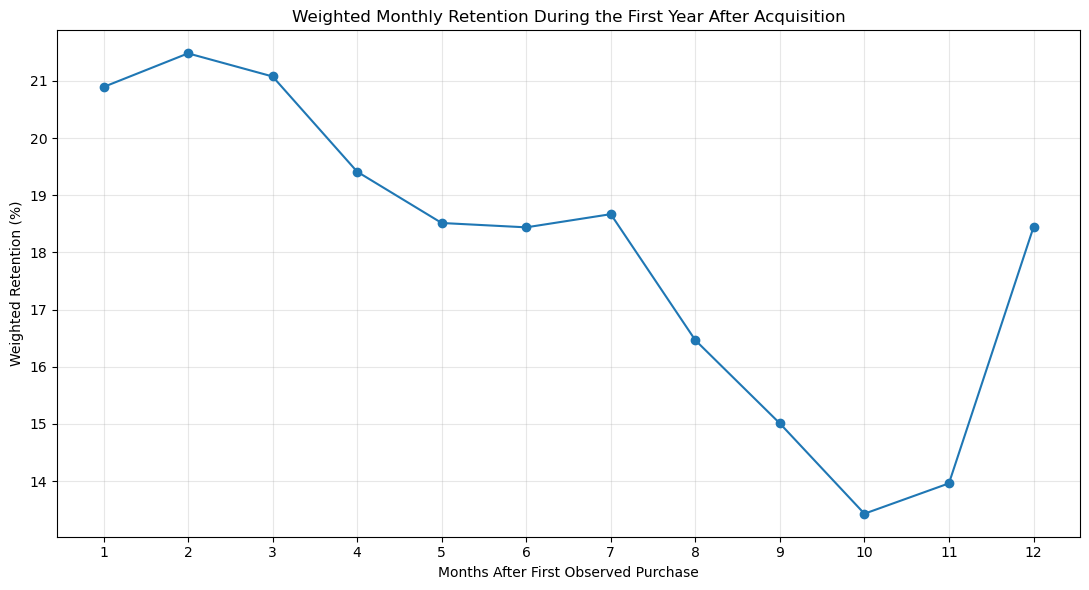

In [321]:
plt.figure(figsize=(11, 6))

plt.plot(
    weighted_retention_plot["months_after_acquisition"],
    weighted_retention_plot["weighted_retention_pct"],
    marker="o"
)

plt.title(
    "Weighted Monthly Retention During the First Year After Acquisition"
)

plt.xlabel("Months After First Observed Purchase")
plt.ylabel("Weighted Retention (%)")

plt.xticks(
    weighted_retention_plot["months_after_acquisition"]
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretation of the Weighted Retention Curve

The weighted retention denominator decreases at later cohort periods because
newer cohorts have not been observed for a sufficiently long period.

For example, Cohort Index 3 represents activity two months after the first
observed purchase. Only cohorts with at least two complete months of follow-up
can contribute to this calculation.

Cohort Index 23 is based on only one eligible cohort and therefore does not
represent the complete customer population. Its retention value describes the
behaviour of the January 2010 cohort 22 months after acquisition.

The primary retention curve was limited to Cohort Indices 2–13, representing
the first twelve months after acquisition. This period retained a substantially
larger and more comparable group of cohorts, while later periods were based on
progressively fewer historical cohorts.

In [322]:
retention_milestone_months = [
    1,
    3,
    6,
    12
]

retention_milestone_summary = (
    weighted_retention_curve.loc[
        weighted_retention_curve[
            "months_after_acquisition"
        ].isin(retention_milestone_months),
        [
            "months_after_acquisition",
            "eligible_cohort_count",
            "total_initial_customers",
            "total_active_customers",
            "weighted_retention_pct"
        ]
    ]
    .reset_index(drop=True)
)

retention_milestone_summary

,months_after_acquisition,eligible_cohort_count,total_initial_customers,total_active_customers,weighted_retention_pct
0,1,22,"4,671.00",976,20.89
1,3,20,"4,265.00",899,21.08
2,6,17,"3,948.00",728,18.44
3,12,11,"3,275.00",604,18.44


### Cohort Retention Conclusions

The weighted retention curve was expressed as the number of months after the
first observed purchase rather than by the technical cohort-index value. This
made the customer lifecycle timeline more directly interpretable.

Approximately 20.89% of eligible customers were active one month after their
first observed purchase. Retention remained close to 21% during the first
three months, before gradually declining during the remainder of the first
year.

Weighted monthly retention decreased to approximately 18.44% after six months
and reached its lowest range, approximately 13%–14%, around ten to eleven
months after acquisition.

A recovery to approximately 18.44% was observed twelve months after the first
purchase. This increase may reflect annual purchasing cycles or seasonal
shopping behaviour. It should also be interpreted cautiously because the
twelve-month estimate was based on fewer eligible cohorts than the earlier
retention periods.

The retention values represent the proportion of customers active during each
specific month. They do not require customers to have remained continuously
active during all previous months. A customer who skipped an earlier month but
returned later was counted as active in the later period.

The analysis excluded the initial `2009-12` cohort from comparative summaries
because customers in the first dataset month may have purchased before the
observation window. Activity periods corresponding to the incomplete final
month, `2011-12`, were also excluded.

In [323]:
customer_model_invoice_sales.head()

,Customer ID,Invoice,invoice_date,country,invoice_total,total_quantity,unique_products,line_count
0,12346,491725,2009-12-14 08:34:00,United Kingdom,45.00,10,1,1
1,12346,491742,2009-12-14 11:00:00,United Kingdom,22.50,5,1,1
2,12346,491744,2009-12-14 11:02:00,United Kingdom,22.50,5,1,1
3,12346,492718,2009-12-18 10:47:00,United Kingdom,22.50,5,1,1
4,12346,492722,2009-12-18 10:55:00,United Kingdom,1.00,1,1,1


## 9. Repeat-Purchase Classification

The classification objective is to estimate whether an existing customer will
make at least one retained merchandise purchase during the following three
complete months.

Each model observation represents a customer at a specific prediction
snapshot. Customer features are calculated exclusively from transactions
within the twelve months preceding the snapshot date. Transactions from the
following three months are used only to construct the binary target.

The target is defined as:

- `1`: the customer makes at least one retained merchandise purchase during
  the following three months,
- `0`: the customer makes no retained merchandise purchase during the
  following three months.

A zero target does not mean that the customer will never purchase again. It
only indicates that no purchase was observed within the defined three-month
prediction horizon.

### Prediction Snapshots

Five customer snapshots were created:

| Snapshot | Role | Observation Window | Target Window |
|---|---|---|---|
| `2011-01-01` | Train | `2010-01-01` to `2011-01-01` | `2011-01-01` to `2011-04-01` |
| `2011-02-01` | Train | `2010-02-01` to `2011-02-01` | `2011-02-01` to `2011-05-01` |
| `2011-03-01` | Train | `2010-03-01` to `2011-03-01` | `2011-03-01` to `2011-06-01` |
| `2011-06-01` | Validation | `2010-06-01` to `2011-06-01` | `2011-06-01` to `2011-09-01` |
| `2011-09-01` | Temporal Holdout | `2010-09-01` to `2011-09-01` | `2011-09-01` to `2011-12-01` |

All date intervals are left-inclusive and right-exclusive. Therefore, a
purchase occurring on the snapshot date belongs to the future target window
and is not included in the customer features.

The first observation window begins on `2010-01-01`, excluding December 2009,
which was the first and potentially boundary-affected month in the dataset.

The three training snapshots expose the model to customer behaviour observed
at different prediction dates and increase the number of customer-snapshot
training examples. Their target windows overlap because they represent a
monthly customer-scoring scenario.

The validation and temporal holdout target windows do not overlap with the
training target period or with each other. They are kept strictly later in
time so that model selection and final performance evaluation reflect future
generalisation.

The final holdout target ends on `2011-12-01`, thereby excluding the incomplete
December 2011 transaction period.## Repeat-Purchase Classification

The classification objective is to predict whether an existing customer will
make at least one merchandise purchase during the following three complete
months.

A customer is included in a prediction dataset when they have at least one
retained merchandise purchase during the preceding twelve-month observation
window.

The binary target is defined as:

- `1`: the customer makes at least one purchase during the three-month target
  window,
- `0`: the customer makes no purchase during the three-month target window.

Customer features are calculated only from transactions available before the
prediction date. Purchases from the target window are used exclusively to
construct the target variable.

This temporal separation is required to prevent future information from
leaking into the model inputs.

In [324]:
classification_windows = pd.DataFrame([
    {
        "snapshot_name": "train_2011_01",
        "dataset_role": "train",
        "snapshot_date": "2011-01-01",
        "observation_start": "2010-01-01",
        "observation_end": "2011-01-01",
        "target_start": "2011-01-01",
        "target_end": "2011-04-01"
    },
    {
        "snapshot_name": "train_2011_02",
        "dataset_role": "train",
        "snapshot_date": "2011-02-01",
        "observation_start": "2010-02-01",
        "observation_end": "2011-02-01",
        "target_start": "2011-02-01",
        "target_end": "2011-05-01"
    },
    {
        "snapshot_name": "train_2011_03",
        "dataset_role": "train",
        "snapshot_date": "2011-03-01",
        "observation_start": "2010-03-01",
        "observation_end": "2011-03-01",
        "target_start": "2011-03-01",
        "target_end": "2011-06-01"
    },
    {
        "snapshot_name": "validation_2011_06",
        "dataset_role": "validation",
        "snapshot_date": "2011-06-01",
        "observation_start": "2010-06-01",
        "observation_end": "2011-06-01",
        "target_start": "2011-06-01",
        "target_end": "2011-09-01"
    },
    {
        "snapshot_name": "holdout_2011_09",
        "dataset_role": "temporal_holdout",
        "snapshot_date": "2011-09-01",
        "observation_start": "2010-09-01",
        "observation_end": "2011-09-01",
        "target_start": "2011-09-01",
        "target_end": "2011-12-01"
    }
])

In [325]:
classification_date_columns = ["snapshot_date","observation_start","observation_end","target_start","target_end"]

classification_windows[classification_date_columns] = (classification_windows[classification_date_columns].apply(pd.to_datetime))

classification_windows

,snapshot_name,dataset_role,snapshot_date,observation_start,observation_end,target_start,target_end
0,train_2011_01,train,2011-01-01,2010-01-01,2011-01-01,2011-01-01,2011-04-01
1,train_2011_02,train,2011-02-01,2010-02-01,2011-02-01,2011-02-01,2011-05-01
2,train_2011_03,train,2011-03-01,2010-03-01,2011-03-01,2011-03-01,2011-06-01
3,validation_2011_06,validation,2011-06-01,2010-06-01,2011-06-01,2011-06-01,2011-09-01
4,holdout_2011_09,temporal_holdout,2011-09-01,2010-09-01,2011-09-01,2011-09-01,2011-12-01


In [326]:
classification_windows["observation_months"] = (
    (
        classification_windows["observation_end"].dt.year
        - classification_windows["observation_start"].dt.year
    )
    * 12
    +
    (
        classification_windows["observation_end"].dt.month
        - classification_windows["observation_start"].dt.month
    )
)

classification_windows["target_months"] = (
    (
        classification_windows["target_end"].dt.year
        - classification_windows["target_start"].dt.year
    )
    * 12
    +
    (
        classification_windows["target_end"].dt.month
        - classification_windows["target_start"].dt.month
    )
)

classification_windows

,snapshot_name,dataset_role,snapshot_date,observation_start,observation_end,target_start,target_end,observation_months,target_months
0,train_2011_01,train,2011-01-01,2010-01-01,2011-01-01,2011-01-01,2011-04-01,12,3
1,train_2011_02,train,2011-02-01,2010-02-01,2011-02-01,2011-02-01,2011-05-01,12,3
2,train_2011_03,train,2011-03-01,2010-03-01,2011-03-01,2011-03-01,2011-06-01,12,3
3,validation_2011_06,validation,2011-06-01,2010-06-01,2011-06-01,2011-06-01,2011-09-01,12,3
4,holdout_2011_09,temporal_holdout,2011-09-01,2010-09-01,2011-09-01,2011-09-01,2011-12-01,12,3


In [327]:
maximum_train_target_end = (
    classification_windows.loc[
        classification_windows["dataset_role"].eq("train"),
        "target_end"
    ]
    .max()
)

validation_target_start = (
    classification_windows.loc[
        classification_windows["dataset_role"].eq("validation"),
        "target_start"
    ]
    .iloc[0]
)

validation_target_end = (
    classification_windows.loc[
        classification_windows["dataset_role"].eq("validation"),
        "target_end"
    ]
    .iloc[0]
)

holdout_target_start = (
    classification_windows.loc[
        classification_windows["dataset_role"]
        .eq("temporal_holdout"),
        "target_start"
    ]
    .iloc[0]
)

In [328]:
classification_window_checks = pd.Series({
    "five_snapshots_are_present": (
        len(classification_windows) == 5
    ),

    "three_training_snapshots_are_present": (
        classification_windows["dataset_role"]
        .eq("train")
        .sum()
        == 3
    ),

    "observation_windows_are_12_months": (
        classification_windows["observation_months"]
        .eq(12)
        .all()
    ),

    "target_windows_are_3_months": (
        classification_windows["target_months"]
        .eq(3)
        .all()
    ),

    "snapshot_equals_observation_end": (
        classification_windows["snapshot_date"]
        .eq(classification_windows["observation_end"])
        .all()
    ),

    "target_starts_at_snapshot": (
        classification_windows["target_start"]
        .eq(classification_windows["snapshot_date"])
        .all()
    ),

    "first_observation_starts_on_2010_01_01": (
        classification_windows["observation_start"]
        .min()
        == pd.Timestamp("2010-01-01")
    ),

    "validation_starts_after_train_targets": (
        validation_target_start
        == maximum_train_target_end
    ),

    "holdout_starts_after_validation_target": (
        holdout_target_start
        == validation_target_end
    ),

    "holdout_excludes_partial_december": (
        classification_windows.loc[
            classification_windows["dataset_role"]
            .eq("temporal_holdout"),
            "target_end"
        ]
        .iloc[0]
        == pd.Timestamp("2011-12-01")
    )
})

classification_window_checks

five_snapshots_are_present                True
three_training_snapshots_are_present      True
observation_windows_are_12_months         True
target_windows_are_3_months               True
snapshot_equals_observation_end           True
target_starts_at_snapshot                 True
first_observation_starts_on_2010_01_01    True
validation_starts_after_train_targets     True
holdout_starts_after_validation_target    True
holdout_excludes_partial_december         True
dtype: bool

In [329]:
def build_snapshot_target(invoice_data,snapshot_window):
    """
    Create one customer-level target dataset for a prediction snapshot.

    Only customers with at least one purchase in the observation window
    are eligible. The target equals 1 when an eligible customer makes at
    least one purchase in the following target window.
    """

    observation_mask = (invoice_data["invoice_date"].ge(snapshot_window["observation_start"])
        &
        invoice_data["invoice_date"].lt(snapshot_window["observation_end"])
    )

    target_mask = (
        invoice_data["invoice_date"].ge(snapshot_window["target_start"])
        &
        invoice_data["invoice_date"].lt(snapshot_window["target_end"])
    )

    eligible_customers = (
        invoice_data.loc[observation_mask,"Customer ID"].drop_duplicates().sort_values())

    target_customers = (invoice_data.loc[ target_mask, "Customer ID"].drop_duplicates()
    )

    snapshot_target = pd.DataFrame({
        "Customer ID": eligible_customers.to_numpy()
    })

    snapshot_target["snapshot_name"] = (
        snapshot_window["snapshot_name"]
    )

    snapshot_target["dataset_role"] = (
        snapshot_window["dataset_role"]
    )

    snapshot_target["snapshot_date"] = (
        snapshot_window["snapshot_date"]
    )

    snapshot_target["repeat_purchase_3m"] = (
        snapshot_target["Customer ID"].isin(target_customers).astype("int8"))

    return snapshot_target

In [330]:
snapshot_target_frames = []

for _, snapshot_window in classification_windows.iterrows():

    current_snapshot_target = build_snapshot_target(
        invoice_data=customer_model_invoice_sales,
        snapshot_window=snapshot_window
    )

    snapshot_target_frames.append(
        current_snapshot_target
    )

In [331]:
classification_targets = pd.concat(
    snapshot_target_frames,
    ignore_index=True
)

classification_targets.head()

,Customer ID,snapshot_name,dataset_role,snapshot_date,repeat_purchase_3m
0,12346,train_2011_01,train,2011-01-01,0
1,12347,train_2011_01,train,2011-01-01,1
2,12348,train_2011_01,train,2011-01-01,1
3,12349,train_2011_01,train,2011-01-01,0
4,12351,train_2011_01,train,2011-01-01,0


In [332]:
classification_target_checks = pd.Series({
    "one_row_per_customer_snapshot": (~classification_targets.duplicated(subset=["Customer ID","snapshot_name"]).any()),

    "no_missing_customer_ids": (classification_targets["Customer ID"].notna().all()),

    "no_missing_targets": (classification_targets["repeat_purchase_3m"].notna() .all()),

    "target_is_binary": ( classification_targets["repeat_purchase_3m"].isin([0, 1]).all()),

    "all_snapshots_are_present": (set(classification_targets["snapshot_name"].unique())
        ==set(classification_windows["snapshot_name"] ))
})

classification_target_checks

one_row_per_customer_snapshot    True
no_missing_customer_ids          True
no_missing_targets               True
target_is_binary                 True
all_snapshots_are_present        True
dtype: bool

In [333]:
snapshot_target_summary = (
    classification_targets.groupby(["dataset_role","snapshot_name","snapshot_date"],as_index=False).agg(
        customer_snapshot_count=("Customer ID","size"),

        positive_customer_count=("repeat_purchase_3m", "sum"))
)

In [334]:
snapshot_target_summary["negative_customer_count"] = (snapshot_target_summary["customer_snapshot_count"]
    -
    snapshot_target_summary["positive_customer_count" ]
)

In [335]:
snapshot_target_summary["positive_rate_pct"] = ( snapshot_target_summary[ "positive_customer_count" ]
    / snapshot_target_summary[ "customer_snapshot_count"]* 100)

snapshot_target_summary

,dataset_role,snapshot_name,snapshot_date,customer_snapshot_count,positive_customer_count,negative_customer_count,positive_rate_pct
0,temporal_holdout,holdout_2011_09,2011-09-01,4317,2147,2170,49.73
1,train,train_2011_01,2011-01-01,4195,1386,2809,33.04
2,train,train_2011_02,2011-02-01,4211,1449,2762,34.41
3,train,train_2011_03,2011-03-01,4252,1575,2677,37.04
4,validation,validation_2011_06,2011-06-01,4318,1591,2727,36.85


In [336]:
classification_windows.head()

,snapshot_name,dataset_role,snapshot_date,observation_start,observation_end,target_start,target_end,observation_months,target_months
0,train_2011_01,train,2011-01-01,2010-01-01,2011-01-01,2011-01-01,2011-04-01,12,3
1,train_2011_02,train,2011-02-01,2010-02-01,2011-02-01,2011-02-01,2011-05-01,12,3
2,train_2011_03,train,2011-03-01,2010-03-01,2011-03-01,2011-03-01,2011-06-01,12,3
3,validation_2011_06,validation,2011-06-01,2010-06-01,2011-06-01,2011-06-01,2011-09-01,12,3
4,holdout_2011_09,temporal_holdout,2011-09-01,2010-09-01,2011-09-01,2011-09-01,2011-12-01,12,3


In [337]:
train_2011_01_window = (classification_windows.loc[classification_windows["snapshot_name"].eq("train_2011_01")].iloc[0])

train_2011_01_window

snapshot_name               train_2011_01
dataset_role                        train
snapshot_date         2011-01-01 00:00:00
observation_start     2010-01-01 00:00:00
observation_end       2011-01-01 00:00:00
target_start          2011-01-01 00:00:00
target_end            2011-04-01 00:00:00
observation_months                     12
target_months                           3
Name: 0, dtype: object

In [338]:
train_2011_01_observation_mask = (customer_model_invoice_sales["invoice_date"].ge(train_2011_01_window["observation_start"])
                                 &customer_model_invoice_sales["invoice_date"].lt(train_2011_01_window["observation_end"]))

In [339]:
train_2011_01_observation_invoices = (customer_model_invoice_sales.loc[train_2011_01_observation_mask].copy())

In [340]:
train_2011_01_observation_invoices.head()

,Customer ID,Invoice,invoice_date,country,invoice_total,total_quantity,unique_products,line_count
5,12346,493410,2010-01-04 09:24:00,United Kingdom,22.50,5,1,1
6,12346,493412,2010-01-04 09:53:00,United Kingdom,22.50,5,1,1
7,12346,494450,2010-01-14 13:50:00,United Kingdom,22.50,5,1,1
8,12346,495295,2010-01-22 13:30:00,United Kingdom,22.50,5,1,1
9,12346,499763,2010-03-02 13:08:00,United Kingdom,27.05,5,5,5


In [341]:
train_2011_01_observation_invoices["invoice_date"].agg(["min", "max"])  #control  #min ≥ 2010-01-01 #max < 2011-01-01    

min   2010-01-04 09:24:00
max   2010-12-23 16:06:00
Name: invoice_date, dtype: datetime64[ns]

In [342]:
train_2011_01_observation_invoices["invoice_month"] = (train_2011_01_observation_invoices["invoice_date"].dt.to_period("M"))

In [343]:
train_2011_01_features = (train_2011_01_observation_invoices.groupby("Customer ID",as_index=False).agg(
        first_purchase_date=("invoice_date","min"),

        last_purchase_date=("invoice_date","max"),

        invoice_count_12m=("Invoice","size"),

        total_spending_12m=("invoice_total","sum"),

        average_invoice_value_12m=("invoice_total","mean"),

        median_invoice_value_12m=("invoice_total","median"),

        total_quantity_12m=("total_quantity","sum"),

        average_quantity_per_invoice_12m=("total_quantity","mean"),

        average_unique_products_per_invoice_12m=("unique_products", "mean"),

        active_month_count_12m=("invoice_month","nunique")
    )
)

In [344]:
train_2011_01_features["recency_days"] = (train_2011_01_window["snapshot_date"]-train_2011_01_features["last_purchase_date"]).dt.days

In [345]:
train_2011_01_features["observed_purchase_span_days"] = (train_2011_01_features["last_purchase_date"]-train_2011_01_features[ "first_purchase_date"]
).dt.days

In [346]:
train_2011_01_features["snapshot_name"] = (train_2011_01_window["snapshot_name"])

train_2011_01_features["dataset_role"] = (train_2011_01_window["dataset_role"])

train_2011_01_features["snapshot_date"] = (train_2011_01_window["snapshot_date"])

In [347]:
classification_targets.head()

,Customer ID,snapshot_name,dataset_role,snapshot_date,repeat_purchase_3m
0,12346,train_2011_01,train,2011-01-01,0
1,12347,train_2011_01,train,2011-01-01,1
2,12348,train_2011_01,train,2011-01-01,1
3,12349,train_2011_01,train,2011-01-01,0
4,12351,train_2011_01,train,2011-01-01,0


In [348]:
train_2011_01_target = (classification_targets.loc[classification_targets["snapshot_name"].eq("train_2011_01"),["Customer ID","repeat_purchase_3m"]]
.copy()
)

In [349]:
train_2011_01_target.head()

,Customer ID,repeat_purchase_3m
0,12346,0
1,12347,1
2,12348,1
3,12349,0
4,12351,0


In [350]:
train_2011_01_model_data = (train_2011_01_features.merge(train_2011_01_target,on="Customer ID",how="inner",validate="one_to_one"))

In [351]:
train_2011_01_model_data[
    [
        "Customer ID",
        "snapshot_date",
        "recency_days",
        "invoice_count_12m",
        "total_spending_12m",
        "active_month_count_12m",
        "repeat_purchase_3m"
    ]
].head(10)

,Customer ID,snapshot_date,recency_days,invoice_count_12m,total_spending_12m,active_month_count_12m,repeat_purchase_3m
0,12346,2011-01-01,186,6,259.36,3,0
1,12347,2011-01-01,24,2,"1,323.32",2,1
2,12348,2011-01-01,15,2,873.96,2,1
3,12349,2011-01-01,64,2,"2,221.14",2,0
4,12351,2011-01-01,32,1,300.93,1,0
5,12352,2011-01-01,32,2,343.80,1,1
6,12353,2011-01-01,65,1,317.76,1,0
7,12355,2011-01-01,224,1,488.21,1,0
8,12356,2011-01-01,37,3,"3,124.30",2,1
9,12357,2011-01-01,45,1,"11,229.99",1,0


In [352]:
def build_snapshot_features(
    invoice_data,
    snapshot_window
):
    """
    Build customer-level behavioural features using only invoices
    available within the twelve-month observation window.
    """

    observation_mask = (
        invoice_data["invoice_date"]
        .ge(snapshot_window["observation_start"])
        &
        invoice_data["invoice_date"]
        .lt(snapshot_window["observation_end"])
    )

    observation_invoices = (
        invoice_data.loc[
            observation_mask
        ]
        .copy()
    )

    observation_invoices["invoice_month"] = (
        observation_invoices["invoice_date"]
        .dt.to_period("M")
    )

    snapshot_features = (
        observation_invoices
        .groupby(
            "Customer ID",
            as_index=False
        )
        .agg(
            first_purchase_date=(
                "invoice_date",
                "min"
            ),

            last_purchase_date=(
                "invoice_date",
                "max"
            ),

            invoice_count_12m=(
                "Invoice",
                "size"
            ),

            total_spending_12m=(
                "invoice_total",
                "sum"
            ),

            average_invoice_value_12m=(
                "invoice_total",
                "mean"
            ),

            median_invoice_value_12m=(
                "invoice_total",
                "median"
            ),

            total_quantity_12m=(
                "total_quantity",
                "sum"
            ),

            average_quantity_per_invoice_12m=(
                "total_quantity",
                "mean"
            ),

            average_unique_products_per_invoice_12m=(
                "unique_products",
                "mean"
            ),

            active_month_count_12m=(
                "invoice_month",
                "nunique"
            )
        )
    )

    snapshot_features["recency_days"] = (
        snapshot_window["snapshot_date"]
        -
        snapshot_features["last_purchase_date"]
    ).dt.days

    snapshot_features[
        "observed_purchase_span_days"
    ] = (
        snapshot_features["last_purchase_date"]
        -
        snapshot_features["first_purchase_date"]
    ).dt.days

    snapshot_features["snapshot_name"] = (
        snapshot_window["snapshot_name"]
    )

    snapshot_features["dataset_role"] = (
        snapshot_window["dataset_role"]
    )

    snapshot_features["snapshot_date"] = (
        snapshot_window["snapshot_date"]
    )

    snapshot_features["observation_start"] = (
        snapshot_window["observation_start"]
    )

    snapshot_features["observation_end"] = (
        snapshot_window["observation_end"]
    )

    return snapshot_features    

In [353]:
snapshot_feature_frames = []

for _, snapshot_window in classification_windows.iterrows():

    current_snapshot_features = build_snapshot_features(
        invoice_data=customer_model_invoice_sales,
        snapshot_window=snapshot_window
    )

    snapshot_feature_frames.append(
        current_snapshot_features
    )

In [354]:
classification_features = pd.concat(
    snapshot_feature_frames,
    ignore_index=True
)

classification_features.shape

(21293, 18)

In [355]:
classification_targets.head()

,Customer ID,snapshot_name,dataset_role,snapshot_date,repeat_purchase_3m
0,12346,train_2011_01,train,2011-01-01,0
1,12347,train_2011_01,train,2011-01-01,1
2,12348,train_2011_01,train,2011-01-01,1
3,12349,train_2011_01,train,2011-01-01,0
4,12351,train_2011_01,train,2011-01-01,0


In [356]:
classification_model_data = (
    classification_features
    .merge(classification_targets,on=["Customer ID","snapshot_name","dataset_role","snapshot_date"],how="inner",validate="one_to_one")
)

### Customer-Snapshot Feature Construction

Customer behavioural features were calculated independently for each
prediction snapshot.

Each row represents one customer at one snapshot date. Features were derived
only from retained merchandise invoices within the preceding twelve-month
observation window.

The feature set captures:

- purchase recency,
- invoice frequency,
- total and typical monetary value,
- purchased quantity,
- basket-level product diversity,
- the number of active purchasing months,
- and the observed purchasing span within the twelve-month window.

The same customer may appear in multiple snapshots because each row represents
the customer's state at a different prediction date. The unique modelling unit
is therefore the combination of `Customer ID` and `snapshot_name`.

Future target-period transactions were not used in any feature calculation.
They were used exclusively to construct the `repeat_purchase_3m` target.

In [357]:
train_model_data = (
    classification_model_data.loc[
        classification_model_data["dataset_role"].eq("train")
    ]
    .copy()
)

validation_model_data = (
    classification_model_data.loc[
        classification_model_data["dataset_role"].eq("validation")
    ]
    .copy()
)

holdout_model_data = (
    classification_model_data.loc[
        classification_model_data["dataset_role"]
        .eq("temporal_holdout")
    ]
    .copy()
)

In [358]:
classification_feature_columns = [
    "recency_days",
    "invoice_count_12m",
    "total_spending_12m",
    "average_invoice_value_12m",
    "median_invoice_value_12m",
    "total_quantity_12m",
    "average_quantity_per_invoice_12m",
    "average_unique_products_per_invoice_12m",
    "active_month_count_12m",
    "observed_purchase_span_days"
]

target_column = "repeat_purchase_3m"

In [359]:
temporal_split_summary = pd.DataFrame([
    {
        "dataset_role": "train",
        "row_count": len(train_model_data),
        "unique_customer_count": (
            train_model_data["Customer ID"].nunique()
        ),
        "snapshot_count": (
            train_model_data["snapshot_name"].nunique()
        ),
        "positive_rate_pct": (
            train_model_data[target_column].mean() * 100
        )
    },
    {
        "dataset_role": "validation",
        "row_count": len(validation_model_data),
        "unique_customer_count": (
            validation_model_data["Customer ID"].nunique()
        ),
        "snapshot_count": (
            validation_model_data["snapshot_name"].nunique()
        ),
        "positive_rate_pct": (
            validation_model_data[target_column].mean() * 100
        )
    },
    {
        "dataset_role": "temporal_holdout",
        "row_count": len(holdout_model_data),
        "unique_customer_count": (
            holdout_model_data["Customer ID"].nunique()
        ),
        "snapshot_count": (
            holdout_model_data["snapshot_name"].nunique()
        ),
        "positive_rate_pct": (
            holdout_model_data[target_column].mean() * 100
        )
    }
])

temporal_split_summary

,dataset_role,row_count,unique_customer_count,snapshot_count,positive_rate_pct
0,train,12658,4399,3,34.84
1,validation,4318,4318,1,36.85
2,temporal_holdout,4317,4317,1,49.73


In [360]:
train_feature_distribution = (
    train_model_data[classification_feature_columns].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

train_feature_distribution

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
recency_days,"12,658.00",111.39,90.61,0.00,1.00,8.00,42.00,88.00,152.00,307.00,349.00,364.00
invoice_count_12m,"12,658.00",4.26,7.50,1.00,1.00,1.00,1.00,2.00,5.00,13.00,30.00,180.00
total_spending_12m,"12,658.00","1,895.80","7,735.70",3.75,39.62,107.59,301.25,669.91,"1,628.80","5,808.55","18,578.56","306,876.21"
average_invoice_value_12m,"12,658.00",373.94,492.32,3.75,33.93,88.50,176.49,281.74,422.50,909.50,"1,858.91","11,880.84"
median_invoice_value_12m,"12,658.00",358.96,470.96,3.75,30.60,81.39,168.56,279.70,404.99,877.26,"1,796.00","11,880.84"
total_quantity_12m,"12,658.00","1,184.69","5,408.19",1.00,11.00,44.00,156.00,375.00,950.00,"3,379.15","11,590.23","218,002.00"
average_quantity_per_invoice_12m,"12,658.00",260.27,"1,654.71",1.00,9.00,34.00,89.67,152.00,260.00,597.86,"1,346.15","87,167.00"
average_unique_products_per_invoice_12m,"12,658.00",21.60,18.34,1.00,1.00,2.50,9.86,17.33,27.50,55.20,88.00,230.00
active_month_count_12m,"12,658.00",2.94,2.46,1.00,1.00,1.00,1.00,2.00,4.00,8.00,11.00,12.00
observed_purchase_span_days,"12,658.00",119.38,119.41,0.00,0.00,0.00,0.00,90.00,229.00,325.00,350.00,364.00


In [361]:
train_feature_skewness = (train_model_data[classification_feature_columns].skew().sort_values(ascending=False).rename("skewness").to_frame())

train_feature_skewness

,skewness
average_quantity_per_invoice_12m,44.43
total_spending_12m,22.51
total_quantity_12m,20.27
median_invoice_value_12m,12.28
average_invoice_value_12m,11.59
invoice_count_12m,9.85
average_unique_products_per_invoice_12m,2.66
active_month_count_12m,1.62
recency_days,1.01
observed_purchase_span_days,0.44


In [362]:
snapshot_feature_medians = (classification_model_data.groupby(["dataset_role","snapshot_name","snapshot_date"])[ classification_feature_columns]
    .median()
    .round(2)
)

snapshot_feature_medians

recency_days  \
dataset_role     snapshot_name      snapshot_date                 
temporal_holdout holdout_2011_09    2011-09-01           111.00   
train            train_2011_01      2011-01-01            66.00   
                 train_2011_02      2011-02-01            87.00   
                 train_2011_03      2011-03-01           104.00   
validation       validation_2011_06 2011-06-01           110.00   

                                                   invoice_count_12m  \
dataset_role     snapshot_name      snapshot_date                      
temporal_holdout holdout_2011_09    2011-09-01                  2.00   
train            train_2011_01      2011-01-01                  2.00   
                 train_2011_02      2011-02-01                  2.00   
                 train_2011_03      2011-03-01                  2.00   
validation       validation_2011_06 2011-06-01                  2.00   

                                                   total_spending_12m  \
dataset_role     snapshot_name      snapshot_date                       
temporal_holdout holdout_2011_09    2011-09-01                 630.43   
train            train_2011_01      2011-01-01                 681.97   
                 train_2011_02      2011-02-01                 670.98   
                 train_2011_03      2011-03-01                 657.76   
validation       validation_2011_06 2011-06-01                 632.95   

                                                   average_invoice_value_12m  \
dataset_role     snapshot_name      snapshot_date                              
temporal_holdout holdout_2011_09    2011-09-01                        283.03   
train            train_2011_01      2011-01-01                        282.59   
                 train_2011_02      2011-02-01                        282.01   
                 train_2011_03      2011-03-01                        281.19   
validation       validation_2011_06 2011-06-01                        281.64   

                                                   median_invoice_value_12m  \
dataset_role     snapshot_name      snapshot_date                             
temporal_holdout holdout_2011_09    2011-09-01                       279.00   
train            train_2011_01      2011-01-01                       280.62   
                 train_2011_02      2011-02-01                       279.67   
                 train_2011_03      2011-03-01                       279.45   
validation       validation_2011_06 2011-06-01                       279.25   

                                                   total_quantity_12m  \
dataset_role     snapshot_name      snapshot_date                       
temporal_holdout holdout_2011_09    2011-09-01                 353.00   
train            train_2011_01      2011-01-01                 380.00   
                 train_2011_02      2011-02-01                 376.00   
                 train_2011_03      2011-03-01                 368.00   
validation       validation_2011_06 2011-06-01                 354.00   

                                                   average_quantity_per_invoice_12m  \
dataset_role     snapshot_name      snapshot_date                                     
temporal_holdout holdout_2011_09    2011-09-01                               153.00   
train            train_2011_01      2011-01-01                               152.00   
                 train_2011_02      2011-02-01                               152.00   
                 train_2011_03      2011-03-01                               152.28   
validation       validation_2011_06 2011-06-01                               152.00   

                                                   average_unique_products_per_invoice_12m  \
dataset_role     snapshot_name      snapshot_date                                            
temporal_holdout holdout_2011_09    2011-09-01                                       17.00   
train            train_2011_01      2011-01-0

In [363]:
dataset_role_feature_medians = (classification_model_data.groupby("dataset_role")[ classification_feature_columns]
    .median()
    .T
    .reindex(columns=["train","validation","temporal_holdout"])
)

In [364]:
train_median_denominator = (
    dataset_role_feature_medians["train"]
    .replace(0, np.nan)
)

dataset_role_feature_medians[
    "validation_vs_train_change_pct"
] = (
    (
        dataset_role_feature_medians["validation"]
        -
        dataset_role_feature_medians["train"]
    )
    /
    train_median_denominator
    * 100
)

dataset_role_feature_medians[
    "holdout_vs_train_change_pct"
] = (
    (
        dataset_role_feature_medians["temporal_holdout"]
        -
        dataset_role_feature_medians["train"]
    )
    /
    train_median_denominator
    * 100
)

dataset_role_feature_medians.round(2)

dataset_role,train,validation,temporal_holdout,validation_vs_train_change_pct,holdout_vs_train_change_pct
recency_days,88.00,110.00,111.00,25.00,26.14
invoice_count_12m,2.00,2.00,2.00,0.00,0.00
total_spending_12m,669.91,632.95,630.43,-5.52,-5.89
average_invoice_value_12m,281.74,281.64,283.03,-0.04,0.46
median_invoice_value_12m,279.70,279.25,279.00,-0.16,-0.25
total_quantity_12m,375.00,354.00,353.00,-5.60,-5.87
average_quantity_per_invoice_12m,152.00,152.00,153.00,0.00,0.66
average_unique_products_per_invoice_12m,17.33,17.00,17.00,-1.92,-1.92
active_month_count_12m,2.00,2.00,2.00,0.00,0.00
observed_purchase_span_days,90.00,74.00,71.00,-17.78,-21.11


In [365]:
X_train = train_model_data[
    classification_feature_columns
].copy()

y_train = train_model_data[
    target_column
].copy()

X_validation = validation_model_data[
    classification_feature_columns
].copy()

y_validation = validation_model_data[
    target_column
].copy()

X_temporal_holdout = holdout_model_data[
    classification_feature_columns
].copy()

y_temporal_holdout = holdout_model_data[
    target_column
].copy() 

In [366]:
# X_train, y_train
#X_validation, y_validation
#X_temporal_holdout, y_temporal_holdout

In [367]:
log_transform_columns = [
    "invoice_count_12m",
    "total_spending_12m",
    "average_invoice_value_12m",
    "median_invoice_value_12m",
    "total_quantity_12m",
    "average_quantity_per_invoice_12m",
    "average_unique_products_per_invoice_12m"
]

log_transform_checks = pd.Series({
    "no_missing_values": (classification_model_data[log_transform_columns].notna().all().all()),

    "all_values_are_non_negative": (classification_model_data[log_transform_columns].ge(0).all().all()),

    "all_values_are_finite": (np.isfinite( classification_model_data[log_transform_columns].to_numpy()).all())
})

log_transform_checks

no_missing_values              True
all_values_are_non_negative    True
all_values_are_finite          True
dtype: bool

In [368]:
classification_model_data_log = (classification_model_data.copy())

for column in log_transform_columns:

    classification_model_data_log[f"log1p_{column}"] = np.log1p(classification_model_data_log[column])


In [369]:
log_feature_columns = [f"log1p_{column}" for column in log_transform_columns]

skewness_before_after = pd.DataFrame({
    "skewness_before": (classification_model_data_log.loc[classification_model_data_log["dataset_role"].eq("train"),log_transform_columns].skew()),

    "skewness_after_log1p": (classification_model_data_log.loc[classification_model_data_log["dataset_role"].eq("train"),log_feature_columns].skew()
        .set_axis(log_transform_columns)
    )
})

skewness_before_after["absolute_skewness_reduction"] = (
    skewness_before_after["skewness_before"].abs()
    -
    skewness_before_after["skewness_after_log1p"].abs()
)

skewness_before_after.sort_values("skewness_before",ascending=False)

,skewness_before,skewness_after_log1p,absolute_skewness_reduction
average_quantity_per_invoice_12m,44.43,-0.29,44.14
total_spending_12m,22.51,0.25,22.26
total_quantity_12m,20.27,0.01,20.27
median_invoice_value_12m,12.28,-0.17,12.11
average_invoice_value_12m,11.59,-0.09,11.50
invoice_count_12m,9.85,1.20,8.65
average_unique_products_per_invoice_12m,2.66,-0.47,2.20


In [370]:
train_feature_correlations = (classification_model_data.loc[classification_model_data["dataset_role"].eq("train"),classification_feature_columns]
.corr(method="spearman")
)

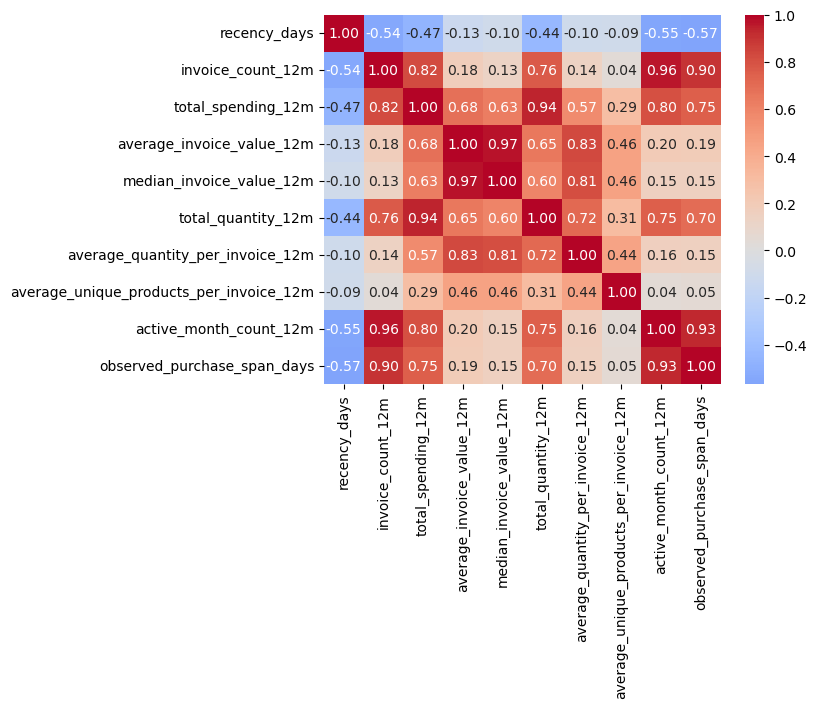

In [371]:
sns.heatmap(train_feature_correlations,annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.show()

In [372]:
def find_high_correlation_pairs(df,threshold=0.80,method="spearman"):
    correlation_matrix = df.corr(method=method)

    high_correlation_records = []

    for i in range(len(correlation_matrix.columns)):
        for j in range(i):

            correlation_value = (correlation_matrix.iloc[i, j])

            if abs(correlation_value) >= threshold:

                high_correlation_records.append({
                    "feature_1": (correlation_matrix.columns[j]),
                    "feature_2":(correlation_matrix.columns[i]),
                    "correlation": correlation_value,
                    "absolute_correlation": abs(correlation_value)
                })

    high_correlation_pairs = pd.DataFrame(high_correlation_records)

    if not high_correlation_pairs.empty:

        high_correlation_pairs = (high_correlation_pairs.sort_values("absolute_correlation",ascending=False).reset_index(drop=True))

    return high_correlation_pairs

In [373]:
high_correlation_pairs = (find_high_correlation_pairs(df=train_model_data[classification_feature_columns],threshold=0.80,method="spearman"))

high_correlation_pairs

,feature_1,feature_2,correlation,absolute_correlation
0,average_invoice_value_12m,median_invoice_value_12m,0.97,0.97
1,invoice_count_12m,active_month_count_12m,0.96,0.96
2,total_spending_12m,total_quantity_12m,0.94,0.94
3,active_month_count_12m,observed_purchase_span_days,0.93,0.93
4,invoice_count_12m,observed_purchase_span_days,0.90,0.90
5,average_invoice_value_12m,average_quantity_per_invoice_12m,0.83,0.83
6,invoice_count_12m,total_spending_12m,0.82,0.82
7,median_invoice_value_12m,average_quantity_per_invoice_12m,0.81,0.81
8,total_spending_12m,active_month_count_12m,0.80,0.80


In [374]:
train_target_feature_profile = (train_model_data.groupby(target_column)[classification_feature_columns]
    .median()
    .T
    .rename(
        columns={
            0: "negative_target_median",
            1: "positive_target_median"
        }
    )
)

In [375]:
train_target_feature_profile[
    "positive_minus_negative"
] = (
    train_target_feature_profile[
        "positive_target_median"
    ]
    -
    train_target_feature_profile[
        "negative_target_median"
    ]
)

In [376]:
train_target_feature_profile[
    "positive_vs_negative_change_pct"
] = (
    train_target_feature_profile[
        "positive_minus_negative"
    ]
    /
    train_target_feature_profile[
        "negative_target_median"
    ].replace(0, np.nan)
    * 100
)

train_target_feature_profile.round(2)

repeat_purchase_3m,negative_target_median,positive_target_median,positive_minus_negative,positive_vs_negative_change_pct
recency_days,105.00,52.00,-53.00,-50.48
invoice_count_12m,2.00,5.00,3.00,150.00
total_spending_12m,465.70,"1,541.86","1,076.16",231.09
average_invoice_value_12m,257.06,318.94,61.88,24.07
median_invoice_value_12m,250.72,310.77,60.05,23.95
total_quantity_12m,259.50,857.00,597.50,230.25
average_quantity_per_invoice_12m,140.00,181.00,41.00,29.29
average_unique_products_per_invoice_12m,17.00,18.00,1.00,5.88
active_month_count_12m,2.00,4.00,2.00,100.00
observed_purchase_span_days,18.00,214.00,196.00,"1,088.89"


In [377]:
redundant_feature_columns = [
    "average_invoice_value_12m",
    "total_quantity_12m",
    "average_quantity_per_invoice_12m",
    "active_month_count_12m"
]

In [378]:
reduced_base_feature_columns = [
    "recency_days",
    "invoice_count_12m",
    "total_spending_12m",
    "median_invoice_value_12m",
    "average_unique_products_per_invoice_12m",
    "observed_purchase_span_days"
]

In [379]:
reduced_log_transform_columns = [
    "invoice_count_12m",
    "total_spending_12m",
    "median_invoice_value_12m",
    "average_unique_products_per_invoice_12m"
]

In [380]:
reduced_raw_columns = [
    "recency_days",
    "observed_purchase_span_days"
]

In [381]:
classification_model_data_final = (classification_model_data.copy())

for column in reduced_log_transform_columns:

    classification_model_data_final[f"log1p_{column}"] = np.log1p(classification_model_data_final[column])

In [382]:
logistic_feature_columns = [
    "recency_days",
    "log1p_invoice_count_12m",
    "log1p_total_spending_12m",
    "log1p_median_invoice_value_12m",
    "log1p_average_unique_products_per_invoice_12m",
    "observed_purchase_span_days"
]

In [383]:
tree_feature_columns = reduced_base_feature_columns.copy()

In [384]:
snapshot_date = train_2011_01_window["snapshot_date"]

In [385]:
recent_3m_start = (snapshot_date- pd.DateOffset(months=3))

recent_3m_start

Timestamp('2010-10-01 00:00:00')

In [386]:
recent_6m_start = (snapshot_date- pd.DateOffset(months=6))

recent_6m_start 

Timestamp('2010-07-01 00:00:00')

In [387]:
recent_3m_mask = (train_2011_01_observation_invoices["invoice_date"].ge(recent_3m_start)
                  &  train_2011_01_observation_invoices["invoice_date"].lt(snapshot_date))

In [388]:
train_2011_01_recent_3m_invoices = (train_2011_01_observation_invoices.loc[recent_3m_mask].copy())

In [389]:
train_2011_01_recent_3m_features = (train_2011_01_recent_3m_invoices.groupby("Customer ID",as_index=False).agg(
        recent_invoice_count_3m=(
            "Invoice",
            "size"
        ),

        recent_spending_3m=(
            "invoice_total",
            "sum"
        )
    )
)

In [390]:
recent_6m_mask = (
    train_2011_01_observation_invoices["invoice_date"]
    .ge(recent_6m_start)
    &
    train_2011_01_observation_invoices["invoice_date"]
    .lt(snapshot_date)
)

In [391]:
train_2011_01_recent_6m_invoices = (
    train_2011_01_observation_invoices.loc[
        recent_6m_mask
    ]
    .copy()
)

In [392]:
train_2011_01_recent_6m_features = (
    train_2011_01_recent_6m_invoices
    .groupby(
        "Customer ID",
        as_index=False
    )
    .agg(
        recent_invoice_count_6m=(
            "Invoice",
            "size"
        ),

        recent_spending_6m=(
            "invoice_total",
            "sum"
        )
    )
)

In [393]:
train_2011_01_features = (
    train_2011_01_features
    .merge(
        train_2011_01_recent_3m_features,
        on="Customer ID",
        how="left",
        validate="one_to_one"
    )
    .merge(
        train_2011_01_recent_6m_features,
        on="Customer ID",
        how="left",
        validate="one_to_one"
    )
)

In [394]:
recent_feature_columns = [
    "recent_invoice_count_3m",
    "recent_spending_3m",
    "recent_invoice_count_6m",
    "recent_spending_6m"
]

train_2011_01_features[
    recent_feature_columns
] = (
    train_2011_01_features[
        recent_feature_columns
    ]
    .fillna(0)
)

In [395]:
def build_snapshot_features(invoice_data, snapshot_window):

    """
    Build customer-level features for one prediction snapshot.

    All features are calculated only from invoices inside the
    twelve-month observation window preceding the snapshot date.
    """

    observation_start = (snapshot_window["observation_start"])

    observation_end = (snapshot_window["observation_end"])

    snapshot_date = (snapshot_window["snapshot_date"])

    # ---------------------------------------------------------
    # 1. Select the twelve-month observation invoices
    # ---------------------------------------------------------

    observation_mask = (invoice_data["invoice_date"].ge(observation_start)
                        & invoice_data["invoice_date"].lt(observation_end))

    observation_invoices = (invoice_data.loc[ observation_mask].copy())

    observation_invoices["invoice_month"] = (observation_invoices["invoice_date"].dt.to_period("M"))

    # ---------------------------------------------------------
    # 2. Build twelve-month customer features
    # ---------------------------------------------------------

    snapshot_features = (
        observation_invoices.groupby( "Customer ID", as_index=False).agg(
            first_purchase_date=(
                "invoice_date",
                "min"
            ),

            last_purchase_date=(
                "invoice_date",
                "max"
            ),

            invoice_count_12m=(
                "Invoice",
                "size"
            ),

            total_spending_12m=(
                "invoice_total",
                "sum"
            ),

            average_invoice_value_12m=(
                "invoice_total",
                "mean"
            ),

            median_invoice_value_12m=(
                "invoice_total",
                "median"
            ),

            total_quantity_12m=(
                "total_quantity",
                "sum"
            ),

            average_quantity_per_invoice_12m=(
                "total_quantity",
                "mean"
            ),

            average_unique_products_per_invoice_12m=(
                "unique_products",
                "mean"
            ),

            active_month_count_12m=(
                "invoice_month",
                "nunique"
            )
        )
    )

    snapshot_features["recency_days"] = (snapshot_date -snapshot_features["last_purchase_date"]).dt.days

    snapshot_features[ "observed_purchase_span_days"] = (snapshot_features["last_purchase_date"] - snapshot_features["first_purchase_date"]).dt.days

    # ---------------------------------------------------------
    # 3. Define recent three-month and six-month periods
    # ---------------------------------------------------------

    recent_3m_start = (snapshot_date- pd.DateOffset(months=3))

    recent_6m_start = ( snapshot_date- pd.DateOffset(months=6))

    # ---------------------------------------------------------
    # 4. Select recent three-month invoices
    # ---------------------------------------------------------

    recent_3m_mask = (observation_invoices["invoice_date"].ge(recent_3m_start)
                    &  observation_invoices["invoice_date"].lt(snapshot_date))

    recent_3m_invoices = (observation_invoices.loc[recent_3m_mask].copy())

    recent_3m_features = (recent_3m_invoices.groupby("Customer ID",as_index=False).agg(
            recent_invoice_count_3m=(
                "Invoice",
                "size"
            ),

            recent_spending_3m=(
                "invoice_total",
                "sum"
            )
        )
    )

    # ---------------------------------------------------------
    # 5. Select recent six-month invoices
    # ---------------------------------------------------------

    recent_6m_mask = (observation_invoices["invoice_date"].ge(recent_6m_start)
                        & observation_invoices["invoice_date"].lt(snapshot_date))

    recent_6m_invoices = ( observation_invoices.loc[recent_6m_mask].copy())

    recent_6m_features = (recent_6m_invoices .groupby("Customer ID", as_index=False).agg(
            recent_invoice_count_6m=(
                "Invoice",
                "size"
            ),

            recent_spending_6m=(
                "invoice_total",
                "sum"
            )
        )
    )

    # ---------------------------------------------------------
    # 6. Add recent features to the twelve-month table
    # ---------------------------------------------------------

    snapshot_features = (
        snapshot_features
        .merge(
            recent_3m_features,
            on="Customer ID",
            how="left",
            validate="one_to_one"
        )
        .merge(
            recent_6m_features,
            on="Customer ID",
            how="left",
            validate="one_to_one"
        )
    )

    recent_feature_columns = [
        "recent_invoice_count_3m",
        "recent_spending_3m",
        "recent_invoice_count_6m",
        "recent_spending_6m"
    ]

    snapshot_features[recent_feature_columns] = (snapshot_features[recent_feature_columns].fillna(0))

    snapshot_features[["recent_invoice_count_3m","recent_invoice_count_6m"]] = (snapshot_features
                                                                [["recent_invoice_count_3m","recent_invoice_count_6m"]].astype("int16"))

    # ---------------------------------------------------------
    # 7. Add snapshot metadata
    # ---------------------------------------------------------

    snapshot_features["snapshot_name"] = (snapshot_window["snapshot_name"])

    snapshot_features["dataset_role"] = (snapshot_window["dataset_role"])

    snapshot_features["snapshot_date"] = (snapshot_date)

    snapshot_features["observation_start"] = ( observation_start)

    snapshot_features["observation_end"] = (observation_end)

    return snapshot_features

In [396]:
snapshot_feature_frames = []

for _, snapshot_window in classification_windows.iterrows():

    current_snapshot_features = (build_snapshot_features(invoice_data=customer_model_invoice_sales,snapshot_window=snapshot_window))


    snapshot_feature_frames.append(current_snapshot_features)

In [397]:
classification_windows.head()

,snapshot_name,dataset_role,snapshot_date,observation_start,observation_end,target_start,target_end,observation_months,target_months
0,train_2011_01,train,2011-01-01,2010-01-01,2011-01-01,2011-01-01,2011-04-01,12,3
1,train_2011_02,train,2011-02-01,2010-02-01,2011-02-01,2011-02-01,2011-05-01,12,3
2,train_2011_03,train,2011-03-01,2010-03-01,2011-03-01,2011-03-01,2011-06-01,12,3
3,validation_2011_06,validation,2011-06-01,2010-06-01,2011-06-01,2011-06-01,2011-09-01,12,3
4,holdout_2011_09,temporal_holdout,2011-09-01,2010-09-01,2011-09-01,2011-09-01,2011-12-01,12,3


In [398]:
classification_features = pd.concat(snapshot_feature_frames,ignore_index=True)

classification_features.shape

(21293, 22)

In [399]:
classification_model_data = (classification_features.merge(classification_targets,
        on=[
            "Customer ID",
            "snapshot_name",
            "dataset_role",
            "snapshot_date"
        ],
        how="inner",
        validate="one_to_one"
    )
)

In [400]:
recent_feature_columns = [
    "recent_invoice_count_3m",
    "recent_spending_3m",
    "recent_invoice_count_6m",
    "recent_spending_6m"
]

In [401]:
train_model_data = (classification_model_data.loc[classification_model_data["dataset_role"].eq("train")].copy())

validation_model_data = (classification_model_data.loc[ classification_model_data["dataset_role"].eq("validation")].copy())

holdout_model_data = (classification_model_data.loc[classification_model_data["dataset_role"].eq("temporal_holdout")].copy())

In [402]:
train_model_data[
    [
        "Customer ID",
        "snapshot_name",
        "recent_invoice_count_3m",
        "recent_spending_3m",
        "recent_invoice_count_6m",
        "recent_spending_6m",
        "repeat_purchase_3m"
    ]
].head()

,Customer ID,snapshot_name,recent_invoice_count_3m,recent_spending_3m,recent_invoice_count_6m,recent_spending_6m,repeat_purchase_3m
0,12346,train_2011_01,0,0.00,0,0.00,0
1,12347,train_2011_01,2,"1,323.32",2,"1,323.32",1
2,12348,train_2011_01,1,652.80,2,873.96,1
3,12349,train_2011_01,1,"1,152.62",1,"1,152.62",0
4,12351,train_2011_01,1,300.93,1,300.93,0


In [403]:
base_feature_columns = [
    "recency_days",
    "invoice_count_12m",
    "total_spending_12m",
    "median_invoice_value_12m",
    "average_unique_products_per_invoice_12m",
    "observed_purchase_span_days"
]

In [404]:
candidate_feature_columns = (
    base_feature_columns
    +
    recent_feature_columns
)

candidate_feature_columns

['recency_days',
 'invoice_count_12m',
 'total_spending_12m',
 'median_invoice_value_12m',
 'average_unique_products_per_invoice_12m',
 'observed_purchase_span_days',
 'recent_invoice_count_3m',
 'recent_spending_3m',
 'recent_invoice_count_6m',
 'recent_spending_6m']

In [405]:
train_model_data.head()

,Customer ID,first_purchase_date,last_purchase_date,invoice_count_12m,total_spending_12m,average_invoice_value_12m,median_invoice_value_12m,total_quantity_12m,average_quantity_per_invoice_12m,average_unique_products_per_invoice_12m,active_month_count_12m,recency_days,observed_purchase_span_days,recent_invoice_count_3m,recent_spending_3m,recent_invoice_count_6m,recent_spending_6m,snapshot_name,dataset_role,snapshot_date,observation_start,observation_end,repeat_purchase_3m
0,12346,2010-01-04 09:24:00,2010-06-28 13:53:00,6,259.36,43.23,22.50,44,7.33,4.67,3,186,175,0,0.00,0,0.00,train_2011_01,train,2011-01-01,2010-01-01,2011-01-01,0
1,12347,2010-10-31 14:20:00,2010-12-07 14:57:00,2,"1,323.32",661.66,661.66,828,414.00,35.50,2,24,37,2,"1,323.32",2,"1,323.32",train_2011_01,train,2011-01-01,2010-01-01,2011-01-01,1
2,12348,2010-09-27 14:59:00,2010-12-16 19:09:00,2,873.96,436.98,436.98,1620,810.00,15.50,2,15,80,1,652.80,2,873.96,train_2011_01,train,2011-01-01,2010-01-01,2011-01-01,1
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,2,"2,221.14","1,110.57","1,110.57",991,495.50,50.00,2,64,181,1,"1,152.62",1,"1,152.62",train_2011_01,train,2011-01-01,2010-01-01,2011-01-01,0
4,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,300.93,300.93,261,261.00,21.00,1,32,0,1,300.93,1,300.93,train_2011_01,train,2011-01-01,2010-01-01,2011-01-01,0


In [406]:
recent_feature_distribution = (train_model_data[recent_feature_columns].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

In [407]:
recent_feature_distribution["zero_rate_pct"] = (
    train_model_data[recent_feature_columns]
    .eq(0)
    .mean()
    .mul(100)
)

recent_feature_distribution.round(2)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,zero_rate_pct
recent_invoice_count_3m,"12,658.00",1.13,2.33,0.00,0.00,0.00,0.00,1.00,1.00,4.00,9.00,80.00,48.23
recent_spending_3m,"12,658.00",497.42,"2,013.89",0.00,0.00,0.00,0.00,85.60,444.74,"1,790.73","5,933.34","80,122.68",48.23
recent_invoice_count_6m,"12,658.00",2.36,4.32,0.00,0.00,0.00,1.00,1.00,3.00,7.00,16.00,114.00,20.11
recent_spending_6m,"12,658.00","1,066.78","4,274.63",0.00,0.00,0.00,115.66,385.43,946.67,"3,338.58","11,232.44","177,965.98",20.11


In [408]:
negative_train_recent = (
    train_model_data.loc[
        train_model_data["repeat_purchase_3m"].eq(0),
        recent_feature_columns
    ]
)

positive_train_recent = (
    train_model_data.loc[
        train_model_data["repeat_purchase_3m"].eq(1),
        recent_feature_columns
    ]
)

In [409]:
recent_target_feature_profile = pd.DataFrame({
    "negative_target_median": (
        negative_train_recent.median()
    ),

    "positive_target_median": (
        positive_train_recent.median()
    ),

    "negative_nonzero_pct": (
        negative_train_recent
        .gt(0)
        .mean()
        .mul(100)
    ),

    "positive_nonzero_pct": (
        positive_train_recent
        .gt(0)
        .mean()
        .mul(100)
    )
})

In [410]:
recent_target_feature_profile[
    "positive_minus_negative_median"
] = (
    recent_target_feature_profile[
        "positive_target_median"
    ]
    -
    recent_target_feature_profile[
        "negative_target_median"
    ]
)

recent_target_feature_profile.round(2)

,negative_target_median,positive_target_median,negative_nonzero_pct,positive_nonzero_pct,positive_minus_negative_median
recent_invoice_count_3m,0.00,1.00,41.90,70.23,1.00
recent_spending_3m,0.00,365.81,41.90,70.23,365.81
recent_invoice_count_6m,1.00,3.00,73.84,91.20,2.00
recent_spending_6m,273.38,889.60,73.84,91.20,616.22


In [411]:
recent_feature_skewness = (
    train_model_data[
        recent_feature_columns
    ]
    .skew()
    .sort_values(
        ascending=False
    )
    .rename("raw_skewness")
    .to_frame()
)

recent_feature_skewness

,raw_skewness
recent_spending_6m,21.47
recent_spending_3m,18.70
recent_invoice_count_3m,11.00
recent_invoice_count_6m,10.81


In [412]:
recent_log_skewness = (
    np.log1p(train_model_data[recent_feature_columns])
    .skew()
    .rename("log1p_skewness")
)

In [413]:
recent_skewness_comparison = (
    recent_feature_skewness
    .join(
        recent_log_skewness
    )
)

recent_skewness_comparison[
    "absolute_skewness_reduction"
] = (
    recent_skewness_comparison[
        "raw_skewness"
    ].abs()
    -
    recent_skewness_comparison[
        "log1p_skewness"
    ].abs()
)

recent_skewness_comparison.round(2)

,raw_skewness,log1p_skewness,absolute_skewness_reduction
recent_spending_6m,21.47,-0.99,20.48
recent_spending_3m,18.70,0.11,18.59
recent_invoice_count_3m,11.00,1.08,9.92
recent_invoice_count_6m,10.81,0.74,10.08


In [414]:
expanded_high_correlation_pairs = (
    find_high_correlation_pairs(
        df=train_model_data[
            candidate_feature_columns
        ],
        threshold=0.80,
        method="spearman"
    )
)

In [415]:
recent_feature_correlation_mask = (
    expanded_high_correlation_pairs["feature_1"].isin(recent_feature_columns)
    | expanded_high_correlation_pairs["feature_2"].isin(recent_feature_columns))

In [416]:
recent_high_correlation_pairs = (expanded_high_correlation_pairs.loc[ recent_feature_correlation_mask ] .reset_index(drop=True))

recent_high_correlation_pairs

,feature_1,feature_2,correlation,absolute_correlation
0,recent_invoice_count_3m,recent_spending_3m,0.95,0.95
1,recent_invoice_count_6m,recent_spending_6m,0.87,0.87
2,recency_days,recent_invoice_count_3m,-0.87,0.87
3,recency_days,recent_spending_3m,-0.85,0.85
4,total_spending_12m,recent_spending_6m,0.80,0.80


In [417]:
selected_base_feature_columns = [
    "recency_days",
    "invoice_count_12m",
    "total_spending_12m",
    "median_invoice_value_12m",
    "average_unique_products_per_invoice_12m",
    "observed_purchase_span_days"
]

selected_recent_feature_columns = [
    "recent_invoice_count_3m",
    "recent_invoice_count_6m"
]

selected_feature_columns = (
    selected_base_feature_columns
    +
    selected_recent_feature_columns
)

selected_feature_columns

['recency_days',
 'invoice_count_12m',
 'total_spending_12m',
 'median_invoice_value_12m',
 'average_unique_products_per_invoice_12m',
 'observed_purchase_span_days',
 'recent_invoice_count_3m',
 'recent_invoice_count_6m']

In [418]:
base_only_feature_columns = (selected_base_feature_columns.copy())

In [419]:
base_plus_recent_feature_columns = (selected_base_feature_columns+selected_recent_feature_columns)

In [420]:
log_transform_source_columns = [
    "invoice_count_12m",
    "total_spending_12m",
    "median_invoice_value_12m",
    "average_unique_products_per_invoice_12m",
    "recent_invoice_count_3m",
    "recent_invoice_count_6m"
]

In [421]:
classification_model_data_transformed = (classification_model_data.copy())

In [422]:
for column in log_transform_source_columns:

    classification_model_data_transformed[f"log1p_{column}"] = np.log1p(classification_model_data_transformed[column])

In [423]:
logistic_base_feature_columns = [
    "recency_days",
    "log1p_invoice_count_12m",
    "log1p_total_spending_12m",
    "log1p_median_invoice_value_12m",
    "log1p_average_unique_products_per_invoice_12m",
    "observed_purchase_span_days"
]

In [424]:
logistic_enhanced_feature_columns = (
    logistic_base_feature_columns
    +
    [
        "log1p_recent_invoice_count_3m",
        "log1p_recent_invoice_count_6m"
    ]
)

In [425]:
train_model_data_transformed = (
    classification_model_data_transformed.loc[
        classification_model_data_transformed[
            "dataset_role"
        ].eq("train")
    ]
    .copy()
)

validation_model_data_transformed = (
    classification_model_data_transformed.loc[
        classification_model_data_transformed[
            "dataset_role"
        ].eq("validation")
    ]
    .copy()
)

holdout_model_data_transformed = (
    classification_model_data_transformed.loc[
        classification_model_data_transformed[
            "dataset_role"
        ].eq("temporal_holdout")
    ]
    .copy()
)

In [426]:
target_column = "repeat_purchase_3m"

In [427]:
X_train_base = (train_model_data_transformed[logistic_base_feature_columns].copy())

X_validation_base = (validation_model_data_transformed[logistic_base_feature_columns].copy())

In [428]:
X_train_enhanced = (train_model_data_transformed[logistic_enhanced_feature_columns].copy())

X_validation_enhanced = (validation_model_data_transformed[logistic_enhanced_feature_columns].copy())

In [429]:
y_train = (train_model_data_transformed[target_column].copy())

y_validation = (validation_model_data_transformed[target_column].copy())

In [430]:
logistic_dataset_shapes = pd.Series({
    "X_train_base_rows": len(X_train_base),
    "X_train_base_columns": X_train_base.shape[1],

    "X_train_enhanced_rows": len(X_train_enhanced),
    "X_train_enhanced_columns": X_train_enhanced.shape[1],

    "X_validation_base_rows": len(X_validation_base),
    "X_validation_base_columns": X_validation_base.shape[1],

    "X_validation_enhanced_rows": len(X_validation_enhanced),
    "X_validation_enhanced_columns": (X_validation_enhanced.shape[1]),

    "y_train_rows": len(y_train),
    "y_validation_rows": len(y_validation)
})

logistic_dataset_shapes

X_train_base_rows                12658
X_train_base_columns                 6
X_train_enhanced_rows            12658
X_train_enhanced_columns             8
X_validation_base_rows            4318
X_validation_base_columns            6
X_validation_enhanced_rows        4318
X_validation_enhanced_columns        8
y_train_rows                     12658
y_validation_rows                 4318
dtype: int64

### Logistic Regression Baseline Comparison

Two Logistic Regression models were trained to evaluate whether recent
purchase activity improves repeat-purchase prediction.

The base model uses only the selected twelve-month customer features. The
enhanced model adds invoice frequency during the latest three and six months.

Both models are trained on the January, February and March 2011 customer
snapshots and evaluated on the later June 2011 validation snapshot.

Feature scaling is fitted exclusively on the training data through a modelling
pipeline. The validation data is transformed using the scaling parameters
learned from the training set, preventing information from the validation
period from influencing model training.


In [431]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

In [432]:
logistic_base_feature_columns

['recency_days',
 'log1p_invoice_count_12m',
 'log1p_total_spending_12m',
 'log1p_median_invoice_value_12m',
 'log1p_average_unique_products_per_invoice_12m',
 'observed_purchase_span_days']

In [433]:
logistic_enhanced_feature_columns

['recency_days',
 'log1p_invoice_count_12m',
 'log1p_total_spending_12m',
 'log1p_median_invoice_value_12m',
 'log1p_average_unique_products_per_invoice_12m',
 'observed_purchase_span_days',
 'log1p_recent_invoice_count_3m',
 'log1p_recent_invoice_count_6m']

In [434]:
logistic_base_model = Pipeline([


    ("scaler",StandardScaler()),

    ("logistic_regression",LogisticRegression(penalty="l2",C=1.0,solver="lbfgs",max_iter=2000))
])

In [435]:
logistic_base_model.fit(X_train_base,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression', LogisticRegression(max_iter=2000))])

In [436]:
validation_probability_base = (logistic_base_model.predict_proba( X_validation_base)[:, 1])

In [437]:
initial_threshold = 0.50

In [438]:
validation_prediction_base = (validation_probability_base>= initial_threshold).astype("int8")

In [439]:
base_roc_auc = roc_auc_score(y_validation,validation_probability_base)

In [440]:
base_pr_auc = average_precision_score( y_validation,validation_probability_base)

In [441]:
base_accuracy = accuracy_score(y_validation,validation_prediction_base)

In [442]:
base_balanced_accuracy = balanced_accuracy_score(y_validation,validation_prediction_base)

In [443]:
base_precision = precision_score(y_validation,validation_prediction_base,zero_division=0)

In [444]:
base_f1 = f1_score(y_validation,validation_prediction_base,zero_division=0)

In [445]:
base_recall = recall_score(y_validation,validation_prediction_base,zero_division=0)

In [446]:
base_validation_results = pd.Series({
    "roc_auc": base_roc_auc,
    "pr_auc": base_pr_auc,
    "accuracy": base_accuracy,
    "balanced_accuracy": base_balanced_accuracy,
    "precision": base_precision,
    "recall": base_recall,
    "f1_score": base_f1,

    "actual_positive_rate_pct": (y_validation.mean() * 100),

    "predicted_positive_rate_pct": (validation_prediction_base.mean() * 100),

    "threshold": initial_threshold
})

base_validation_results.round(4)

roc_auc                        0.79
pr_auc                         0.72
accuracy                       0.75
balanced_accuracy              0.69
precision                      0.75
recall                         0.47
f1_score                       0.58
actual_positive_rate_pct      36.85
predicted_positive_rate_pct   22.90
threshold                      0.50
dtype: float64

In [447]:
base_validation_confusion_matrix = pd.DataFrame(confusion_matrix(y_validation,validation_prediction_base),
index=[
        "Actual 0",
        "Actual 1"
    ],

    columns=[
        "Predicted 0",
        "Predicted 1"
    ]
)

base_validation_confusion_matrix

,Predicted 0,Predicted 1
Actual 0,2481,246
Actual 1,848,743


In [448]:
logistic_enhanced_model = Pipeline([



    ("scaler", StandardScaler()),

    ("logistic_regression",LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000))
])

In [449]:
logistic_enhanced_model.fit(
    X_train_enhanced,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression', LogisticRegression(max_iter=2000))])

In [450]:
validation_probability_enhanced = (
    logistic_enhanced_model
    .predict_proba(
        X_validation_enhanced
    )[:, 1]
)

In [451]:
validation_prediction_enhanced = (
    validation_probability_enhanced
    >= initial_threshold
).astype("int8")

In [452]:
enhanced_roc_auc = roc_auc_score(
    y_validation,
    validation_probability_enhanced
)

enhanced_pr_auc = average_precision_score(
    y_validation,
    validation_probability_enhanced
)

enhanced_accuracy = accuracy_score(
    y_validation,
    validation_prediction_enhanced
)

enhanced_balanced_accuracy = balanced_accuracy_score(
    y_validation,
    validation_prediction_enhanced
)

enhanced_precision = precision_score(
    y_validation,
    validation_prediction_enhanced,
    zero_division=0
)

enhanced_recall = recall_score(
    y_validation,
    validation_prediction_enhanced,
    zero_division=0
)

enhanced_f1 = f1_score(
    y_validation,
    validation_prediction_enhanced,
    zero_division=0
)

In [453]:
enhanced_validation_results = pd.Series({
    "roc_auc": enhanced_roc_auc,
    "pr_auc": enhanced_pr_auc,
    "accuracy": enhanced_accuracy,
    "balanced_accuracy": enhanced_balanced_accuracy,
    "precision": enhanced_precision,
    "recall": enhanced_recall,
    "f1_score": enhanced_f1,

    "actual_positive_rate_pct": (
        y_validation.mean() * 100
    ),

    "predicted_positive_rate_pct": (
        validation_prediction_enhanced.mean() * 100
    ),

    "threshold": initial_threshold
})

enhanced_validation_results.round(4)

roc_auc                        0.80
pr_auc                         0.73
accuracy                       0.75
balanced_accuracy              0.69
precision                      0.78
recall                         0.44
f1_score                       0.57
actual_positive_rate_pct      36.85
predicted_positive_rate_pct   20.87
threshold                      0.50
dtype: float64

In [454]:
enhanced_validation_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        y_validation,
        validation_prediction_enhanced
    ),

    index=[
        "Actual 0",
        "Actual 1"
    ],

    columns=[
        "Predicted 0",
        "Predicted 1"
    ]
)

enhanced_validation_confusion_matrix

,Predicted 0,Predicted 1
Actual 0,2532,195
Actual 1,885,706


In [455]:
logistic_validation_comparison = pd.DataFrame({
    "base_model": base_validation_results,
    "enhanced_model": enhanced_validation_results
}).T

logistic_validation_comparison.round(4)

,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1_score,actual_positive_rate_pct,predicted_positive_rate_pct,threshold
base_model,0.79,0.72,0.75,0.69,0.75,0.47,0.58,36.85,22.90,0.50
enhanced_model,0.80,0.73,0.75,0.69,0.78,0.44,0.57,36.85,20.87,0.50


In [456]:
threshold_values = np.arange(0.20,0.71,0.01)

In [457]:
base_threshold_records = []

for threshold in threshold_values:

    current_prediction = (validation_probability_base>= threshold).astype("int8")

    base_threshold_records.append({
        "model": "base_model",
        "threshold": threshold,

        "accuracy": accuracy_score(y_validation,current_prediction),

        "balanced_accuracy": balanced_accuracy_score(y_validation,current_prediction),

        "precision": precision_score( y_validation,current_prediction,zero_division=0),

        "recall": recall_score( y_validation,current_prediction,zero_division=0),

        "f1_score": f1_score( y_validation,current_prediction,zero_division=0),

        "predicted_positive_rate_pct": (current_prediction.mean() * 100)
    })

In [458]:
base_threshold_results = pd.DataFrame( base_threshold_records)

base_threshold_results.head()

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,predicted_positive_rate_pct
0,base_model,0.20,0.65,0.69,0.51,0.83,0.64,59.54
1,base_model,0.21,0.66,0.70,0.53,0.82,0.64,57.50
2,base_model,0.22,0.67,0.70,0.53,0.81,0.64,55.63
3,base_model,0.23,0.68,0.70,0.54,0.80,0.65,53.94
4,base_model,0.24,0.69,0.71,0.55,0.79,0.65,52.18


In [459]:
enhanced_threshold_records = []

for threshold in threshold_values:

    current_prediction = (
        validation_probability_enhanced
        >= threshold
    ).astype("int8")

    enhanced_threshold_records.append({
        "model": "enhanced_model",
        "threshold": threshold,

        "accuracy": accuracy_score(
            y_validation,
            current_prediction
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_validation,
            current_prediction
        ),

        "precision": precision_score(
            y_validation,
            current_prediction,
            zero_division=0
        ),

        "recall": recall_score(
            y_validation,
            current_prediction,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_validation,
            current_prediction,
            zero_division=0
        ),

        "predicted_positive_rate_pct": (
            current_prediction.mean() * 100
        )
    })

In [460]:
enhanced_threshold_results = pd.DataFrame(
    enhanced_threshold_records
)

enhanced_threshold_results.head()

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,predicted_positive_rate_pct
0,enhanced_model,0.20,0.67,0.70,0.54,0.80,0.64,55.28
1,enhanced_model,0.21,0.68,0.71,0.55,0.79,0.65,53.29
2,enhanced_model,0.22,0.69,0.71,0.56,0.78,0.65,51.62
3,enhanced_model,0.23,0.70,0.71,0.57,0.77,0.65,49.98
4,enhanced_model,0.24,0.71,0.72,0.58,0.76,0.65,48.33


In [461]:
best_base_threshold_result = (
    base_threshold_results
    .sort_values(
        [
            "balanced_accuracy",
            "f1_score"
        ],
        ascending=False
    )
    .head(1)
)

best_base_threshold_result.round(4)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,predicted_positive_rate_pct
15,base_model,0.35,0.74,0.72,0.65,0.65,0.65,37.15


In [462]:
best_enhanced_threshold_result = (
    enhanced_threshold_results
    .sort_values(
        [
            "balanced_accuracy",
            "f1_score"
        ],
        ascending=False
    )
    .head(1)
)

best_enhanced_threshold_result.round(4)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,predicted_positive_rate_pct
12,enhanced_model,0.32,0.75,0.73,0.65,0.66,0.66,37.17


In [463]:
best_threshold_comparison = pd.concat([best_base_threshold_result, best_enhanced_threshold_result ], ignore_index=True)

best_threshold_comparison.round(4)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,predicted_positive_rate_pct
0,base_model,0.35,0.74,0.72,0.65,0.65,0.65,37.15
1,enhanced_model,0.32,0.75,0.73,0.65,0.66,0.66,37.17


In [464]:
lightgbm_feature_columns = [
    "recency_days",
    "invoice_count_12m",
    "total_spending_12m",
    "median_invoice_value_12m",
    "average_unique_products_per_invoice_12m",
    "observed_purchase_span_days",
    "recent_invoice_count_3m",
    "recent_invoice_count_6m"
]

In [465]:
from lightgbm import LGBMClassifier,early_stopping,log_evaluation

In [466]:
X_train_lightgbm = train_model_data[lightgbm_feature_columns].copy()

In [467]:
X_validation_lightgbm = validation_model_data[lightgbm_feature_columns].copy()

In [468]:
y_train_lightgbm = train_model_data[target_column].copy()

In [469]:
y_validation_lightgbm = validation_model_data[target_column].copy()

In [470]:
lightgbm_input_checks = pd.Series({
    "train_rows_match_target": (len(X_train_lightgbm) ==len(y_train_lightgbm)),

    "validation_rows_match_target": (len(X_validation_lightgbm)==len(y_validation_lightgbm)),

    "feature_order_matches": ( X_train_lightgbm.columns.tolist()==X_validation_lightgbm.columns.tolist()),

    "train_has_no_missing_values": (X_train_lightgbm.notna().all().all()),

    "validation_has_no_missing_values": (X_validation_lightgbm.notna().all().all()),

    "train_values_are_finite": (np.isfinite( X_train_lightgbm.to_numpy()).all()),

    "validation_values_are_finite": (np.isfinite( X_validation_lightgbm.to_numpy()).all())
})

lightgbm_input_checks

train_rows_match_target             True
validation_rows_match_target        True
feature_order_matches               True
train_has_no_missing_values         True
validation_has_no_missing_values    True
train_values_are_finite             True
validation_values_are_finite        True
dtype: bool

In [471]:
lightgbm_baseline_model = LGBMClassifier(
    objective="binary",

    n_estimators=1000,
    learning_rate=0.03,

    num_leaves=15,
    min_child_samples=50,

    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,

    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [472]:
lightgbm_baseline_model.fit(X_train_lightgbm,y_train_lightgbm,

    eval_set=[(X_validation_lightgbm,y_validation_lightgbm)],

    eval_metric=["auc","binary_logloss"],

    callbacks=[early_stopping(stopping_rounds=100,first_metric_only=True,verbose=False),log_evaluation(period=0)]
)

LGBMClassifier(colsample_bytree=0.9, learning_rate=0.03, min_child_samples=50,
               n_estimators=1000, n_jobs=-1, num_leaves=15, objective='binary',
               random_state=42, reg_lambda=1.0, subsample=0.9, subsample_freq=1,
               verbosity=-1)

In [473]:
lightgbm_baseline_model.best_iteration_

64

In [474]:
lightgbm_evaluation_history = (lightgbm_baseline_model.evals_result_["valid_0"])

In [475]:
best_iteration_index = (lightgbm_baseline_model.best_iteration_ - 1)

In [476]:
lightgbm_best_iteration_summary = pd.Series({
    "best_iteration": (lightgbm_baseline_model.best_iteration_),

    "validation_auc_at_best_iteration": (lightgbm_evaluation_history["auc"][best_iteration_index]),

    "validation_binary_logloss_at_best_iteration": (lightgbm_evaluation_history["binary_logloss"][best_iteration_index])
})

lightgbm_best_iteration_summary.round(4)

best_iteration                                64.00
validation_auc_at_best_iteration               0.80
validation_binary_logloss_at_best_iteration    0.52
dtype: float64

In [477]:
train_probability_lightgbm = (lightgbm_baseline_model.predict_proba(X_train_lightgbm)[:, 1])

In [478]:
validation_probability_lightgbm = (lightgbm_baseline_model.predict_proba(X_validation_lightgbm)[:, 1])

In [479]:
from sklearn.metrics import log_loss

In [480]:
lightgbm_fit_diagnostic = pd.DataFrame({
    "train": {
        "roc_auc": roc_auc_score(y_train_lightgbm,train_probability_lightgbm),

        "pr_auc": average_precision_score(y_train_lightgbm,train_probability_lightgbm),

        "binary_logloss": log_loss(y_train_lightgbm,train_probability_lightgbm)
    },

    "validation": {
        "roc_auc": roc_auc_score(y_validation_lightgbm,validation_probability_lightgbm),

        "pr_auc": average_precision_score(y_validation_lightgbm,validation_probability_lightgbm),

        "binary_logloss": log_loss(y_validation_lightgbm,validation_probability_lightgbm)
    }
}).T

lightgbm_fit_diagnostic.round(4)

,roc_auc,pr_auc,binary_logloss
train,0.81,0.73,0.50
validation,0.80,0.74,0.52


In [481]:
initial_lightgbm_threshold = 0.50

In [482]:
validation_prediction_lightgbm_050 = (validation_probability_lightgbm>= initial_lightgbm_threshold).astype("int8")

In [483]:
lightgbm_validation_results_050 = pd.Series({
    "roc_auc": roc_auc_score(y_validation_lightgbm,validation_probability_lightgbm),

    "pr_auc": average_precision_score(y_validation_lightgbm,validation_probability_lightgbm),

    "accuracy": accuracy_score(y_validation_lightgbm,validation_prediction_lightgbm_050),

    "balanced_accuracy": balanced_accuracy_score(y_validation_lightgbm,validation_prediction_lightgbm_050),

    "precision": precision_score(y_validation_lightgbm,validation_prediction_lightgbm_050,zero_division=0),

    "recall": recall_score(y_validation_lightgbm,validation_prediction_lightgbm_050,zero_division=0),

    "f1_score": f1_score(y_validation_lightgbm,validation_prediction_lightgbm_050,zero_division=0),

    "actual_positive_rate_pct": (y_validation_lightgbm.mean()* 100),

    "predicted_positive_rate_pct": (validation_prediction_lightgbm_050.mean()* 100),

    "threshold": initial_lightgbm_threshold
})

lightgbm_validation_results_050.round(4)

roc_auc                        0.80
pr_auc                         0.74
accuracy                       0.75
balanced_accuracy              0.68
precision                      0.80
recall                         0.42
f1_score                       0.55
actual_positive_rate_pct      36.85
predicted_positive_rate_pct   19.45
threshold                      0.50
dtype: float64

In [484]:
lightgbm_confusion_matrix_050 = pd.DataFrame(confusion_matrix(y_validation_lightgbm,validation_prediction_lightgbm_050),

    index=["Actual 0","Actual 1"],

    columns=["Predicted 0","Predicted 1"]
)

lightgbm_confusion_matrix_050

,Predicted 0,Predicted 1
Actual 0,2561,166
Actual 1,917,674


In [485]:
lightgbm_threshold_values = np.arange(
    0.20,
    0.71,
    0.01
)

In [486]:
lightgbm_threshold_records = []

for threshold in lightgbm_threshold_values:

    current_prediction = (validation_probability_lightgbm>= threshold).astype("int8")

    lightgbm_threshold_records.append({
        "model": "lightgbm_baseline",
        "threshold": threshold,

        "accuracy": accuracy_score(
            y_validation_lightgbm,
            current_prediction
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_validation_lightgbm,
            current_prediction
        ),

        "precision": precision_score(
            y_validation_lightgbm,
            current_prediction,
            zero_division=0
        ),

        "recall": recall_score(
            y_validation_lightgbm,
            current_prediction,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_validation_lightgbm,
            current_prediction,
            zero_division=0
        ),

        "predicted_positive_rate_pct": (
            current_prediction.mean()
            * 100
        )
    })

In [487]:
lightgbm_threshold_results = pd.DataFrame(
    lightgbm_threshold_records
)

In [488]:
best_lightgbm_threshold_result = (lightgbm_threshold_results.sort_values(["balanced_accuracy","f1_score"],ascending=False).head(1))

best_lightgbm_threshold_result.round(4)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,predicted_positive_rate_pct
12,lightgbm_baseline,0.32,0.75,0.73,0.66,0.66,0.66,37.29


In [489]:
lightgbm_model_15_50 = LGBMClassifier(
    objective="binary",

    n_estimators=1000,
    learning_rate=0.03,

    num_leaves=15,
    min_child_samples=50,

    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,

    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [490]:
lightgbm_model_15_50.fit(
    X_train_lightgbm,
    y_train_lightgbm,

    eval_set=[
        (
            X_validation_lightgbm,
            y_validation_lightgbm
        )
    ],

    eval_metric="auc",

    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=False
        ),

        log_evaluation(
            period=0
        )
    ]
)

LGBMClassifier(colsample_bytree=0.9, learning_rate=0.03, min_child_samples=50,
               n_estimators=1000, n_jobs=-1, num_leaves=15, objective='binary',
               random_state=42, reg_lambda=1.0, subsample=0.9, subsample_freq=1,
               verbosity=-1)

In [491]:
lightgbm_model_31_50 = LGBMClassifier(
    objective="binary",

    n_estimators=1000,
    learning_rate=0.03,

    num_leaves=31,
    min_child_samples=50,

    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,

    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [492]:
lightgbm_model_31_50.fit(
    X_train_lightgbm,
    y_train_lightgbm,

    eval_set=[
        (
            X_validation_lightgbm,
            y_validation_lightgbm
        )
    ],

    eval_metric="auc",

    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=False
        ),

        log_evaluation(
            period=0
        )
    ]
)

LGBMClassifier(colsample_bytree=0.9, learning_rate=0.03, min_child_samples=50,
               n_estimators=1000, n_jobs=-1, objective='binary',
               random_state=42, reg_lambda=1.0, subsample=0.9, subsample_freq=1,
               verbosity=-1)

In [493]:
lightgbm_model_31_20 = LGBMClassifier(
    objective="binary",

    n_estimators=1000,
    learning_rate=0.03,

    num_leaves=31,
    min_child_samples=20,

    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,

    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [494]:
lightgbm_model_31_20.fit(
    X_train_lightgbm,
    y_train_lightgbm,

    eval_set=[
        (
            X_validation_lightgbm,
            y_validation_lightgbm
        )
    ],

    eval_metric="auc",

    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=False
        ),

        log_evaluation(
            period=0
        )
    ]
)

LGBMClassifier(colsample_bytree=0.9, learning_rate=0.03, n_estimators=1000,
               n_jobs=-1, objective='binary', random_state=42, reg_lambda=1.0,
               subsample=0.9, subsample_freq=1, verbosity=-1)

In [495]:
train_probability_15_50 = (
    lightgbm_model_15_50
    .predict_proba(
        X_train_lightgbm
    )[:, 1]
)

validation_probability_15_50 = (
    lightgbm_model_15_50
    .predict_proba(
        X_validation_lightgbm
    )[:, 1]
)

In [496]:
train_probability_31_50 = (
    lightgbm_model_31_50
    .predict_proba(
        X_train_lightgbm
    )[:, 1]
)

validation_probability_31_50 = (
    lightgbm_model_31_50
    .predict_proba(
        X_validation_lightgbm
    )[:, 1]
)

In [497]:
train_probability_31_20 = (
    lightgbm_model_31_20
    .predict_proba(
        X_train_lightgbm
    )[:, 1]
)

validation_probability_31_20 = (
    lightgbm_model_31_20
    .predict_proba(
        X_validation_lightgbm
    )[:, 1]
)

In [498]:
lightgbm_complexity_diagnostic = pd.DataFrame({
    "leaves_15_min_child_50": {
        "best_iteration": (
            lightgbm_model_15_50.best_iteration_
        ),

        "train_roc_auc": roc_auc_score(
            y_train_lightgbm,
            train_probability_15_50
        ),

        "validation_roc_auc": roc_auc_score(
            y_validation_lightgbm,
            validation_probability_15_50
        ),

        "train_pr_auc": average_precision_score(
            y_train_lightgbm,
            train_probability_15_50
        ),

        "validation_pr_auc": average_precision_score(
            y_validation_lightgbm,
            validation_probability_15_50
        ),

        "train_binary_logloss": log_loss(
            y_train_lightgbm,
            train_probability_15_50
        ),

        "validation_binary_logloss": log_loss(
            y_validation_lightgbm,
            validation_probability_15_50
        )
    },

    "leaves_31_min_child_50": {
        "best_iteration": (
            lightgbm_model_31_50.best_iteration_
        ),

        "train_roc_auc": roc_auc_score(
            y_train_lightgbm,
            train_probability_31_50
        ),

        "validation_roc_auc": roc_auc_score(
            y_validation_lightgbm,
            validation_probability_31_50
        ),

        "train_pr_auc": average_precision_score(
            y_train_lightgbm,
            train_probability_31_50
        ),

        "validation_pr_auc": average_precision_score(
            y_validation_lightgbm,
            validation_probability_31_50
        ),

        "train_binary_logloss": log_loss(
            y_train_lightgbm,
            train_probability_31_50
        ),

        "validation_binary_logloss": log_loss(
            y_validation_lightgbm,
            validation_probability_31_50
        )
    },

    "leaves_31_min_child_20": {
        "best_iteration": (
            lightgbm_model_31_20.best_iteration_
        ),

        "train_roc_auc": roc_auc_score(
            y_train_lightgbm,
            train_probability_31_20
        ),

        "validation_roc_auc": roc_auc_score(
            y_validation_lightgbm,
            validation_probability_31_20
        ),

        "train_pr_auc": average_precision_score(
            y_train_lightgbm,
            train_probability_31_20
        ),

        "validation_pr_auc": average_precision_score(
            y_validation_lightgbm,
            validation_probability_31_20
        ),

        "train_binary_logloss": log_loss(
            y_train_lightgbm,
            train_probability_31_20
        ),

        "validation_binary_logloss": log_loss(
            y_validation_lightgbm,
            validation_probability_31_20
        )
    }
}).T

In [499]:
lightgbm_complexity_diagnostic[
    "roc_auc_generalization_gap"
] = (
    lightgbm_complexity_diagnostic[
        "train_roc_auc"
    ]
    -
    lightgbm_complexity_diagnostic[
        "validation_roc_auc"
    ]
)

lightgbm_complexity_diagnostic.round(4)

,best_iteration,train_roc_auc,validation_roc_auc,train_pr_auc,validation_pr_auc,train_binary_logloss,validation_binary_logloss,roc_auc_generalization_gap
leaves_15_min_child_50,64.00,0.81,0.80,0.73,0.74,0.50,0.52,0.01
leaves_31_min_child_50,65.00,0.83,0.80,0.76,0.74,0.49,0.52,0.03
leaves_31_min_child_20,87.00,0.84,0.80,0.77,0.74,0.47,0.52,0.04


In [500]:
lightgbm_validation_probability_map = {
    "leaves_15_min_child_50": (
        validation_probability_15_50
    ),

    "leaves_31_min_child_50": (
        validation_probability_31_50
    ),

    "leaves_31_min_child_20": (
        validation_probability_31_20
    )
}

In [501]:
threshold_values = np.arange(
    0.20,
    0.71,
    0.01
)

In [502]:
lightgbm_complexity_threshold_records = []

In [503]:
for model_name, validation_probability in (lightgbm_validation_probability_map.items()):

    for threshold in threshold_values:

        current_prediction = (validation_probability>= threshold).astype("int8")

        lightgbm_complexity_threshold_records.append({
            "model": model_name,
            "threshold": threshold,

            "accuracy": accuracy_score(
                y_validation_lightgbm,
                current_prediction
            ),

            "balanced_accuracy": balanced_accuracy_score(
                y_validation_lightgbm,
                current_prediction
            ),

            "precision": precision_score(
                y_validation_lightgbm,
                current_prediction,
                zero_division=0
            ),

            "recall": recall_score(
                y_validation_lightgbm,
                current_prediction,
                zero_division=0
            ),

            "f1_score": f1_score(
                y_validation_lightgbm,
                current_prediction,
                zero_division=0
            ),

            "predicted_positive_rate_pct": (
                current_prediction.mean()
                * 100
            )
        })

In [504]:
lightgbm_complexity_threshold_results = pd.DataFrame(
    lightgbm_complexity_threshold_records
)

In [505]:
best_complexity_threshold_results = (
    lightgbm_complexity_threshold_results
    .sort_values(
        [
            "model",
            "balanced_accuracy",
            "f1_score"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .groupby(
        "model",
        as_index=False
    )
    .head(1)
    .reset_index(drop=True)
)

best_complexity_threshold_results.round(4)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,predicted_positive_rate_pct
0,leaves_15_min_child_50,0.32,0.75,0.73,0.66,0.66,0.66,37.29
1,leaves_31_min_child_20,0.28,0.73,0.73,0.61,0.72,0.66,43.15
2,leaves_31_min_child_50,0.30,0.74,0.73,0.63,0.69,0.66,40.11


In [506]:
final_model_name = "LightGBM"

final_num_leaves = 15
final_min_child_samples = 50

final_n_estimators = 64
final_threshold = 0.32

### Final LightGBM Training and Temporal Holdout Evaluation

The selected LightGBM configuration uses 15 leaves, a minimum of 50
observations per leaf and 64 boosting iterations. A probability threshold of
0.32 was selected using the June 2011 validation snapshot.

After completing all model-development decisions, the original training and
validation snapshots are combined to provide the final model with all
available pre-holdout information.

The final LightGBM model is then evaluated on the September 2011 temporal
holdout. The holdout dataset is not used for model selection, hyperparameter
tuning, early stopping or threshold selection.

The selected model configuration and classification threshold remain fixed
regardless of the temporal holdout result.

In [507]:
development_model_data = pd.concat([train_model_data,validation_model_data],ignore_index=True)

In [508]:
development_model_data.shape

(16976, 23)

In [509]:
lightgbm_feature_columns = [
    "recency_days",
    "invoice_count_12m",
    "total_spending_12m",
    "median_invoice_value_12m",
    "average_unique_products_per_invoice_12m",
    "observed_purchase_span_days",
    "recent_invoice_count_3m",
    "recent_invoice_count_6m"
]

In [510]:
X_development_lightgbm = (development_model_data[lightgbm_feature_columns].copy())

In [511]:
y_development_lightgbm = (development_model_data["repeat_purchase_3m"].copy())

In [512]:
X_holdout_lightgbm = (holdout_model_data[lightgbm_feature_columns].copy())

In [513]:
y_holdout_lightgbm = (holdout_model_data["repeat_purchase_3m"].copy())

In [514]:
#X_holdout_lightgbm
#→ Final modelin tahmin yapacağı müşteri davranışları

#y_holdout_lightgbm
#→ Tahminleri değerlendireceğimiz gerçek cevaplar

In [515]:
final_n_estimators = int(lightgbm_model_15_50.best_iteration_)

final_n_estimators

64

In [516]:
final_lightgbm_model = LGBMClassifier(
    objective="binary",

    n_estimators=final_n_estimators,
    learning_rate=0.03,

    num_leaves=15,
    min_child_samples=50,

    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,

    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [517]:
final_lightgbm_model.fit(X_development_lightgbm,y_development_lightgbm)

LGBMClassifier(colsample_bytree=0.9, learning_rate=0.03, min_child_samples=50,
               n_estimators=64, n_jobs=-1, num_leaves=15, objective='binary',
               random_state=42, reg_lambda=1.0, subsample=0.9, subsample_freq=1,
               verbosity=-1)

In [518]:
holdout_probability_lightgbm = (final_lightgbm_model.predict_proba(X_holdout_lightgbm)[:, 1])

In [519]:
final_lightgbm_threshold = 0.32

In [520]:
holdout_prediction_lightgbm = (holdout_probability_lightgbm>= final_lightgbm_threshold).astype("int8")

In [521]:
final_lightgbm_holdout_results = pd.Series({
    "roc_auc": roc_auc_score(y_holdout_lightgbm,holdout_probability_lightgbm),

    "pr_auc": average_precision_score(y_holdout_lightgbm,holdout_probability_lightgbm),

    "accuracy": accuracy_score(y_holdout_lightgbm,holdout_prediction_lightgbm),

    "balanced_accuracy": balanced_accuracy_score(y_holdout_lightgbm,holdout_prediction_lightgbm),

    "precision": precision_score(y_holdout_lightgbm,holdout_prediction_lightgbm,zero_division=0),

    "recall": recall_score(y_holdout_lightgbm,holdout_prediction_lightgbm,zero_division=0),

    "f1_score": f1_score(y_holdout_lightgbm,holdout_prediction_lightgbm,zero_division=0),

    "actual_positive_rate_pct": (y_holdout_lightgbm.mean()* 100),

    "predicted_positive_rate_pct": (holdout_prediction_lightgbm.mean()* 100),

    "threshold": (final_lightgbm_threshold),

    "n_estimators": (final_n_estimators)
})

final_lightgbm_holdout_results.round(4)

roc_auc                        0.77
pr_auc                         0.79
accuracy                       0.71
balanced_accuracy              0.70
precision                      0.76
recall                         0.60
f1_score                       0.67
actual_positive_rate_pct      49.73
predicted_positive_rate_pct   39.19
threshold                      0.32
n_estimators                  64.00
dtype: float64

In [522]:
final_lightgbm_holdout_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        y_holdout_lightgbm,
        holdout_prediction_lightgbm
    ),

    index=[
        "Actual 0",
        "Actual 1"
    ],

    columns=[
        "Predicted 0",
        "Predicted 1"
    ]
)

final_lightgbm_holdout_confusion_matrix

,Predicted 0,Predicted 1
Actual 0,1761,409
Actual 1,864,1283


In [523]:
selected_validation_prediction_lightgbm = (
    validation_probability_15_50
    >= 0.32
).astype("int8")

In [524]:
final_temporal_comparison = pd.DataFrame({
    "validation": {
        "roc_auc": roc_auc_score(
            y_validation_lightgbm,
            validation_probability_15_50
        ),

        "pr_auc": average_precision_score(
            y_validation_lightgbm,
            validation_probability_15_50
        ),

        "accuracy": accuracy_score(
            y_validation_lightgbm,
            selected_validation_prediction_lightgbm
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_validation_lightgbm,
            selected_validation_prediction_lightgbm
        ),

        "precision": precision_score(
            y_validation_lightgbm,
            selected_validation_prediction_lightgbm,
            zero_division=0
        ),

        "recall": recall_score(
            y_validation_lightgbm,
            selected_validation_prediction_lightgbm,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_validation_lightgbm,
            selected_validation_prediction_lightgbm,
            zero_division=0
        ),

        "actual_positive_rate_pct": (
            y_validation_lightgbm.mean()
            * 100
        ),

        "predicted_positive_rate_pct": (
            selected_validation_prediction_lightgbm.mean()
            * 100
        )
    },

    "temporal_holdout": {
        "roc_auc": roc_auc_score(
            y_holdout_lightgbm,
            holdout_probability_lightgbm
        ),

        "pr_auc": average_precision_score(
            y_holdout_lightgbm,
            holdout_probability_lightgbm
        ),

        "accuracy": accuracy_score(
            y_holdout_lightgbm,
            holdout_prediction_lightgbm
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_holdout_lightgbm,
            holdout_prediction_lightgbm
        ),

        "precision": precision_score(
            y_holdout_lightgbm,
            holdout_prediction_lightgbm,
            zero_division=0
        ),

        "recall": recall_score(
            y_holdout_lightgbm,
            holdout_prediction_lightgbm,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_holdout_lightgbm,
            holdout_prediction_lightgbm,
            zero_division=0
        ),

        "actual_positive_rate_pct": (
            y_holdout_lightgbm.mean()
            * 100
        ),

        "predicted_positive_rate_pct": (
            holdout_prediction_lightgbm.mean()
            * 100
        )
    }
}).T

final_temporal_comparison.round(4)

,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1_score,actual_positive_rate_pct,predicted_positive_rate_pct
validation,0.80,0.74,0.75,0.73,0.66,0.66,0.66,36.85,37.29
temporal_holdout,0.77,0.79,0.71,0.70,0.76,0.60,0.67,49.73,39.19


### Classification Results and Temporal Generalisation

An enhanced Logistic Regression model was first trained as an interpretable
linear baseline. The model achieved a validation ROC-AUC of 0.80, a PR-AUC of
0.73 and a balanced accuracy of 0.73 after selecting a classification
threshold of 0.32.

A LightGBM classifier was then evaluated as the nonlinear tree-based candidate.
The initial configuration used 15 leaves and required at least 50 observations
in each leaf. Increasing the number of leaves improved training performance but
did not improve validation ROC-AUC or PR-AUC. The more complex models also
produced larger train-validation performance gaps.

The controlled 15-leaf LightGBM model was therefore retained. It achieved a
validation ROC-AUC of 0.80, a PR-AUC of 0.74 and a balanced accuracy of 0.73.
Its validation performance was almost identical to the Logistic Regression
baseline, although LightGBM provided a small improvement in positive-class
ranking and allowed nonlinear customer-behaviour relationships to be
investigated with SHAP.

The final LightGBM model was trained using the combined training and validation
snapshots with 64 boosting iterations. The classification threshold remained
fixed at 0.32, as selected on the validation snapshot.

On the untouched temporal holdout, the final model achieved:

- ROC-AUC: 0.77
- PR-AUC: 0.79
- Accuracy: 0.71
- Balanced accuracy: 0.70
- Precision: 0.76
- Recall: 0.60
- F1-score: 0.67

The positive target rate increased from 36.85% in validation to 49.73% in the
temporal holdout. The model predicted 39.19% of holdout customers as positive,
indicating that the fixed validation threshold underestimated the increased
repeat-purchase activity in the later period.

No model parameters, features or classification thresholds were changed after
examining the holdout results. Adjusting the model using this information would
turn the temporal holdout into an additional development dataset and would
remove its role as an unbiased final evaluation period.

The observed target-rate shift suggests that future model versions could
benefit from additional temporal snapshots, rolling-origin validation and
seasonality-related features. However, such improvements would require a new,
previously unseen evaluation period.

## 10. SHAP Model Interpretation

SHAP is used to explain how the final LightGBM model converts customer
behavioural features into repeat-purchase probabilities.

The analysis includes:

- an additivity validation,
- global feature importance,
- feature-effect direction,
- one local customer explanation,
- detailed scatter plots for invoice frequency and customer recency.

In [525]:
import shap

In [526]:
shap_background = (
    X_development_lightgbm
    .sample(
        n=min(
            100,
            len(X_development_lightgbm)
        ),
        random_state=42
    )
    .copy()
)

In [527]:
X_shap_holdout = (X_holdout_lightgbm.copy())

In [528]:
final_lightgbm_shap_explainer = shap.TreeExplainer(
    model=final_lightgbm_model,
    data=shap_background,
    feature_perturbation="interventional",
    model_output="probability"
)

In [529]:
holdout_shap_values = (final_lightgbm_shap_explainer(X_shap_holdout))

In [530]:
print("SHAP object type:",type(holdout_shap_values))

print("SHAP explanation shape:",holdout_shap_values.shape)

print("SHAP values shape:",np.asarray(holdout_shap_values.values).shape)

print("Base values shape:",np.asarray( holdout_shap_values.base_values).shape)

print("Data shape:",np.asarray( holdout_shap_values.data).shape)

print("Feature names:",holdout_shap_values.feature_names)

SHAP object type: <class 'shap._explanation.Explanation'>
SHAP explanation shape: (4317, 8)
SHAP values shape: (4317, 8)
Base values shape: (4317,)
Data shape: (4317, 8)
Feature names: ['recency_days', 'invoice_count_12m', 'total_spending_12m', 'median_invoice_value_12m', 'average_unique_products_per_invoice_12m', 'observed_purchase_span_days', 'recent_invoice_count_3m', 'recent_invoice_count_6m']


In [531]:
holdout_shap_contribution_sample = pd.DataFrame(
    holdout_shap_values.values[:5],
    columns=X_shap_holdout.columns
)

holdout_shap_contribution_sample.round(4)

,recency_days,invoice_count_12m,total_spending_12m,median_invoice_value_12m,average_unique_products_per_invoice_12m,observed_purchase_span_days,recent_invoice_count_3m,recent_invoice_count_6m
0,0.03,0.09,0.09,0.01,-0.00,0.06,0.02,0.01
1,-0.03,0.03,0.02,0.00,-0.00,0.04,-0.01,-0.02
2,-0.05,-0.04,0.01,0.00,-0.01,-0.06,-0.01,-0.02
3,-0.04,-0.04,-0.02,0.00,0.00,-0.04,-0.01,-0.02
4,-0.04,-0.04,-0.02,0.01,0.00,-0.04,-0.01,-0.02


In [532]:
shap_base_values = np.asarray(holdout_shap_values.base_values).reshape(-1)

In [533]:
shap_base_values.shape

(4317,)

In [534]:
shap_base_values[:5]

array([0.34800745, 0.34800745, 0.34800745, 0.34800745, 0.34800745])

In [535]:
shap_contribution_totals = (holdout_shap_values.values.sum(axis=1))

In [536]:
shap_contribution_totals[:5]

array([ 0.30235224,  0.03502092, -0.16677672, -0.15708156, -0.15708156])

In [537]:
shap_reconstructed_probability = (
    shap_base_values
    +
    shap_contribution_totals
)

In [538]:
shap_reconstruction_sample = pd.DataFrame({
    "base_probability": (
        shap_base_values[:5]
    ),

    "total_shap_contribution": (
        shap_contribution_totals[:5]
    ),

    "shap_reconstructed_probability": (
        shap_reconstructed_probability[:5]
    ),

    "lightgbm_probability": (
        holdout_probability_lightgbm[:5]
    ),

    "actual_target": (
        np.asarray(
            y_holdout_lightgbm
        )[:5]
    ),

    "predicted_class": (
        holdout_prediction_lightgbm[:5]
    )
})

shap_reconstruction_sample.round(4)

,base_probability,total_shap_contribution,shap_reconstructed_probability,lightgbm_probability,actual_target,predicted_class
0,0.35,0.30,0.65,0.65,1,1
1,0.35,0.04,0.38,0.38,1,1
2,0.35,-0.17,0.18,0.18,1,0
3,0.35,-0.16,0.19,0.19,0,0
4,0.35,-0.16,0.19,0.19,0,0


In [539]:
maximum_shap_reconstruction_difference = (
    np.abs(
        shap_reconstructed_probability
        -
        holdout_probability_lightgbm
    )
    .max()
)

maximum_shap_reconstruction_difference

np.float64(1.2500285362371244e-08)

In [540]:
customer_position = 0

In [541]:
first_customer_shap_detail = pd.DataFrame({
    "feature": (
        X_shap_holdout.columns
    ),

    "feature_value": (
        X_shap_holdout
        .iloc[customer_position]
        .to_numpy()
    ),

    "shap_contribution": (
        holdout_shap_values
        .values[customer_position]
    )
})

In [542]:
first_customer_shap_detail[
    "absolute_shap_contribution"
] = (
    first_customer_shap_detail[
        "shap_contribution"
    ]
    .abs()
)

first_customer_shap_detail = (
    first_customer_shap_detail
    .sort_values(
        "absolute_shap_contribution",
        ascending=False
    )
    .reset_index(drop=True)
)

first_customer_shap_detail.round(4)

,feature,feature_value,shap_contribution,absolute_shap_contribution
0,invoice_count_12m,6.00,0.09,0.09
1,total_spending_12m,"3,402.39",0.09,0.09
2,observed_purchase_span_days,274.00,0.06,0.06
3,recency_days,29.00,0.03,0.03
4,recent_invoice_count_3m,2.00,0.02,0.02
5,median_invoice_value_12m,598.22,0.01,0.01
6,recent_invoice_count_6m,3.00,0.01,0.01
7,average_unique_products_per_invoice_12m,27.33,-0.00,0.00


In [543]:
shap_global_importance = pd.DataFrame({
    "feature": (
        X_shap_holdout.columns
    ),

    "mean_absolute_shap": (
        np.abs(
            holdout_shap_values.values
        )
        .mean(axis=0)
    )
})

In [544]:
shap_global_importance = (
    shap_global_importance
    .sort_values(
        "mean_absolute_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

In [545]:
shap_global_importance[
    "importance_share_pct"
] = (
    shap_global_importance[
        "mean_absolute_shap"
    ]
    /
    shap_global_importance[
        "mean_absolute_shap"
    ].sum()
    *
    100
)

In [546]:
shap_global_importance.round(4)

,feature,mean_absolute_shap,importance_share_pct
0,invoice_count_12m,0.06,27.60
1,recency_days,0.04,18.60
2,observed_purchase_span_days,0.04,16.98
3,total_spending_12m,0.03,15.45
4,recent_invoice_count_6m,0.02,10.94
5,recent_invoice_count_3m,0.01,6.21
6,median_invoice_value_12m,0.01,2.97
7,average_unique_products_per_invoice_12m,0.00,1.24


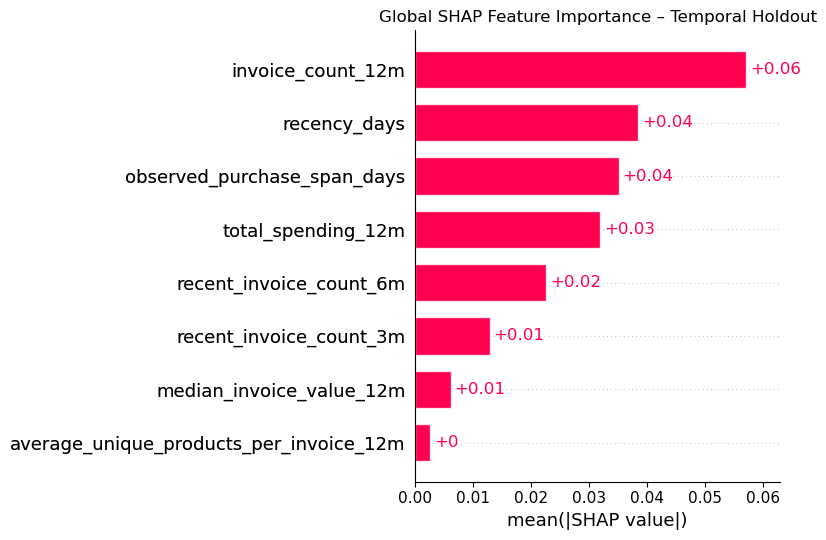

In [547]:
shap.plots.bar(
    holdout_shap_values,
    max_display=8,
    show=False
)

plt.title(
    "Global SHAP Feature Importance – Temporal Holdout"
)

plt.tight_layout()
plt.show()

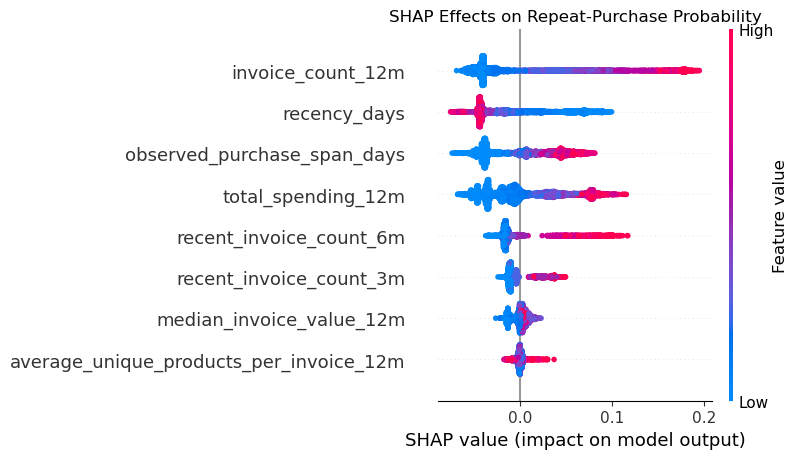

In [548]:
shap.plots.beeswarm(
    holdout_shap_values,
    max_display=8,
    show=False
)

plt.title(
    "SHAP Effects on Repeat-Purchase Probability"
)

plt.tight_layout()
plt.show()

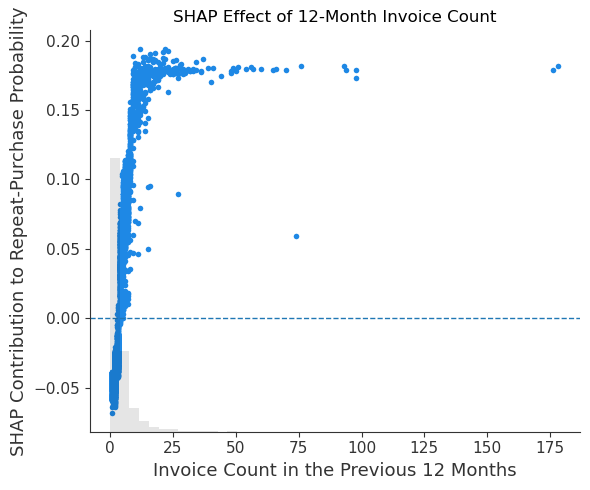

In [549]:
shap.plots.scatter(
    holdout_shap_values[
        :,
        "invoice_count_12m"
    ],
    show=False
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "SHAP Effect of 12-Month Invoice Count"
)

plt.xlabel(
    "Invoice Count in the Previous 12 Months"
)

plt.ylabel(
    "SHAP Contribution to Repeat-Purchase Probability"
)

plt.tight_layout()
plt.show()

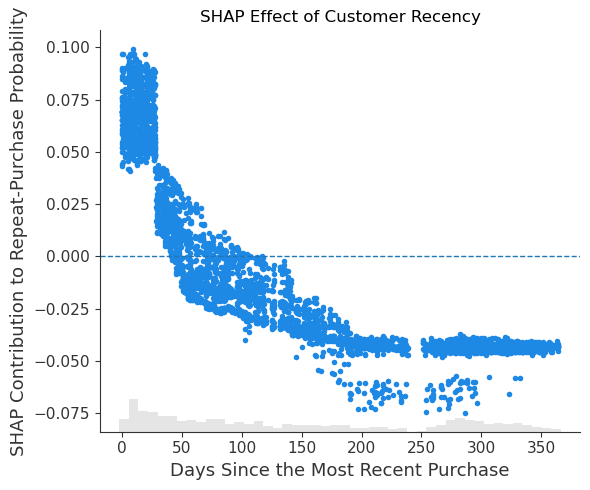

In [550]:
shap.plots.scatter(
    holdout_shap_values[
        :,
        "recency_days"
    ],
    show=False
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "SHAP Effect of Customer Recency"
)

plt.xlabel(
    "Days Since the Most Recent Purchase"
)

plt.ylabel(
    "SHAP Contribution to Repeat-Purchase Probability"
)

plt.tight_layout()
plt.show()

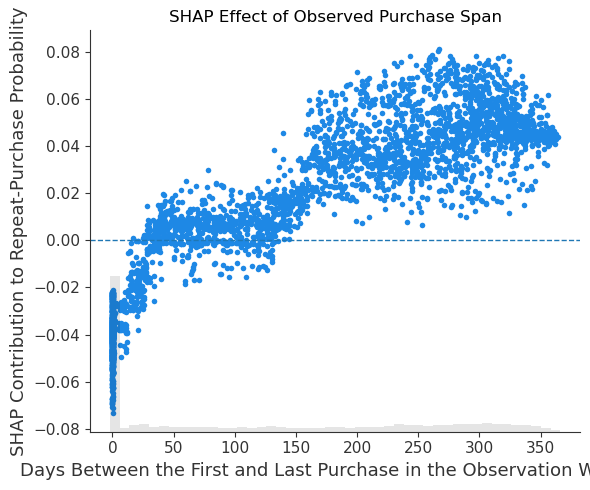

In [551]:
shap.plots.scatter(
    holdout_shap_values[
        :,
        "observed_purchase_span_days"
    ],
    show=False
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "SHAP Effect of Observed Purchase Span"
)

plt.xlabel(
    "Days Between the First and Last Purchase in the Observation Window"
)

plt.ylabel(
    "SHAP Contribution to Repeat-Purchase Probability"
)

plt.tight_layout()
plt.show()

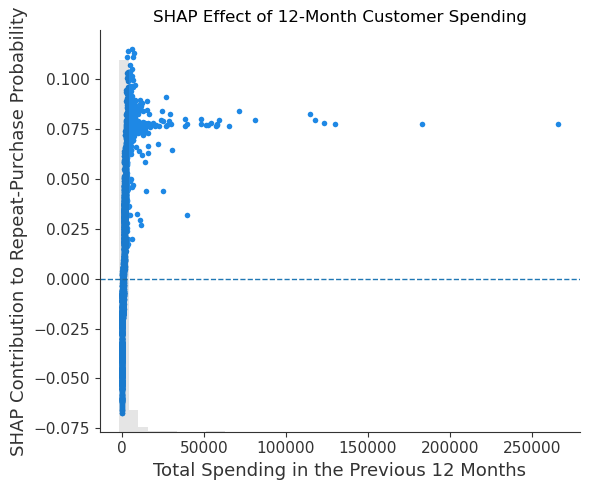

In [552]:
shap.plots.scatter(
    holdout_shap_values[
        :,
        "total_spending_12m"
    ],
    show=False
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "SHAP Effect of 12-Month Customer Spending"
)

plt.xlabel(
    "Total Spending in the Previous 12 Months"
)

plt.ylabel(
    "SHAP Contribution to Repeat-Purchase Probability"
)

plt.tight_layout()
plt.show()

### SHAP Model Interpretation

SHAP was used to explain the probability predictions produced by the final
LightGBM model. A background sample of 100 observations was drawn from the
combined development dataset, while all temporal holdout observations were
used for model interpretation.

The SHAP additivity check confirmed that the baseline probability and the sum
of the individual feature contributions reconstructed the LightGBM prediction
for each customer.

Global SHAP importance showed that the model relied primarily on:

1. Twelve-month invoice count
2. Customer recency
3. Observed purchase span
4. Twelve-month total spending

Together, these four features represented approximately 79% of the total
absolute SHAP contribution across the temporal holdout.

The twelve-month invoice count was the most influential feature. Customers
with more previous orders generally received stronger positive contributions
to their repeat-purchase probability. However, the contribution began to
stabilise at higher invoice counts, indicating a nonlinear saturation effect.

Customer recency showed the opposite relationship. Customers who had purchased
recently generally received positive SHAP contributions, while customers with
long periods of inactivity received negative contributions. The effect became
predominantly negative as the number of days since the most recent purchase
increased.

Longer observed purchase spans and higher total spending generally contributed
positively to repeat-purchase predictions. Recent six-month and three-month
invoice counts also provided positive signals, although some of their
information overlapped with recency and the total twelve-month invoice count.

Median invoice value and average product variety per invoice had relatively
small effects after the stronger behavioural variables had been considered.

Overall, the model learned a commercially plausible customer profile. Repeat
purchase was more likely for customers who purchased frequently, had been
active recently, maintained a longer purchasing relationship and generated
higher cumulative spending.

SHAP values describe how the model uses the available features; they do not
establish causal relationships. Correlated behavioural features may also share
importance between them.

## Business Insights and Recommendations

The customer analyses produced several complementary insights covering customer
value, behavioural segments, retention and future repeat-purchase potential.

### 1. Protect High-Value Active Customers

Champions and Loyal Customers represented approximately 31.7% of the customer
base but generated about 79.2% of total customer revenue.

These customers should therefore be treated as a priority retention group.
Recommended actions include:

- Loyalty rewards and early access to selected products
- Personalised cross-sell and product recommendations
- Recognition-based benefits rather than unnecessary blanket discounts
- Monitoring for sudden increases in recency or decreases in purchase frequency

Because these customers already demonstrate strong purchasing behaviour,
excessive discounting may reduce margin without creating meaningful incremental
sales.

### 2. Reactivate Lapsing Customers Before Complete Inactivity

The clustering analysis identified a group of Lapsing Occasional Customers.
These customers have previously purchased but show weaker or less recent
activity than the active high-value group.

The classification and SHAP results showed that customer recency, invoice
frequency and recent six-month activity were among the strongest repeat-purchase
signals.

Recommended actions include:

- Triggered reactivation campaigns after meaningful inactivity periods
- Reminders based on previously purchased products
- Limited-time incentives for customers whose activity is beginning to decline
- Separate treatment of previously valuable customers and low-value occasional
  customers

A customer should ideally be contacted while activity is declining, rather than
only after the customer has become fully inactive.

### 3. Use Low-Cost Onboarding for Inactive One-Time Customers

The Inactive One-Time Customers cluster represents customers with very limited
purchase history and long inactivity.

Since their future value is less certain, expensive retention campaigns may not
be economically justified.

Recommended actions include:

- Low-cost email or digital retargeting campaigns
- Product discovery and second-purchase reminders
- Small controlled incentives rather than large discounts
- Exclusion from expensive high-touch campaigns unless additional value signals
  are available

The objective for this group should be to test whether a second purchase can be
generated efficiently.

### 4. Encourage the Second Purchase Early

The cohort analysis showed that monthly active-customer retention after
acquisition generally remained around 18%–21% at the measured horizons.

This indicates that a large share of acquired customers did not continue to
purchase regularly in later months.

Recommended actions include:

- Post-purchase communication shortly after the first transaction
- Personalised recommendations based on the first basket
- Second-purchase incentives with controlled expiration periods
- Measurement of time from first to second order as an additional lifecycle KPI
- Separate onboarding strategies for retail and potentially wholesale-like
  customers

The second purchase is an important behavioural milestone because repeated
ordering was the strongest feature in the final prediction model.

### 5. Prioritise Customers Using Repeat-Purchase Probabilities

The final LightGBM model can be used to rank existing customers by their
estimated probability of purchasing within the following three months.

The selected threshold of 0.32 provides one possible operating point, but the
probability ranking may be more useful than treating the output only as a fixed
binary decision.

For example, customers may be divided into priority groups:

- High probability: loyalty, cross-sell and availability-focused actions
- Medium probability: targeted reminders or selective incentives
- Low probability: low-cost reactivation or reduced campaign spending

Campaign capacity, expected profit and contact costs should determine how many
customers are selected. The model score should support campaign prioritisation,
not automatically determine the same action for every customer.

### 6. Monitor Temporal and Seasonal Changes

The positive repeat-purchase rate increased from 36.85% in validation to 49.73%
in the temporal holdout. The final model predicted 39.19% of holdout customers
as positive, indicating that the fixed threshold did not fully reflect the
increased activity in the later period.

Recommended monitoring includes:

- Monthly actual and predicted positive rates
- Precision and recall over time
- Customer-feature distribution changes
- Seasonal changes in order volume and repeat-purchase behaviour
- Probability calibration and threshold performance

Future model versions could incorporate additional temporal features and
rolling-origin validation. However, such changes should be evaluated using a
new, previously unseen time period.

### 7. Validate Campaign Impact Experimentally

The analyses identify predictive relationships but do not establish causality.

For example, high purchase frequency is associated with a higher predicted
repeat-purchase probability, but this does not prove that sending a discount
will cause the customer to purchase again.

Recommended actions should therefore be evaluated with controlled experiments,
such as A/B tests, using outcomes including:

- Incremental conversion
- Incremental revenue
- Campaign cost
- Discount cost
- Profit contribution
- Unsubscribe or contact-fatigue rates

The final business objective should be profitable incremental behaviour rather
than simply maximising the number of customers predicted as positive.

## Project Limitations and Conclusion

### Project Limitations

Although the project provides a comprehensive customer-intelligence workflow,
several limitations should be considered when interpreting the results.

#### 1. Limited Historical Coverage

The dataset covers approximately two years of transactions. December 2011 is
incomplete and was excluded from analyses that required complete monthly or
future target windows.

This limited history restricts the ability to estimate reliable annual
seasonality patterns. Multiple complete years would be required to determine
whether changes observed during particular months are stable seasonal effects
or temporary business conditions.

#### 2. Missing Customer Identifiers

Approximately 22.7% of positive merchandise transaction rows did not contain a
Customer ID.

These transactions were retained for aggregate sales analyses where
appropriate, but they could not be included in customer-level RFM, clustering,
cohort or classification analyses.

As a result, the customer-intelligence results describe only transactions that
could be linked to identified customers.

#### 3. Exact Cancellation Matching

Known-customer cancellations were matched to previous positive transactions
using an exact combination of customer, product, price and absolute quantity.

Only exact, unused prior matches were removed from the customer modelling
dataset. This approach provides a conservative and auditable adjustment, but it
does not identify partial cancellations, modified quantities, price changes or
other non-exact return patterns.

Therefore, some unmatched return-related behaviour may remain imperfectly
represented.

#### 4. Transaction-Scope Assumptions

The project separates positive merchandise sales from cancellations, inventory
adjustments, manual transactions and non-merchandise charges.

Large transactions were not removed solely because of their size, since some
may represent legitimate wholesale-like purchases. Consequently, extreme
customer values remain part of the analysis and may influence spending and
quantity distributions.

The reported results therefore depend on the selected business definition of a
valid merchandise transaction.

#### 5. Cohort Retention Definition

Cohort retention was measured as the percentage of acquisition-cohort customers
who were active in a given calendar-relative month.

This is a monthly active-customer measure rather than a survival measure.
Customers may become inactive and later return, so retention values should not
be interpreted as continuously retained customers.

#### 6. Descriptive Customer Segments

RFM segments and K-Means clusters describe behavioural patterns in the observed
data.

The selected three-cluster solution was supported by silhouette analysis,
stability checks, business profiles and comparison with hierarchical
clustering. However, cluster selection and business naming still involve
analytical judgement.

The segments should therefore be treated as decision-support groups rather than
fixed or naturally occurring customer categories.

#### 7. Repeated Customers Across Training Snapshots

The classification training dataset contains multiple customer-snapshot rows
for some customers because the same customer may appear at different historical
prediction dates.

Each row contains information available at its own snapshot date, and the
temporal validation and holdout periods occur after the training target
windows. However, customer-snapshot observations are not fully independent,
which should be considered when interpreting training sample size and model
uncertainty.

#### 8. Threshold and Temporal Target Shift

The classification threshold of 0.32 was selected using the June 2011
validation snapshot.

The positive target rate increased from 36.85% in validation to 49.73% in the
September 2011 temporal holdout. The model predicted 39.19% of holdout
customers as positive, which reduced recall in the later period.

This shows that a fixed threshold may not maintain the same operational
behaviour when repeat-purchase rates change over time.

No threshold, feature or model parameter was changed after examining the
holdout results, preserving the holdout as an unbiased final evaluation period.

#### 9. Predictive, Not Causal, Findings

The analyses identify associations that are useful for prediction and customer
prioritisation.

They do not prove that changing a feature or sending a campaign will cause a
customer to purchase. Business interventions should therefore be evaluated
through controlled experiments such as A/B tests.

#### 10. SHAP Interpretation Limitations

SHAP explains how the final LightGBM model used the available features.

It does not prove that the model is correct, establish causal relationships or
fully resolve the allocation of importance among correlated features. Features
such as recency and recent invoice counts may share overlapping behavioural
information.

### Conclusion

This project developed an end-to-end customer-intelligence workflow using the
Online Retail II transaction dataset.

The workflow included:

- Transaction cleaning and business-rule-based sales definitions
- Monthly, country and product performance analysis
- Exact cancellation adjustment for customer modelling
- Customer-level behavioural feature engineering
- RFM segmentation
- K-Means customer clustering
- Cohort retention analysis
- Temporal repeat-purchase classification
- LightGBM model interpretation with SHAP
- Business recommendations based on customer behaviour

The customer analyses showed that Champions and Loyal Customers represented
approximately 31.7% of identified customers while generating about 79.2% of
customer revenue.

The clustering analysis identified three broad behavioural profiles:

- Active High-Value Customers
- Lapsing Occasional Customers
- Inactive One-Time Customers

The cohort analysis indicated that monthly active-customer retention generally
remained around 18%–21% at the selected post-acquisition horizons, highlighting
the importance of encouraging an early second purchase.

For repeat-purchase prediction, an enhanced Logistic Regression model provided
a strong interpretable baseline. A controlled LightGBM model achieved similar
validation performance with a small improvement in PR-AUC and was selected as
the final nonlinear model.

The final LightGBM configuration used 15 leaves, a minimum of 50 observations
per leaf, 64 boosting iterations and a classification threshold of 0.32.

On the untouched temporal holdout, the model achieved:

- ROC-AUC: 0.77
- PR-AUC: 0.79
- Accuracy: 0.71
- Balanced accuracy: 0.70
- Precision: 0.76
- Recall: 0.60
- F1-score: 0.67

SHAP analysis showed that the most influential predictive signals were
twelve-month invoice frequency, customer recency, purchase-history span and
total spending. Together, these four features represented approximately 79% of
the total absolute SHAP contribution.

Overall, the project demonstrates how transaction data can be transformed into
customer segments, retention insights, repeat-purchase predictions and
actionable business recommendations. It also highlights the importance of
temporal validation, transparent modelling assumptions and continuous
monitoring when predictive models are used in changing retail environments.